In [1]:
import subprocess
import json
import os
import math
import shutil
import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as ctx
import numbers
import pickle
import tempfile
import matplotlib.gridspec as gridspec
from pyproj import Transformer
from shapely.geometry import LineString, Point
from shapely.ops import nearest_points
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches
from scipy.spatial.distance import directed_hausdorff
from shapely.validation import make_valid

In [2]:
source_and_destination = "NHD"

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
java_jar = os.path.join(repo_root, "demo", "target", "quickstart-0.0.1-SNAPSHOT.jar")
input_geojson = os.path.join(repo_root, "data", source_and_destination, "NHDFlowline.geojson")
output_dir = os.path.join(repo_root, "output", "dataset_test_results", source_and_destination)
java_dir = os.path.join(repo_root, "demo")

In [3]:
def get_top_n_longest(input_geojson, output_geojson=None, crs_utm=None):
    gdf = gpd.read_file(input_geojson)
    gdf = gdf[gdf.geometry.notna() & gdf.geometry.is_valid]
    
    gdf['vertex_count'] = gdf.geometry.apply(lambda g: len(g.coords))
    top_n = gdf.nlargest(700, 'vertex_count').drop(columns=['vertex_count']).reset_index(drop=True)

    if output_geojson:
        os.makedirs(os.path.dirname(output_geojson), exist_ok=True)
        top_n.to_file(output_geojson, driver='GeoJSON')
        print("saved!")

    return top_n

sampled_geojson = os.path.join(output_dir, "sampled_1000_longest.geojson")
sampled_gdf = get_top_n_longest(input_geojson, sampled_geojson, crs_utm="EPSG:32648")

saved!


In [74]:
def build_simplification_code():
    mvn_path = shutil.which("mvn.cmd") or shutil.which("mvn")

    cmd = f'"{mvn_path}" clean package -q'
    
    result = subprocess.run(
        cmd,
        cwd=java_dir,
        shell=True,
        capture_output=True,
        text=True,
        env=os.environ.copy()
    )

    if result.returncode == 0:
        print("success!")
        return True
    else:
        print("Build failed!")
        print(result.stdout)
        print(result.stderr)
        return False

def run_simplification(epsilon, use_sample=False):
    if not build_simplification_code():
        return False
    
    os.makedirs(output_dir, exist_ok=True)

    current_input = sampled_geojson if use_sample else input_geojson

    cmd = [
        "java", "-jar", java_jar,
        current_input, output_dir, str(epsilon)
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, cwd=repo_root)

    if result.returncode != 0:
        print("Error at simplification!", result.stderr)
    else:
        print("Output:", output_dir)

run_simplification(150, use_sample=True)

success!
Output: C:\Users\MyLaptop\Documents\Tugas Akhir\kode\Tugas_Akhir\output\dataset_test_results\NHD


Original UTM CRS: EPSG:4326


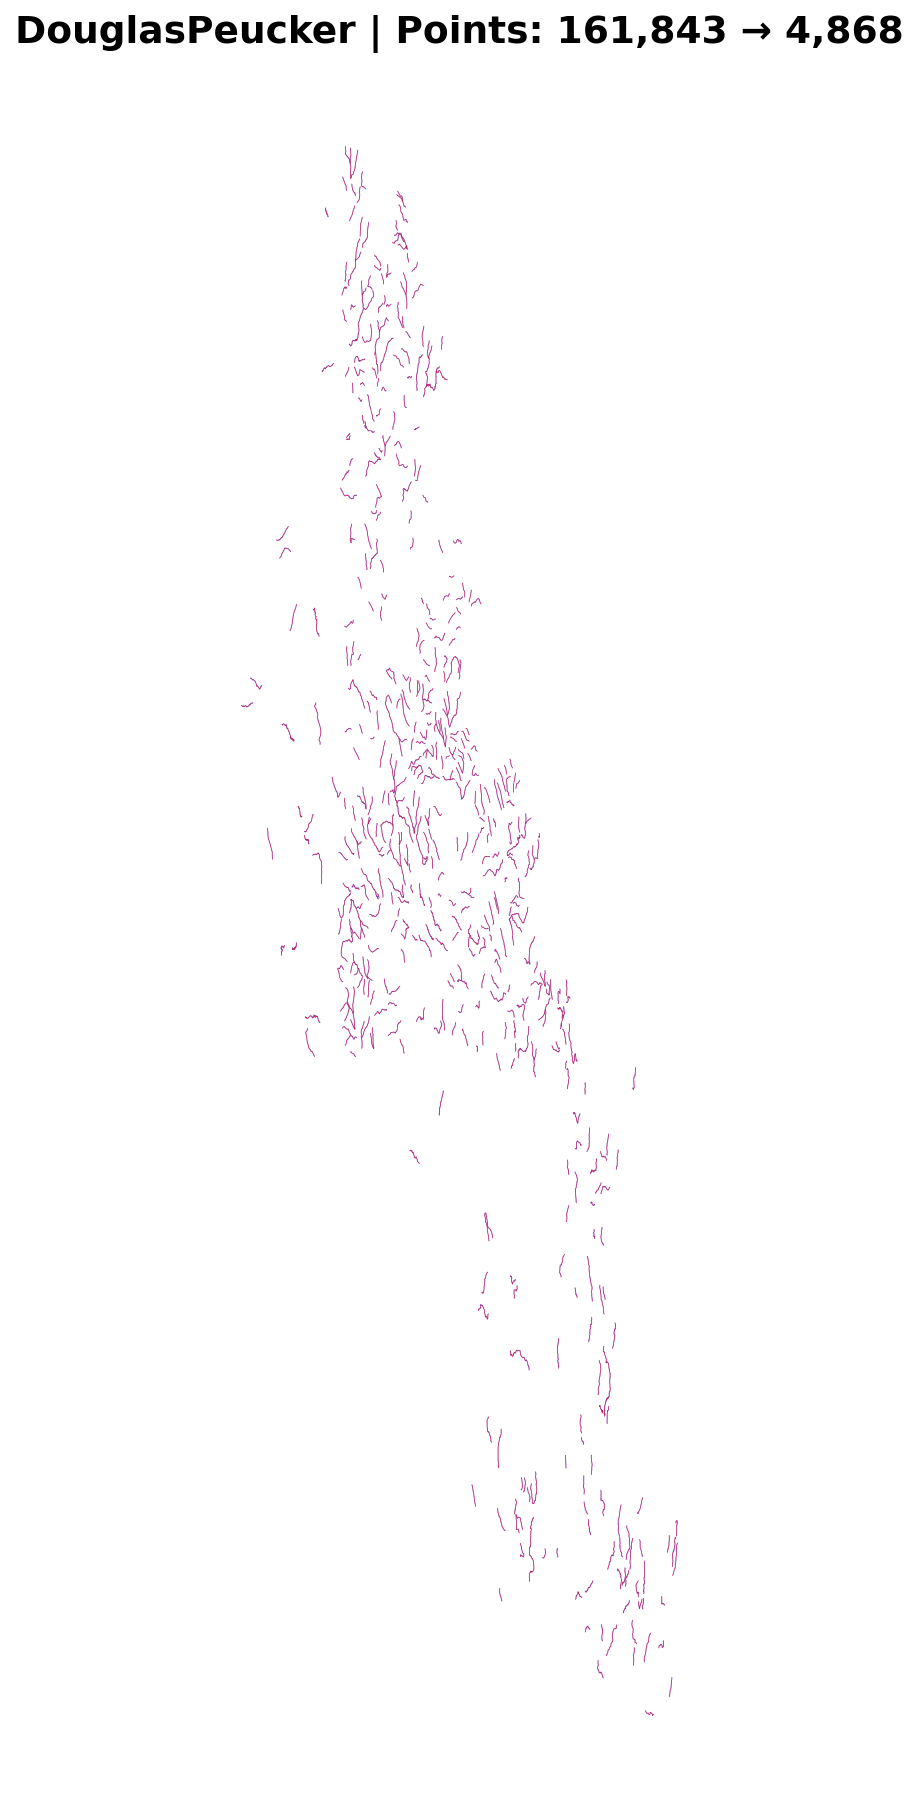

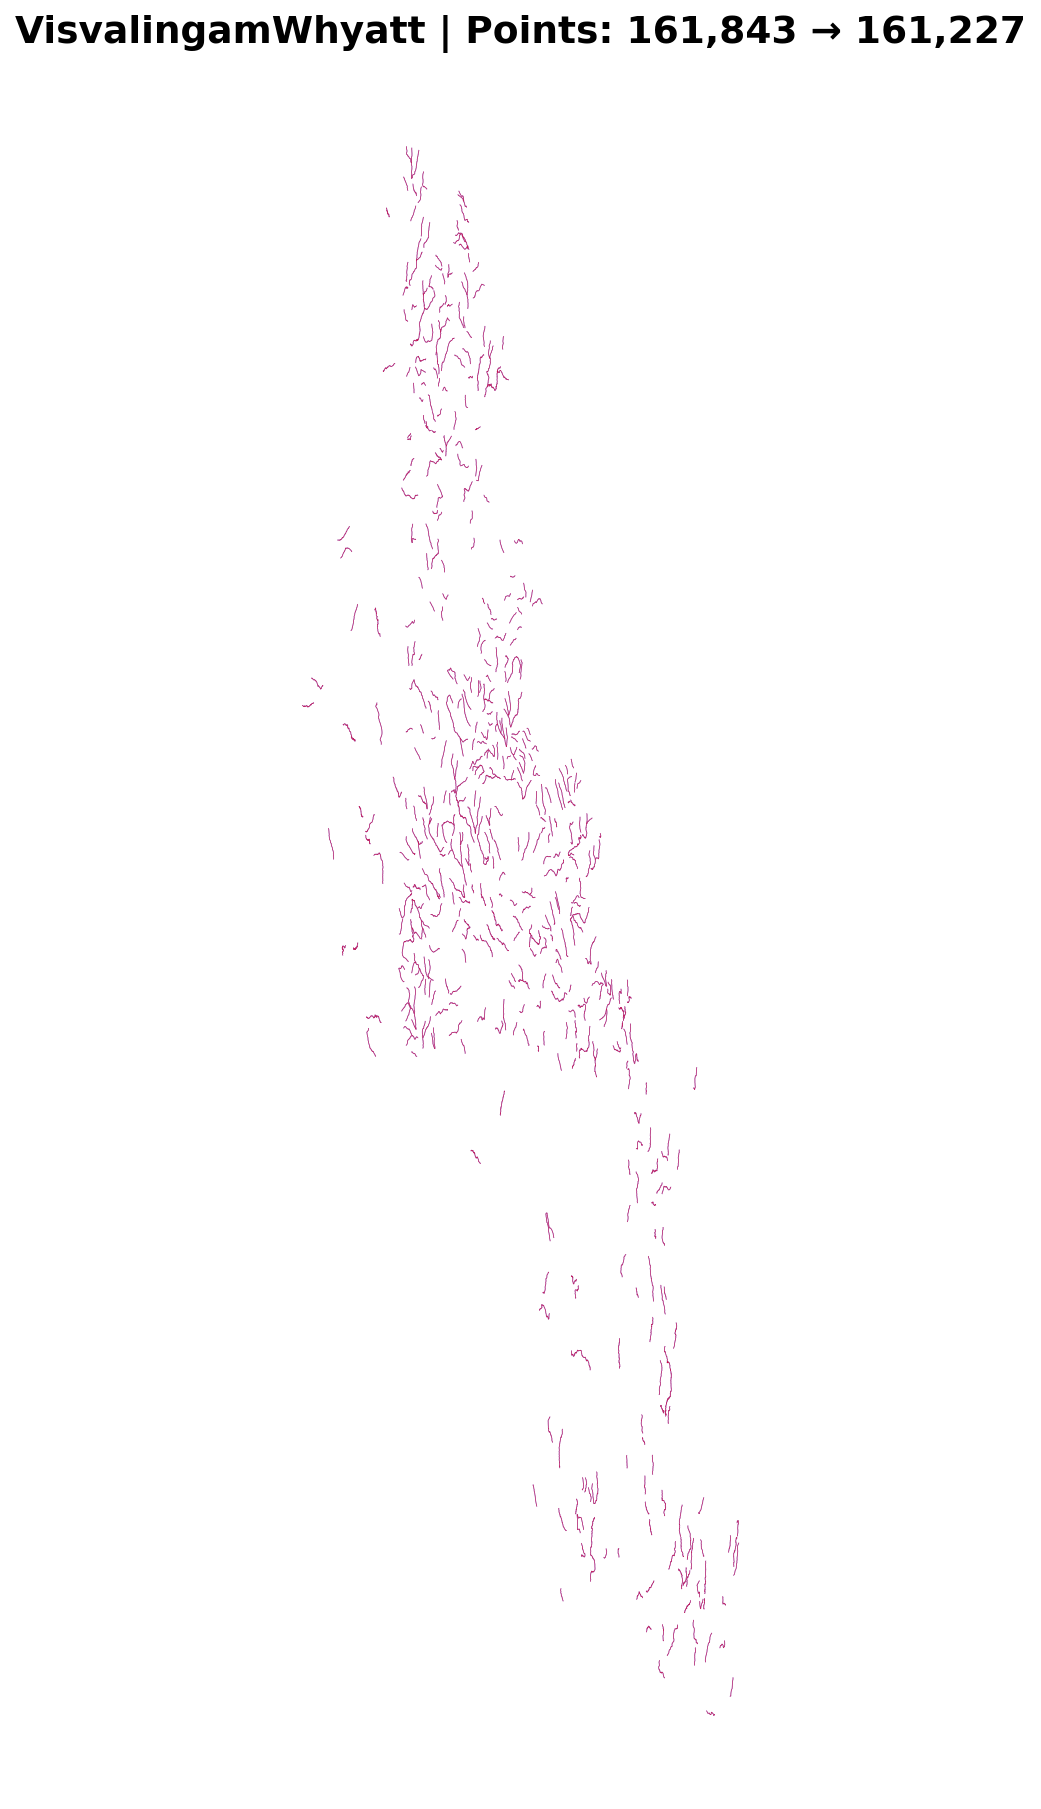

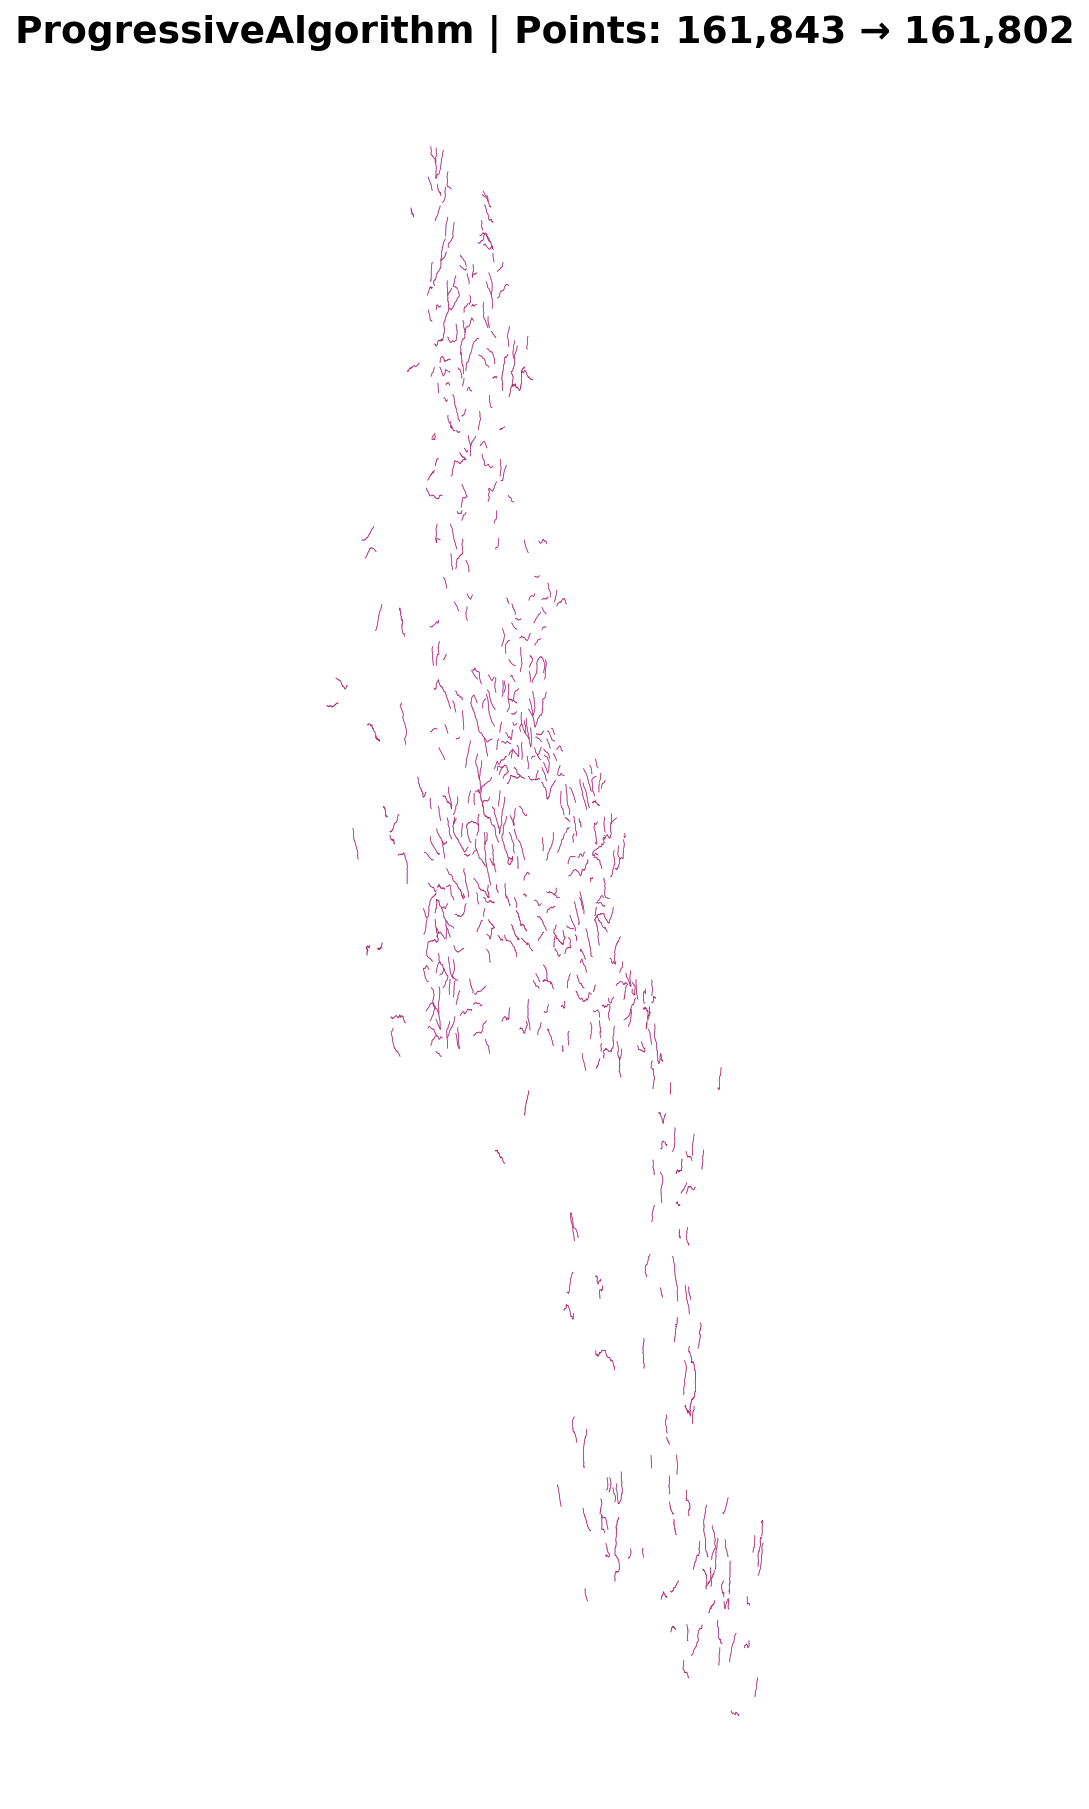

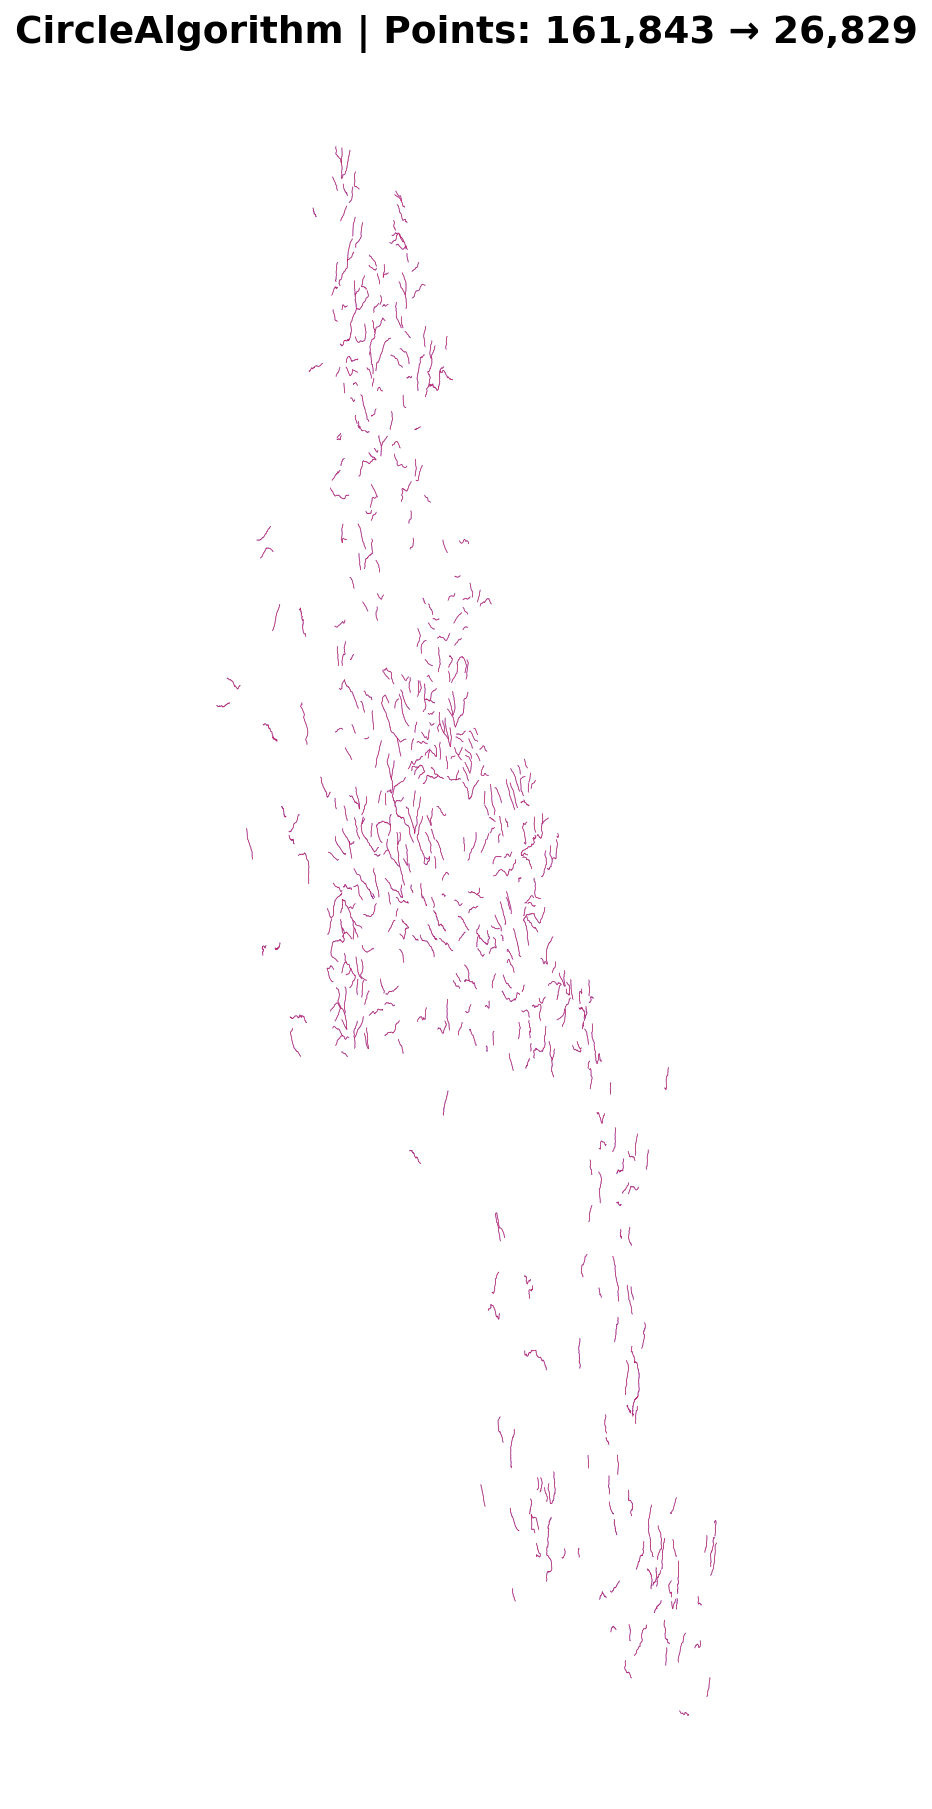

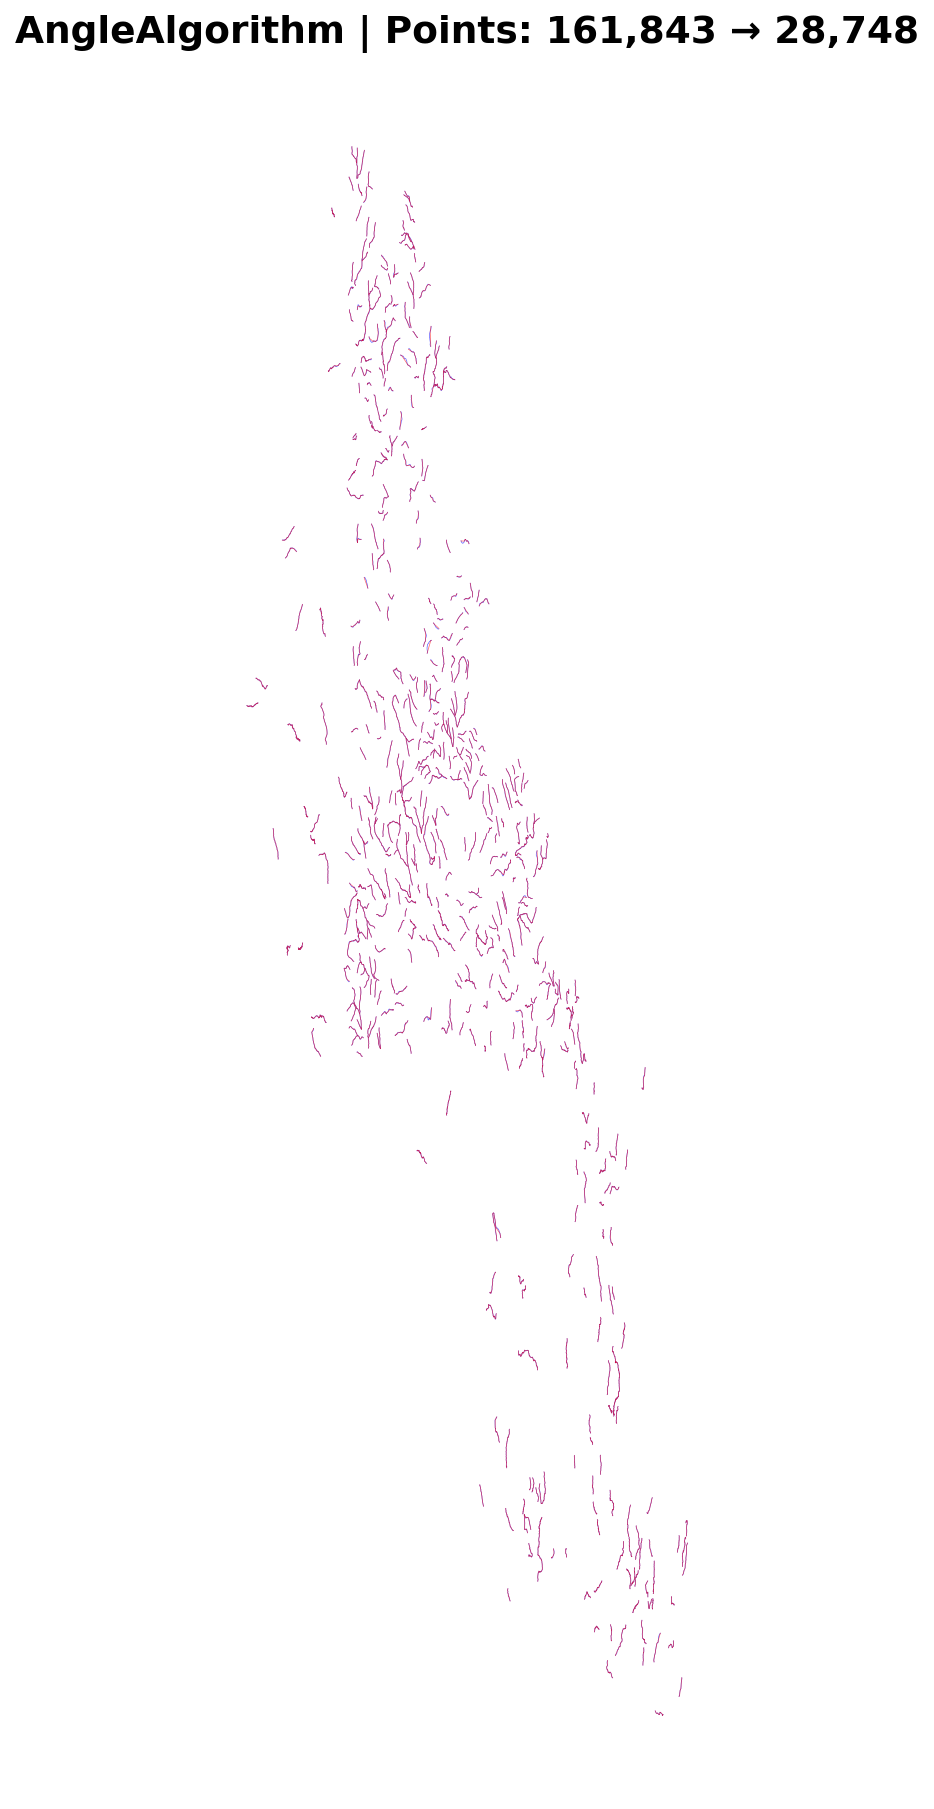

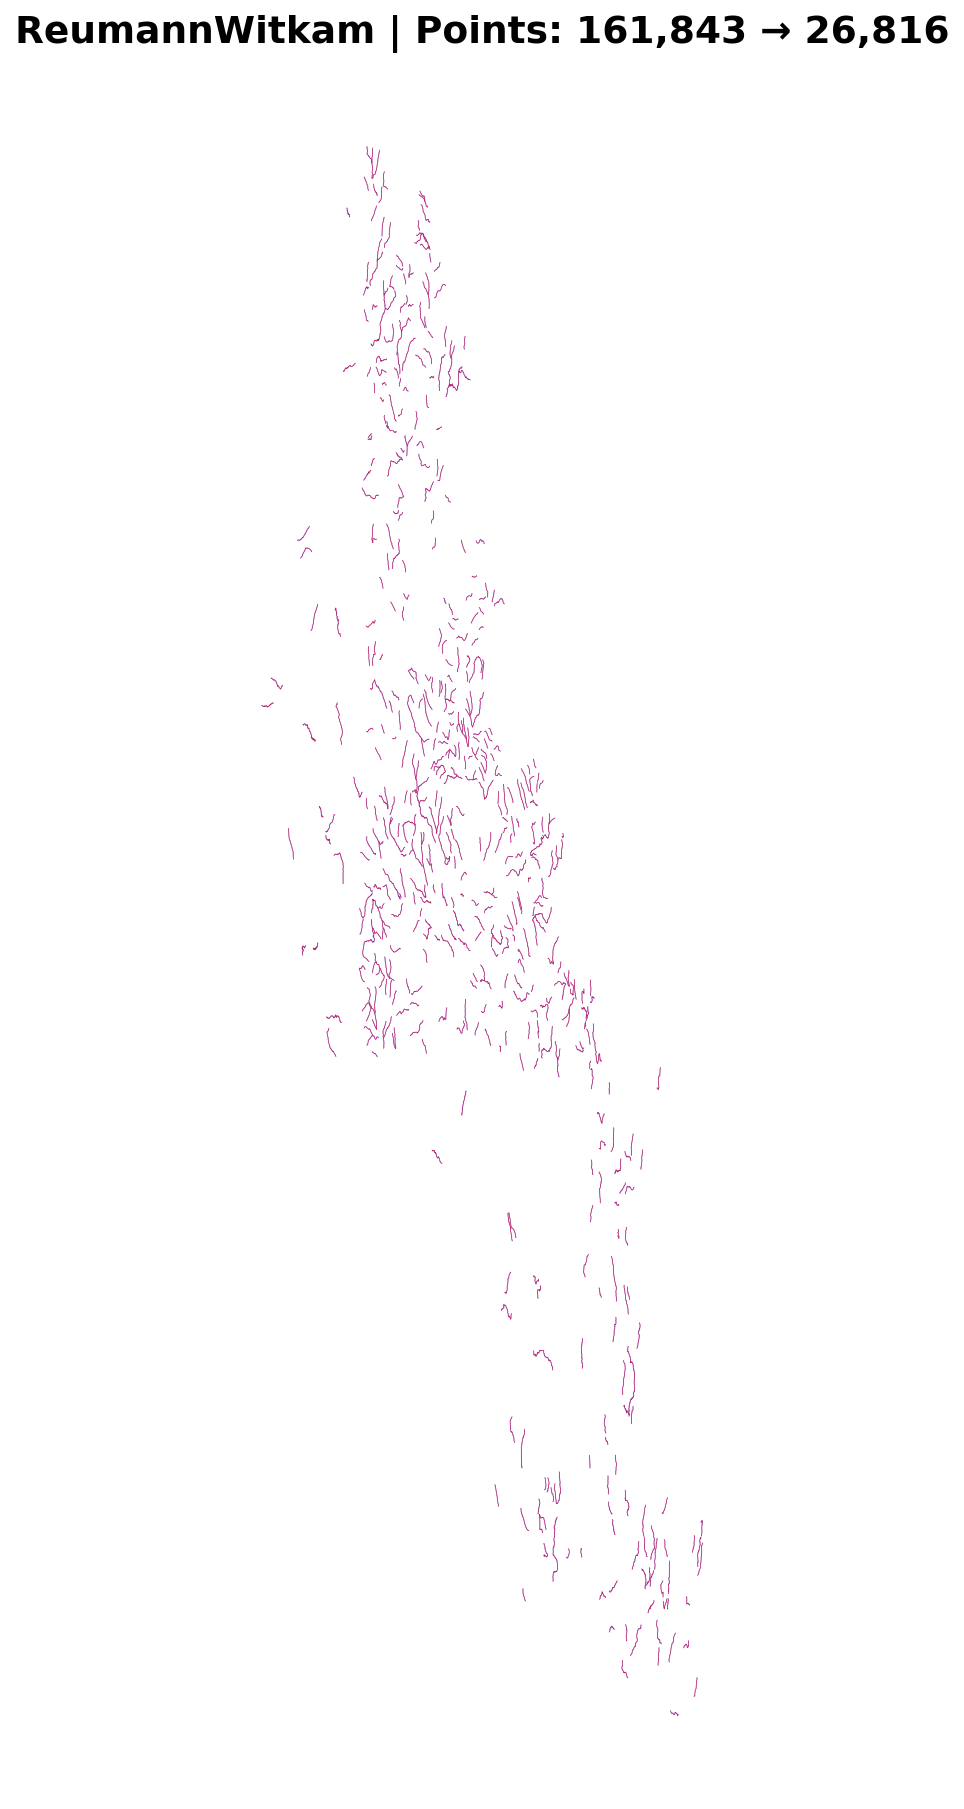

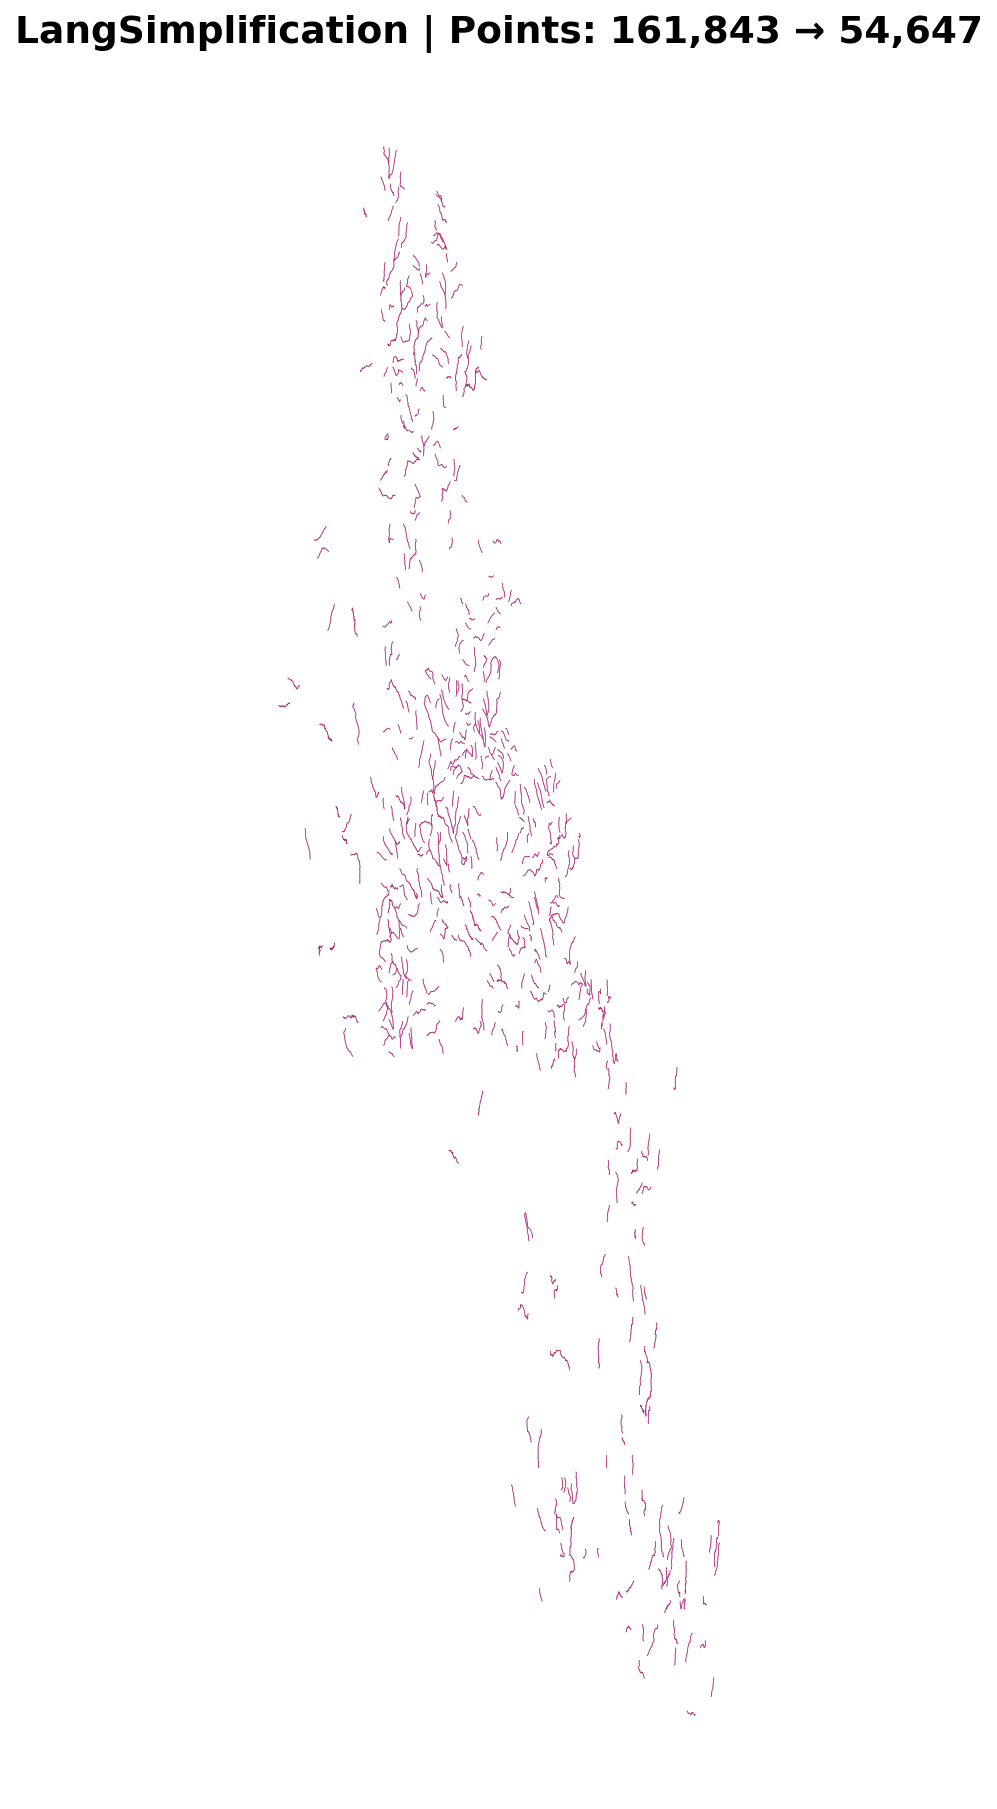

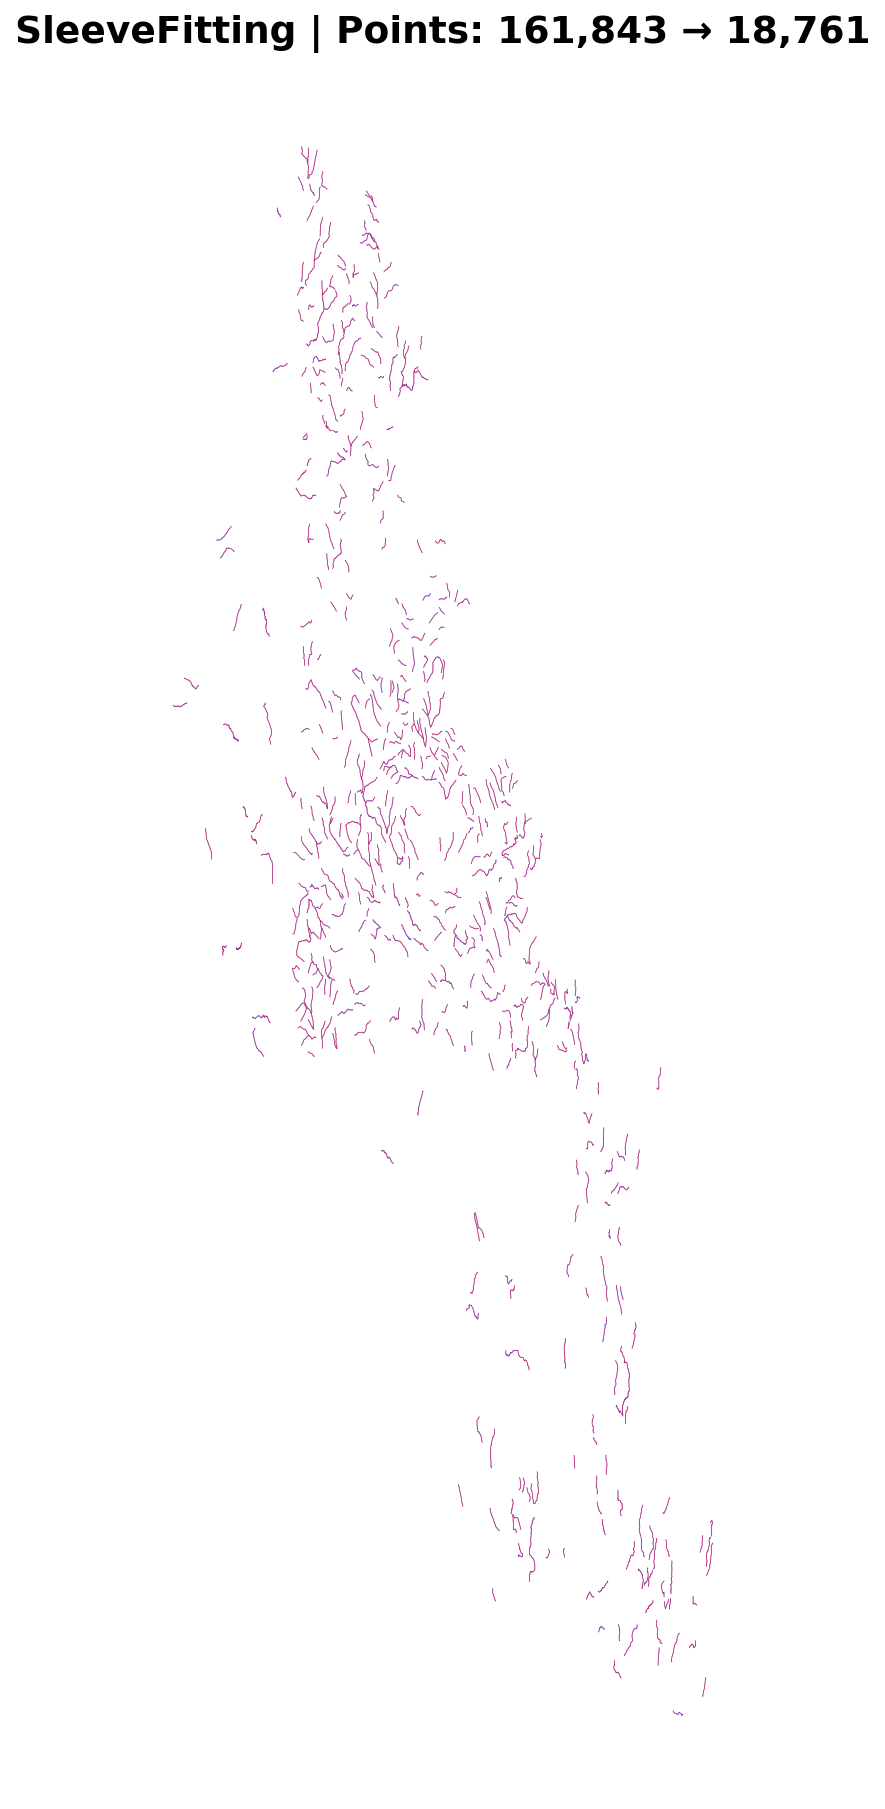

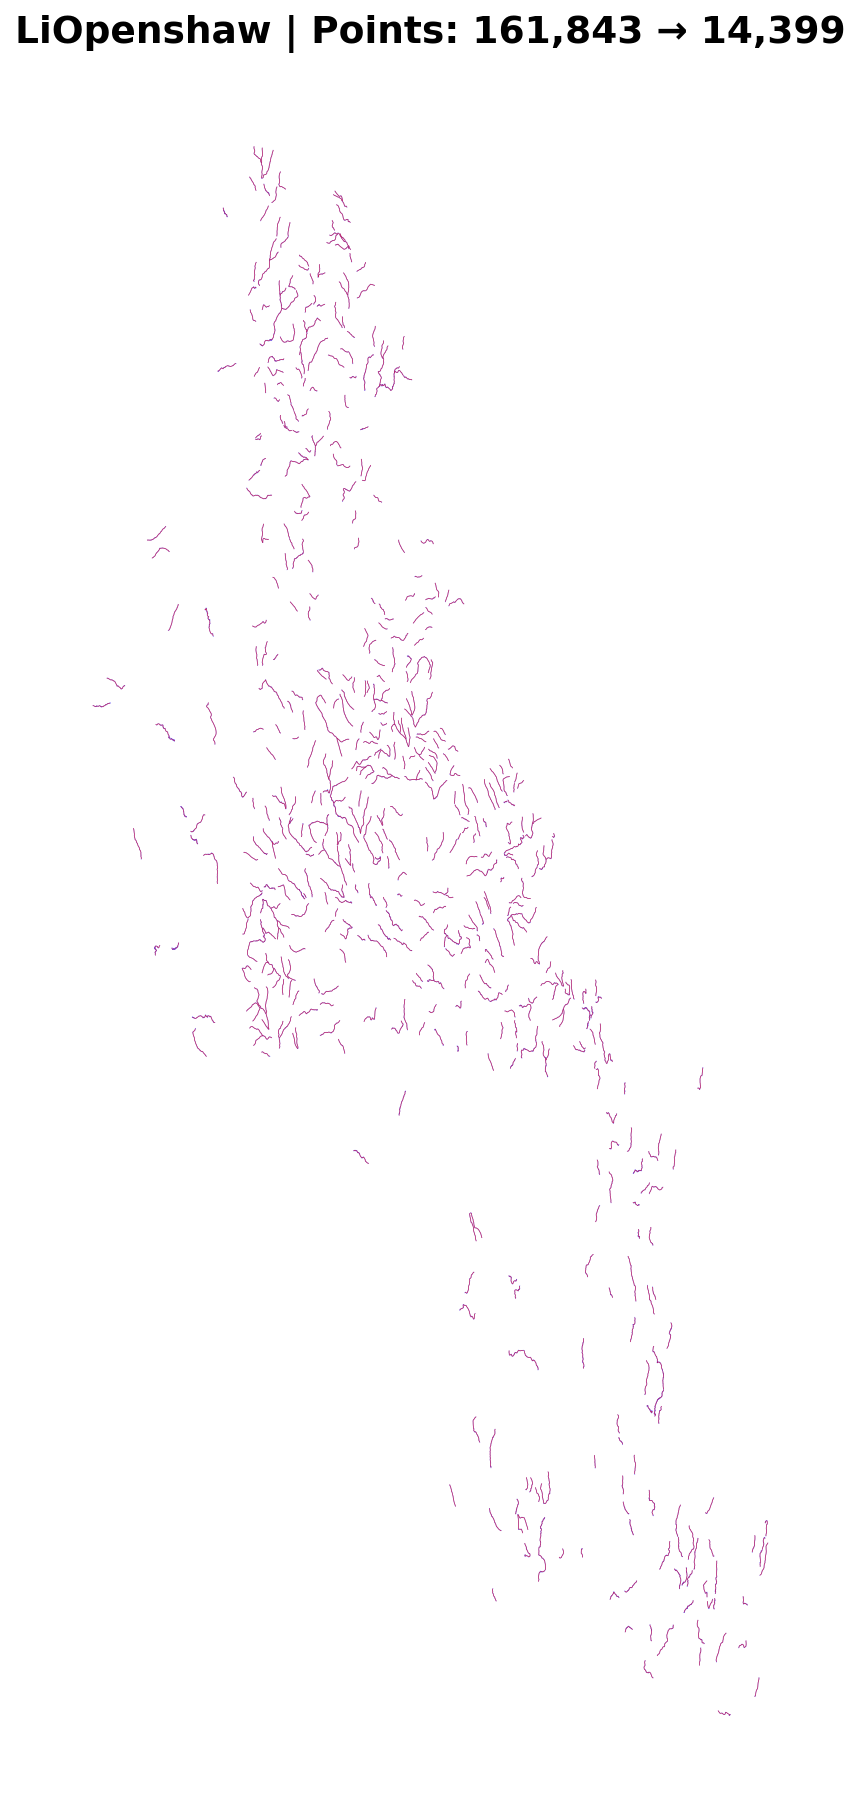

In [75]:
algorithms = [
    "DouglasPeucker",
    "VisvalingamWhyatt",
    "ProgressiveAlgorithm",
    "CircleAlgorithm",
    "AngleAlgorithm",
    "ReumannWitkam",
    "LangSimplification",
    "SleeveFitting",
    "LiOpenshaw"
]

original_gdf = gpd.read_file(os.path.join(output_dir, "reprojected_dataset.geojson"))
print(f"Original UTM CRS: {original_gdf.crs}")

simplified_gdfs = {}
for algo in algorithms:
    path = os.path.join(output_dir, f"{algo}.geojson")
    if os.path.exists(path):
        gdf = gpd.read_file(path)

        if gdf.crs != original_gdf.crs:
            print("CRS doesn't match!")
            gdf = gdf.to_crs(original_gdf.crs)
        simplified_gdfs[algo] = gdf
    else:
        print("geojson not found.")

plt.rcParams['figure.dpi'] = 150 

for idx, algo in enumerate(algorithms):
    if algo not in simplified_gdfs:
        print(f"Skipping {algo} — no data")
        continue

    gdf_simplified = simplified_gdfs[algo]
    
    fig, ax = plt.subplots(figsize=(18, 12))  

    original_gdf.plot(ax=ax, color='blue', linewidth=0.35, alpha=0.6, zorder=1, label="Original")
    gdf_simplified.plot(ax=ax, color='red', linewidth=0.35, alpha=0.6, zorder=2, label="Simplified")

    ax.autoscale()
    
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    orig_points = sum(len(geom.coords) for geom, geom, in zip(original_gdf.geometry, original_gdf.geometry) if geom.geom_type == 'LineString')
    simp_points = sum(len(geom.coords) for geom, geom in zip(gdf_simplified.geometry, gdf_simplified.geometry) if geom.geom_type == 'LineString')

    ax.set_title(
        f"{algo} | Points: {orig_points:,} → {simp_points:,}",
        fontsize=18, weight='bold', pad=12
    )
    
    plt.tight_layout(pad=0.5)
    plt.show()

In [70]:
def ccw_orientation(a, b, c):
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])

def segments_intersect(p1, p2, p3, p4):
    if p1 == p2 or p3 == p4:
        return false

    d1 = ccw_orientation(p3, p4, p1)
    d2 = ccw_orientation(p3, p4, p2)
    d3 = ccw_orientation(p1, p2, p3)
    d4 = ccw_orientation(p1, p2, p4)

    if ((d1 > 0 and d2 < 0) or (d1 < 0 and d2 > 0)) and ((d3 > 0 and d4 < 0) or (d3 < 0 and d4 > 0)):
        return True

    if d1 == 0 and min(p3[0], p4[0]) <= p1[0] <= max(p3[0], p4[0]) and min(p3[1], p4[1]) <= p1[1] <= max(p3[1], p4[1]):
        return True
    if d2 == 0 and min(p3[0], p4[0]) <= p2[0] <= max(p3[0], p4[0]) and min(p3[1], p4[1]) <= p2[1] <= max(p3[1], p4[1]):
        return True
    if d3 == 0 and min(p1[0], p2[0]) <= p3[0] <= max(p1[0], p2[0]) and min(p1[1], p2[1]) <= p3[1] <= max(p1[1], p2[1]):
        return True
    if d4 == 0 and min(p1[0], p2[0]) <= p4[0] <= max(p1[0], p2[0]) and min(p1[1], p2[1]) <= p4[1] <= max(p1[1], p2[1]):
        return True
        
    return False

def point_to_segment_dist(point, start, end):
    p = np.array(point, dtype=float)
    a = np.array(start, dtype=float)
    b = np.array(end, dtype=float)

    ab = b - a
    ap = p - a

    ab_len_sq = np.dot(ab, ab)
    if ab_len_sq == 0.0:
        return np.lialg.norm(ap)

    t = np.dot(ap, ab) / ab_len_sq

    if t < 0.0:
        return np.linalg.norm(p - a)
    elif t > 1.0:
        return np.linalg.norm(p - b)
    else:
        cross_product = np.abs(ab[0] * ap[1] - ab[1] * ap[0])
        return cross_product / np.sqrt(ab_len_sq)

def calc_angle(v_prev, v_curr, v_next):
    v_prev = np.array(v_prev)
    v_curr = np.array(v_curr)
    v_next = np.array(v_next)

    v_in = v_prev - v_curr
    v_out = v_next - v_curr

    norm_in = np.linalg.norm(v_in)
    norm_out = np.linalg.norm(v_out)

    if norm_in == 0 or norm_out == 0:
        return 180.0

    v_in_norm = v_in / norm_in
    v_out_norm = v_out / norm_out

    cos_angle = np.clip(np.dot(v_in_norm, v_out_norm), -1.0, 1.0)
    angle_rad = math.acos(cos_angle)
    angle_deg = math.degrees(angle_rad)

    return angle_deg

def calc_angular_feature_retention(original_gdf, simplified_gdf, percentile_threshold=75):
    important_vertices = []

    min_len = min(len(original_gdf), len(simplified_gdf))
    if min_len == 0:
        return 1.0

    all_angles = []
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        if orig_line is None or len(orig_line.coords) < 3:
            continue

        coords = list(orig_line.coords)
        for i in range(1, len(coords) - 1):
            angle = calc_angle(coords[i-1], coords[i], coords[i+1])
            all_angles.append(angle)

    if not all_angles:
        return 1.0

    threshold = np.percentile(all_angles, percentile_threshold)

    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        if orig_line is None or len(orig_line.coords) < 3:
            continue

        coords = list(orig_line.coords)
        for i in range(1, len(coords) - 1):
            angle = calc_angle(coords[i-1], coords[i], coords[i+1])

            if angle < threshold:
                important_vertices.append((round(float(coords[i][0]), 6), round(float(coords[i][1]), 6)))

    if not important_vertices:
        return 1.0

    simplified_vertices = set()
    for idx in range(len(simplified_gdf)):
        simp_line = simplified_gdf.iloc[idx].geometry
        
        if simp_line is None:
            continue

        for coord in simp_line.coords:
            simplified_vertices.add((round(float(coord[0]), 6), round(float(coord[1]), 6)))

    retained_count = 0
    for vertex in important_vertices:
        if vertex in simplified_vertices:
            retained_count += 1

    return retained_count / len(important_vertices)

def segment_hausdorff_dist(line_a, line_b):
    coords_a = list(line_a.coords)
    coords_b = list(line_b.coords)

    if len(coords_a) < 2 or len(coords_b) < 2:
        return float('inf')

    segments_b = [(coords_b[i], coords_b[i+1]) for i in range(len(coords_b) - 1)]
    segments_a = [(coords_a[i], coords_a[i+1]) for i in range(len(coords_a) - 1)]

    max_dist_a_to_b = 0.0
    for pt in coords_a:
        min_dist = min(point_to_segment_dist(pt, seg[0], seg[1]) for seg in segments_b)
        max_dist_a_to_b = max(max_dist_a_to_b, min_dist)

    max_dist_b_to_a = 0.0
    for pt in coords_b:
        min_dist = min(point_to_segment_dist(pt, seg[0], seg[1]) for seg in segments_a)
        max_dist_b_to_a = max(max_dist_b_to_a, min_dist)

    return max(max_dist_a_to_b, max_dist_b_to_a)

def calc_segment_hausdorff(original_gdf, simplified_gdf):
    distances = []

    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry

        if orig_line is None or simp_line is None:
            continue

        try:
            dist = segment_hausdorff_dist(orig_line, simp_line)
            if np.isfinite(dist):
                distances.append(dist)
        except:
            continue

    return np.mean(distances) if distances else 0.0
        
def hausdorff_dist(original_gdf, simplified_gdf):
    distances = []

    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry

        coords1 = np.array(orig_line.coords)
        coords2 = np.array(simp_line.coords)

        if len(coords1) < 2 or len(coords2) < 2:
            continue

        try:
            h1 = directed_hausdorff(coords1, coords2)[0]
            h2 = directed_hausdorff(coords2, coords1)[0]
            hausdorff_distance = max(h1, h2)

            distances.append(hausdorff_distance)
        except:
            continue

    return np.mean(distances) if distances else 0.0

def triangle_area(v_prev, v_curr, v_next):
    prev = np.array(v_prev)
    curr = np.array(v_curr)
    next_pt = np.array(v_next)

    vec1 = curr - prev
    vec2 = next_pt - prev

    cross_product = vec1[0] * vec2[1] - vec1[1] * vec2[0]

    area = 0.5 * abs(cross_product)
    return area

def calc_semantic_retention(original_gdf, simplified_gdf, percentile_threshold=75, tolerance=10.0):
    min_len = min(len(original_gdf), len(simplified_gdf))
    
    all_areas = []
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        if orig_line is None or len(orig_line.coords) < 3:
            continue
        coords = list(orig_line.coords)
        for i in range(1, len(coords) - 1):
            area = triangle_area(coords[i-1], coords[i], coords[i+1])
            all_areas.append(area)
    
    threshold = np.percentile(all_areas, percentile_threshold)
    
    important_vertices_orig = []
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        
        if len(orig_line.coords) < 3:
            continue
            
        coords = list(orig_line.coords)
        for i in range(1, len(coords) - 1):
            area = triangle_area(coords[i-1], coords[i], coords[i+1])
            if area >= threshold:
                important_vertices_orig.append((float(coords[i][0]), float(coords[i][1])))
    
    if not important_vertices_orig:
        return 1.0
    
    simplified_vertices = set()
    for idx in range(len(simplified_gdf)):
        simp_line = simplified_gdf.iloc[idx].geometry
        
        for coord in simp_line.coords:
            simplified_vertices.add((round(float(coord[0]), 6), round(float(coord[1]), 6)))
    
    retained_count = 0
    for vertex in important_vertices_orig:
        rounded_vertex = (round(vertex[0], 6), round(vertex[1], 6))
        
        if rounded_vertex in simplified_vertices:
            retained_count += 1
    
    return retained_count / len(important_vertices_orig)

def frechet_dist(P, Q):
    def c(ca, i, j, P, Q):
        if ca[i, j] > -1:
            return ca[i, j]
        elif i == 0 and j == 0:
            ca[i, j] = np.linalg.norm(P[0] - Q[0])
        elif i > 0 and j == 0:
            ca[i, j] = max(c(ca, i-1, 0, P, Q), np.linalg.norm(P[i] - Q[0]))
        elif i == 0 and j > 0:
            ca[i, j] = max(c(ca, 0, j-1, P, Q), np.linalg.norm(P[0] - Q[j]))
        elif i > 0 and j > 0:
            ca[i, j] = max(
                min(c(ca, i-1, j, P, Q), c(ca, i-1, j-1, P, Q), c(ca, i, j-1, P, Q)),
                np.linalg.norm(P[i] - Q[j])
            )
        else:
            ca[i, j] = float('inf')
        return ca[i, j]

    P = np.array(P)
    Q = np.array(Q)

    if len(P) == 0 or len(Q) == 0:
        return float('inf')

    ca = np.ones((len(P), len(Q))) * -1
    return c(ca, len(P)-1, len(Q)-1, P, Q)

def calc_shape_preservation(original_gdf, simplified_gdf):
    distances = []

    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry

        if orig_line is None or simp_line is None:
            continue

        orig_coords = list(orig_line.coords)
        simp_coords = list(simp_line.coords)

        if len(orig_coords) < 2 or len(simp_coords) < 2:
            continue

        try:
            f_dist = frechet_dist(orig_coords, simp_coords)
            distances.append(f_dist)
        except:
            continue

    return np.mean(distances) if distances else 0.0

def ddtw_distance(P, Q):
    P = np.array(P)
    Q = np.array(Q)
    n, m = len(P), len(Q)

    dtw = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0.0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = np.linalg.norm(P[i-1] - Q[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])

    return dtw[n, m]

def calc_dtw_metric(original_gdf, simplified_gdf):
    distances = []
    
    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry
        
        if orig_line is None or simp_line is None:
            continue
            
        orig_coords = list(orig_line.coords)
        simp_coords = list(simp_line.coords)
        
        if len(orig_coords) < 2 or len(simp_coords) < 2:
            continue
            
        try:
            d_dist = ddtw_distance(orig_coords, simp_coords)
            distances.append(d_dist)
        except:
            continue
    
    return np.mean(distances) if distances else 0.0

def count_self_intersection(coords):
    if len(coords) < 4:
        return 0

    intersections = 0
    n = len(coords)

    for i in range(n - 1):
        for j in range(i + 2, n - 1):
            if j == i + 1:
                continue

            p1, p2 = coords[i], coords[i + 1]
            p3, p4 = coords[j], coords[j + 1]

            if segments_intersect(p1, p2, p3, p4):
                intersections += 1

    return intersections

def calc_topological_validity(simplified_gdf):
    if len(simplified_gdf) == 0:
        return 1.0

    intersection_counts = []

    for geom in simplified_gdf.geometry:
        if geom is None or not isinstance(geom, LineString):
            intersection_counts.append(0)
            continue

        coords = list(geom.coords)
        if len(coords) < 4:
            intersection_counts.append(0)
            continue

        count = count_self_intersection(coords)
        intersection_counts.append(count)

    if not intersection_counts:
        return 1.0

    mean_intersections = np.mean(intersection_counts)
    score = 1.0 / (1.0 + mean_intersections)
    return score

def calc_circular_coverage(original_gdf, simplified_gdf, buffer_radius):
    coverage_ratios = []

    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry

        if orig_line is None or simp_line is None:
            continue

        try:
            simp_buffer = simp_line.buffer(buffer_radius)
            intersection = orig_line.intersection(simp_buffer)

            if intersection.is_empty:
                convered_length = 0.0
            else:
                if intersection.geom_type == 'LineString':
                    covered_length = intersection.length
                elif intersection.geom_type == 'MultiLineString':
                    covered_length = sum(seg.length for seg in intersection.geoms)
                else:
                    covered_length = 0.0

            total_length = orig_line.length
            if total_length > 0:
                coverage_ratio = covered_length / total_length
                coverage_ratios.append(coverage_ratio)
        except:
            coverage_ratios.append(0.0)

    return np.mean(coverage_ratios) if coverage_ratios else 0.0 

def calc_D_ground(scale, h_res=1920, v_res=1080, screen_diag_inches=15.6, observe_dist_mm=600):
    PPI = np.sqrt(h_res**2 + v_res**2) / screen_diag_inches
    D_pixel = 0.0254 / PPI
    N_eye = int(np.ceil(0.1746 * PPI / 25.4))
    D_ground = D_pixel * scale * N_eye
    return float(D_ground)

def calc_avg_offset_dist(orig_geom, simp_geom):
    if orig_geom is None or simp_geom is None:
        return float('inf')
    orig_coords = list(orig_geom.coords)
    if not orig_coords:
        return 0.0
    total_dist = sum(simp_geom.distance(Point(pt)) for pt in orig_coords)
    return total_dist / len(orig_coords)

def calc_visual_consistency(original_gdf, simplified_gdf, D_ground):
    if len(original_gdf) == 0 or len(simplified_gdf) == 0:
        return 0.0

    diffs = []
    min_len = min(len(original_gdf), len(simplified_gdf))

    for idx in range(min_len):
        orig_geom = original_gdf.iloc[idx].geometry
        simp_geom = simplified_gdf.iloc[idx].geometry

        if orig_geom is None or simp_geom is None:
            continue

        avg_offset = calc_avg_offset_dist(orig_geom, simp_geom)
        if np.isfinite(avg_offset):
            diff = abs(avg_offset - D_ground)
            diffs.append(diff)

    if not diffs:
        return 0.0

    mean_diff = np.mean(diffs)

    score = max(0.0, (mean_diff / D_ground))
    return float(score)
    

def calc_all_metrics(original_gdf, simplified_gdf):
    TARGET_SCALE = 50000
    D_ground = calc_D_ground(scale=TARGET_SCALE, h_res=1920, v_res=1080, screen_diag_inches=15.6)
    metrics = {}
    
    metrics['hausdorff'] = hausdorff_dist(original_gdf, simplified_gdf)
    metrics['frechet'] = calc_shape_preservation(original_gdf, simplified_gdf)
    metrics['dtw'] = calc_dtw_metric(original_gdf, simplified_gdf)
    metrics['semantic'] = calc_semantic_retention(original_gdf, simplified_gdf)
    metrics['topology'] = calc_topological_validity(simplified_gdf)
    metrics['segment_hausdorff'] = calc_segment_hausdorff(original_gdf, simplified_gdf)
    metrics['circular_coverage'] = calc_circular_coverage(original_gdf, simplified_gdf, 50)
    metrics['visual_consistency'] = calc_visual_consistency(original_gdf, simplified_gdf, D_ground)
    
    return metrics

In [71]:
def calc_metrics_and_cache(original_gdf, simplified_gdfs, algorithms, cache_path="eval_results.pkl"):
    print("Starting pipeline...")
    all_raw = {}
    invert_keys = ['hausdorff', 'frechet', 'dtw', 'segment_hausdorff', 'visual_consistency']
    global_max = {k: 1e-6 for k in invert_keys}
    
    for algo in algorithms:
        if algo in simplified_gdfs:
            print(f"\n Processing: {algo}")
            all_raw[algo] = calc_all_metrics(original_gdf, simplified_gdfs[algo])

            for k in invert_keys:
                if k in all_raw[algo]:
                    global_max[k] = max(global_max[k], all_raw[algo][k])

    results_dict = {
        'raw_metrics': all_raw,
        'global_max': global_max,
        'algorithms': [a for a in algorithms if a in all_raw]
    }

    with open(cache_path, 'wb') as f:
        pickle.dump(results_dict, f)

    print(f"Algorithms processed: {len(results_dict['algorithms'])}")
    return results_dict

calc_metrics_and_cache(original_gdf, simplified_gdfs, algorithms, cache_path="eval_results.pkl")

Starting pipeline...

 Processing: DouglasPeucker

 Processing: VisvalingamWhyatt

 Processing: ProgressiveAlgorithm

 Processing: CircleAlgorithm

 Processing: AngleAlgorithm

 Processing: ReumannWitkam

 Processing: LangSimplification

 Processing: SleeveFitting

 Processing: LiOpenshaw
Algorithms processed: 9


{'raw_metrics': {'DouglasPeucker': {'hausdorff': np.float64(211.32660950637796),
   'frechet': np.float64(211.41674921093318),
   'dtw': np.float64(15140.765272159693),
   'semantic': 0.10126897858442821,
   'topology': np.float64(1.0),
   'segment_hausdorff': np.float64(22.15934090161202),
   'circular_coverage': np.float64(1.0),
   'visual_consistency': 0.29416254753845666},
  'VisvalingamWhyatt': {'hausdorff': np.float64(1.885893708487287),
   'frechet': np.float64(1.885893708487287),
   'dtw': np.float64(2.5865090421867776),
   'semantic': 0.9985041509810276,
   'topology': np.float64(1.0),
   'segment_hausdorff': np.float64(0.22164004341909285),
   'circular_coverage': np.float64(1.0),
   'visual_consistency': 0.9998685843792869},
  'ProgressiveAlgorithm': {'hausdorff': np.float64(0.049329248957768176),
   'frechet': np.float64(0.049329248957768176),
   'dtw': np.float64(0.07832219906429061),
   'semantic': 1.0,
   'topology': np.float64(1.0),
   'segment_hausdorff': np.float64(1.

In [72]:
def normalize_metrics_for_radar(metrics_dict, global_max_dist, distance_scale_factor=1.5):
    normalized = metrics_dict.copy()
    
    invert_metrics = ['hausdorff', 'frechet', 'dtw', 'segment_hausdorff',]
    for metric in invert_metrics:
        if metric in normalized:
            raw_val = normalized[metric]

            max_val = global_max_dist.get(metric, 1e-6)
            max_val = max(max_val, 1e-6)
            
            normalized[metric] = 1.0 - min(raw_val / (max_val * distance_scale_factor), 1.0)
            normalized[metric] = max(0.0, normalized[metric])
    
    direct_metrics = ['semantic', 'circular_coverage', 'topology', 'visual_consistency']
    for metric in direct_metrics:
        if metric in normalized:
            normalized[metric] = min(1.0, max(0.0, normalized[metric]))
    
    return normalized

def display_algorithm_radar_chart(algorithm_name, metrics_dict):
    categories = ['Sebaran Verteks', 'Kesamaan Jalur', 'Kesejajaran Urutan Verteks', 'Kesesuaian Semantik', 'Validitas Output', 'Cakupan Buffer', 'Kedekatan Edge', 'Nilai Visual']
    
    values = []
    metric_mapping = {
        'Sebaran Verteks': 'hausdorff',
        'Kesamaan Jalur': 'frechet', 
        'Kesejajaran Urutan Verteks': 'dtw',
        'Kesesuaian Semantik': 'semantic',
        'Validitas Output': 'topology',
        'Cakupan Buffer': 'circular_coverage',
        'Kedekatan Edge': 'segment_hausdorff',
        'Nilai Visual': 'visual_consistency'
    }
    
    for cat in categories:
        metric_key = metric_mapping[cat]
        values.append(metrics_dict.get(metric_key, 0.0))
    
    values += values[:1]
    
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    plt.xticks(angles[:-1], categories, size=12, weight='bold')
    ax.set_rlabel_position(30)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], 
               color="gray", size=10)
    plt.ylim(0, 1)
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#1f77b4')
    ax.fill(angles, values, color='#1f77b4', alpha=0.25)

    area = calc_polar_polygon_area(values)
    plt.title(f'{algorithm_name}\nLine Simplification Evaluation \n Area = {area:.3f}', size=16, weight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

# def display_all_radar_charts(original_gdf, simplified_gdfs, algorithms):
#     all_raw = {}
#     print("Starting pipeline...")
    
#     for algo in algorithms:
#         print(f"\n Processing: {algo}")
#         if algo in simplified_gdfs:
#             all_raw[algo] = calc_all_metrics(original_gdf, simplified_gdfs[algo])

#     invert_keys = ['hausdorff', 'frechet', 'dtw', 'segment_hausdorff']
#     global_max = {k: 1e-6 for k in invert_keys}
#     for algo_metrics in all_raw.values():
#         for k in invert_keys:
#             if k in algo_metrics:
#                 global_max[k] = max(global_max[k], algo_metrics[k])

#     results_summary = []
    
#     for algo in algorithms:
#         if algo in all_raw:
#             print(f"Making Chart for {algo}")
#             raw_metrics = all_raw[algo]
#             print(f"{algo} - Raw Metrics:")
#             for k, v in raw_metrics.items():
#                 print(f"   {k}: {v:.4f}")
                
#             normalized = normalize_metrics_for_radar(raw_metrics, global_max, distance_scale_factor=1.5)
#             print(f"\n{algo} - Normalized Radar Scores:")
#             for k, v in normalized.items():
#                 print(f"   {k}: {v:.3f}")
#             print()
            
#             display_algorithm_radar_chart(algo, normalized)
#             sorted_area = display_sorted_radar_chart(f"{algo} (Sorted)", normalized)

#             results_summary.append({
#                 'algorithm': algo,
#                 'fixed_chart': 'generated',
#                 'sorted_area': sorted_area,
#                 'metrics': normalized
#             })

#             print(f"{algo} sorted radar area: {sorted_area:.4f}")
#             print("="*80)

#             print()
#             if algo != algorithms[-1]:
#                 print("\n" + "="*80 + "\n")
#         else:
#             print(f"{algo} not found")
            
#     print("\n Ranking by Sorted Radar Area:")
#     ranked = sorted(results_summary, key=lambda x: x['sorted_area'], reverse=True)
#     for i, res in enumerate(ranked, 1):
#         print(f"{i}. {res['algorithm']}: area = {res['sorted_area']:.4f}")
    
#     return results_summary
    
def calc_polar_polygon_area(values):
    n = len(values) - 1
    if n < 3:
        return 0.0

    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    x = values[:-1] * np.cos(angles)
    y = values[:-1] * np.sin(angles)

    area = 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))
    return float(area)

def display_sorted_radar_chart(algorithm_name, metrics_dict):
    metric_mapping = {
        'Sebaran Verteks': 'hausdorff',
        'Kesamaan Jalur': 'frechet', 
        'Kesejajaran Urutan Verteks': 'dtw',
        'Kesesuaian Semantik': 'semantic',
        'Validitas Output': 'topology',
        'Cakupan Buffer': 'circular_coverage',
        'Kedekatan Edge': 'segment_hausdorff',
        'Nilai Visual': 'visual_consistency'
    }

    items = [(cat, metrics_dict.get(metric_mapping[cat], 0.0)) for cat in metric_mapping.keys()]
    sorted_items = sorted(items, key=lambda x: x[1], reverse=True)

    categories = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    values += values[:1]

    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    plt.xticks(angles[:-1], categories, size=11, weight='bold', rotation=45)
    ax.set_rlabel_position(30)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="gray", size=10)
    plt.ylim(0, 1)
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#2ca02c')
    ax.fill(angles, values, color='#2ca02c', alpha=0.25)
    
    area = calc_polar_polygon_area(values)
    plt.title(f'{algorithm_name}\n(Sorted) Area = {area:.3f}', size=15, weight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    return area

# display_all_radar_charts(original_gdf, simplified_gdfs, algorithms)

DouglasPeucker - Raw Metrics:
   hausdorff: 211.3266
   frechet: 211.4167
   dtw: 15140.7653
   semantic: 0.1013
   topology: 1.0000
   segment_hausdorff: 22.1593
   circular_coverage: 1.0000
   visual_consistency: 0.2942

DouglasPeucker - Normalized Radar Scores:
   hausdorff: 0.333
   frechet: 0.333
   dtw: 0.333
   semantic: 0.101
   topology: 1.000
   segment_hausdorff: 0.491
   circular_coverage: 1.000
   visual_consistency: 0.294



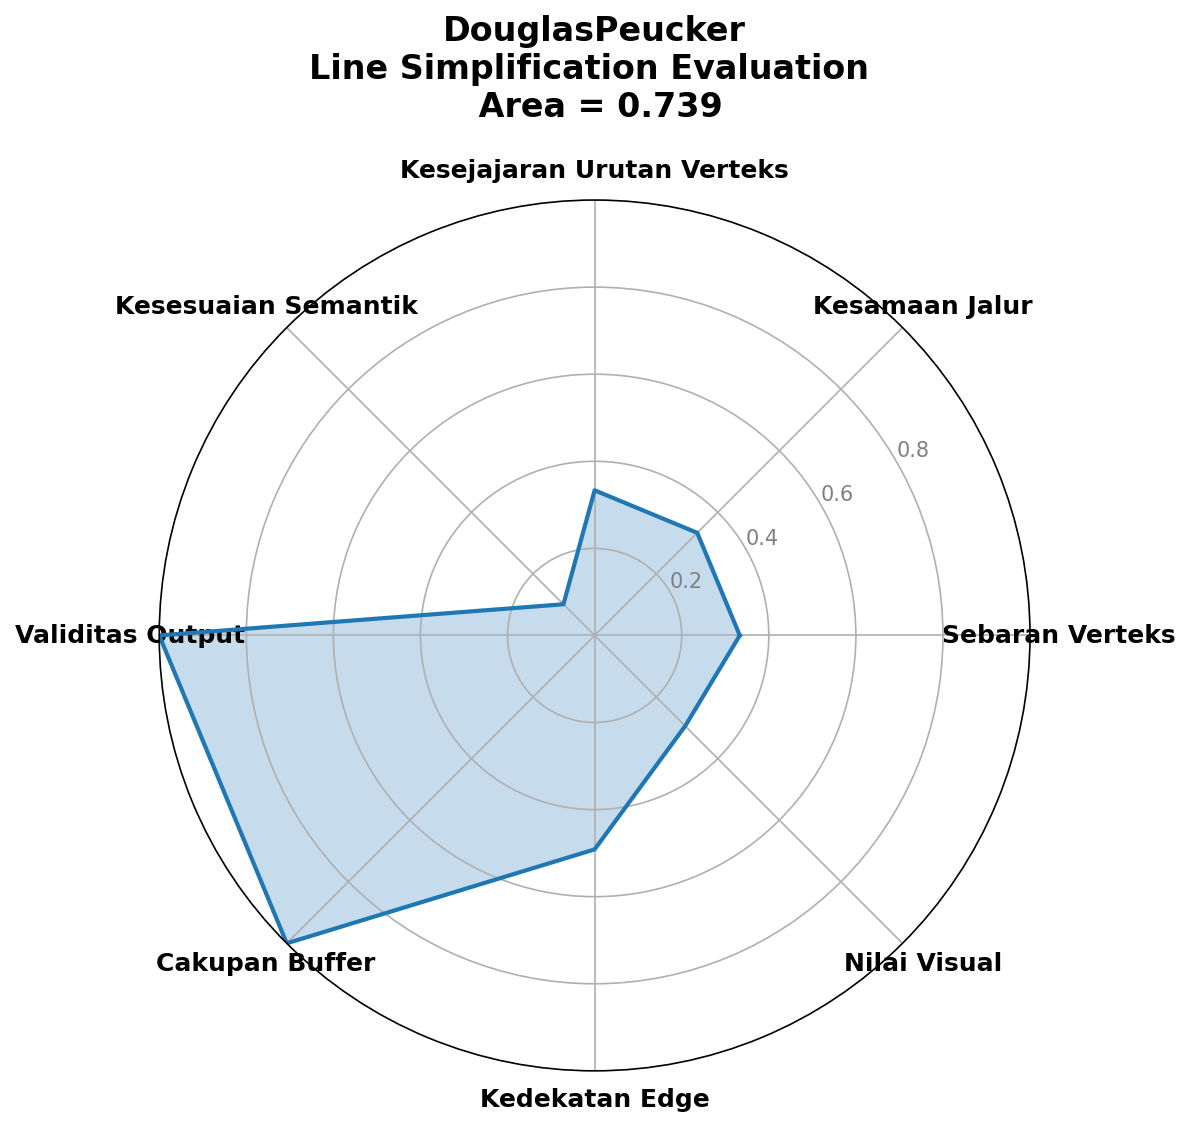

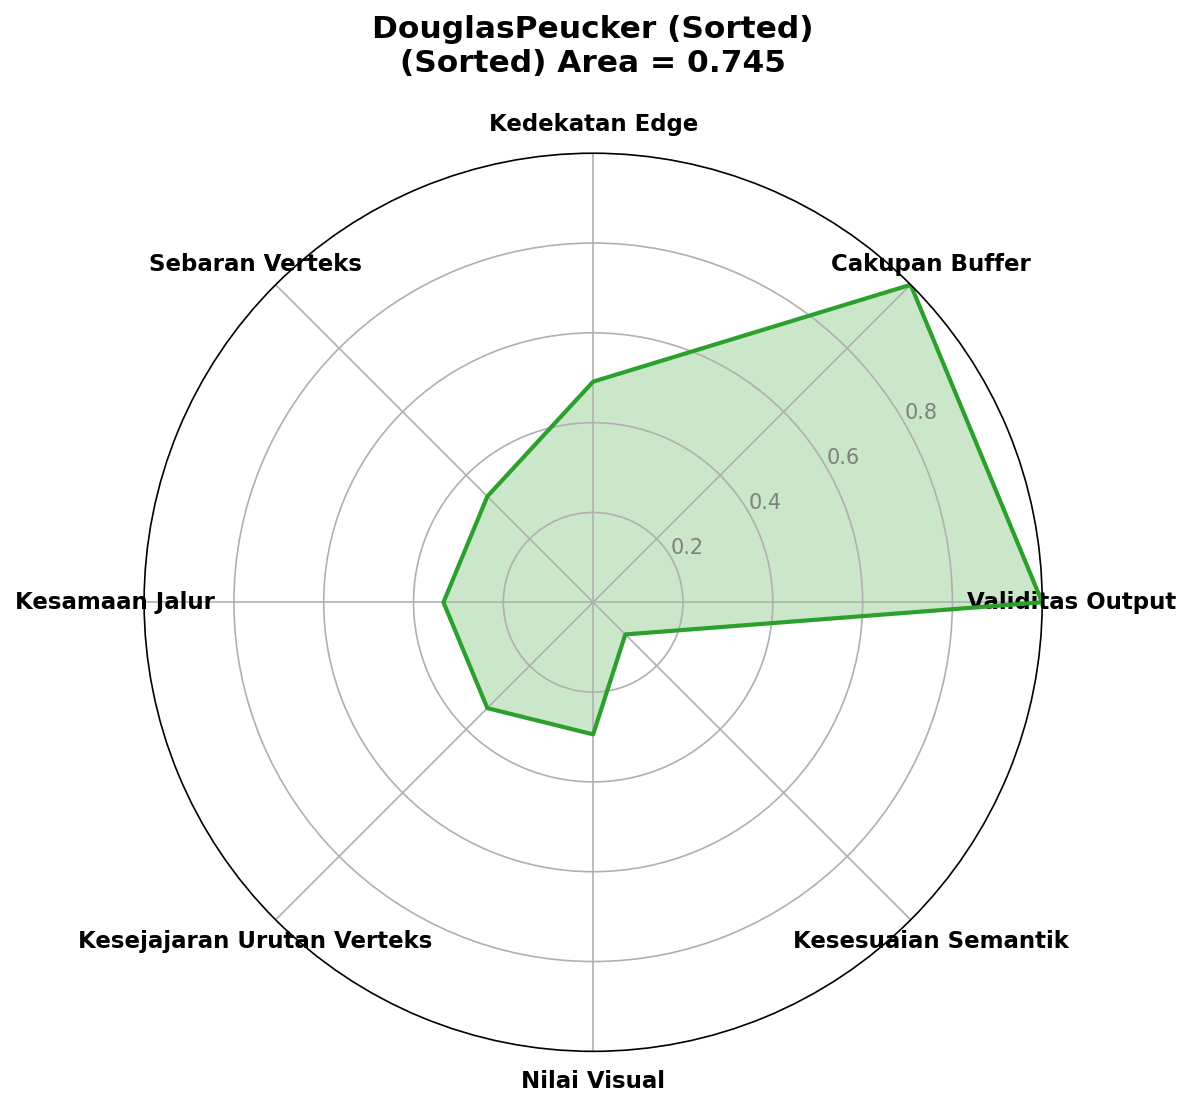

DouglasPeucker sorted radar area: 0.7448
VisvalingamWhyatt - Raw Metrics:
   hausdorff: 1.8859
   frechet: 1.8859
   dtw: 2.5865
   semantic: 0.9985
   topology: 1.0000
   segment_hausdorff: 0.2216
   circular_coverage: 1.0000
   visual_consistency: 0.9999

VisvalingamWhyatt - Normalized Radar Scores:
   hausdorff: 0.994
   frechet: 0.994
   dtw: 1.000
   semantic: 0.999
   topology: 1.000
   segment_hausdorff: 0.995
   circular_coverage: 1.000
   visual_consistency: 1.000



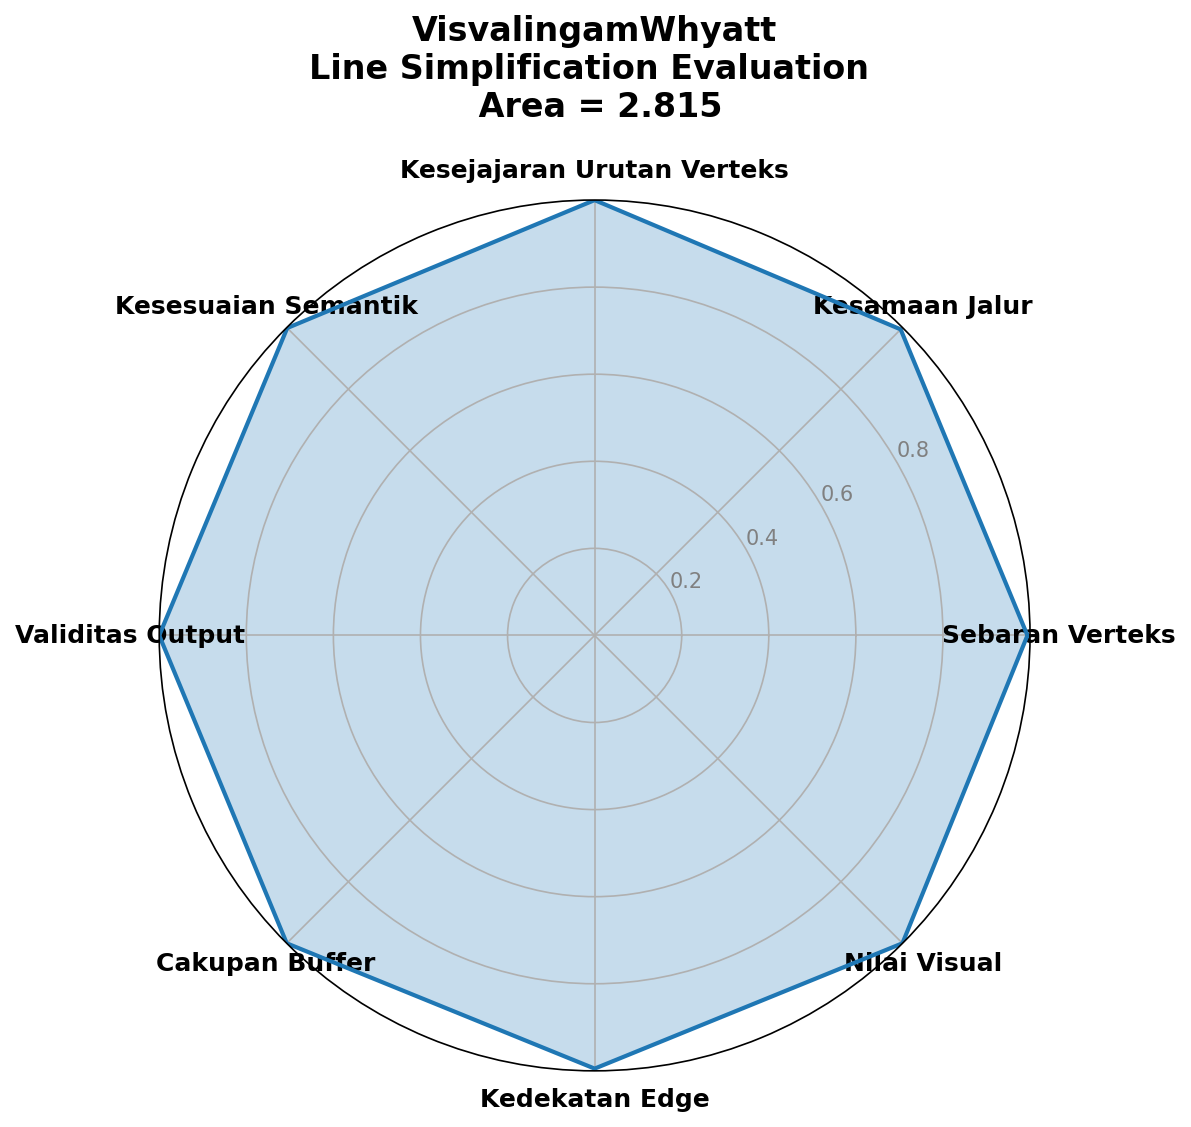

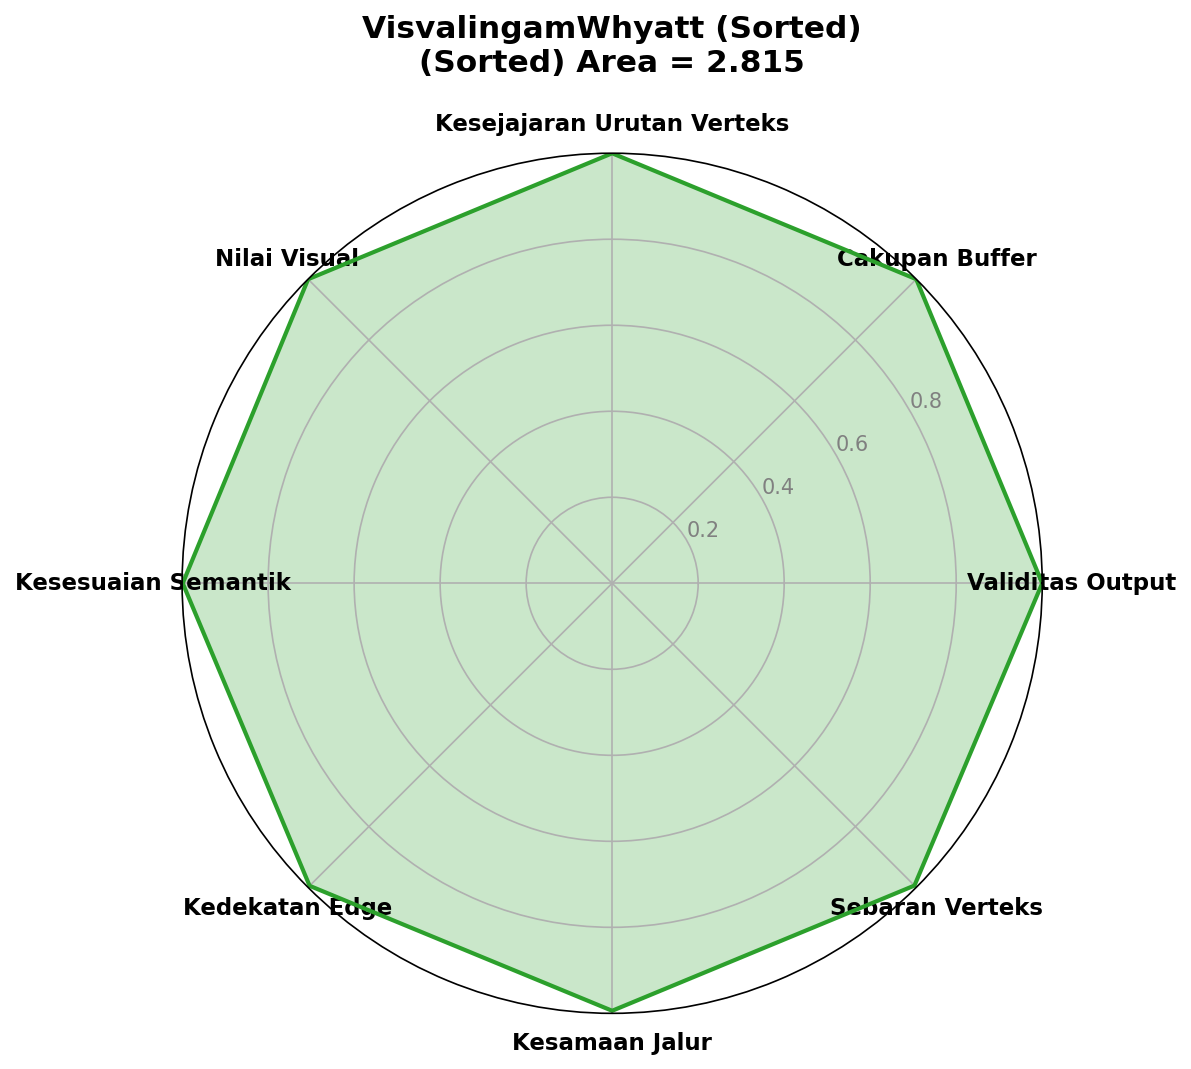

VisvalingamWhyatt sorted radar area: 2.8152
ProgressiveAlgorithm - Raw Metrics:
   hausdorff: 0.0493
   frechet: 0.0493
   dtw: 0.0783
   semantic: 1.0000
   topology: 1.0000
   segment_hausdorff: 0.0000
   circular_coverage: 1.0000
   visual_consistency: 1.0000

ProgressiveAlgorithm - Normalized Radar Scores:
   hausdorff: 1.000
   frechet: 1.000
   dtw: 1.000
   semantic: 1.000
   topology: 1.000
   segment_hausdorff: 1.000
   circular_coverage: 1.000
   visual_consistency: 1.000



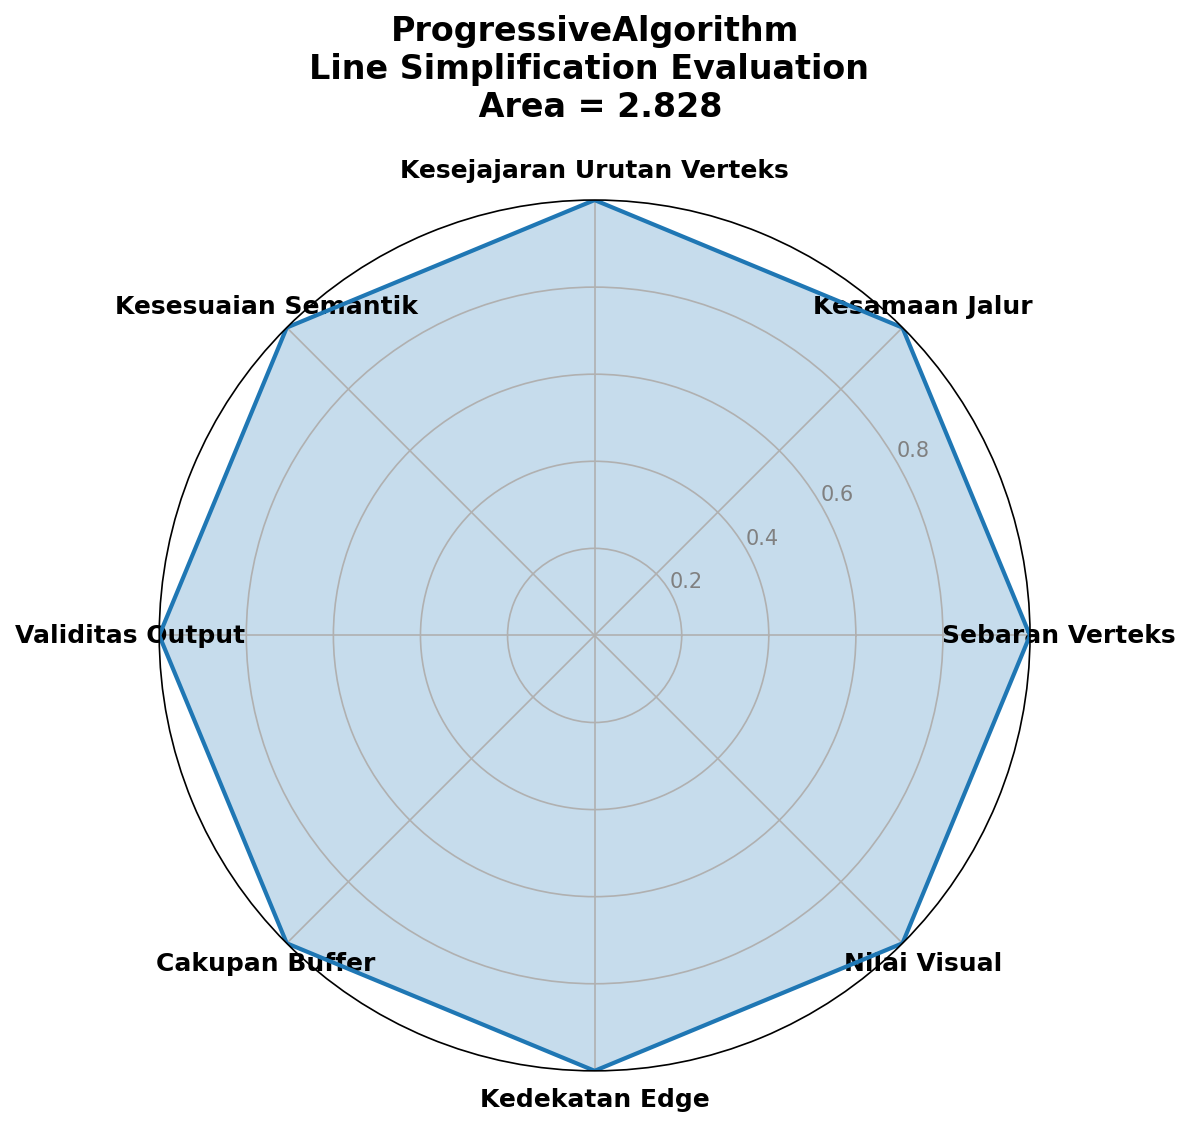

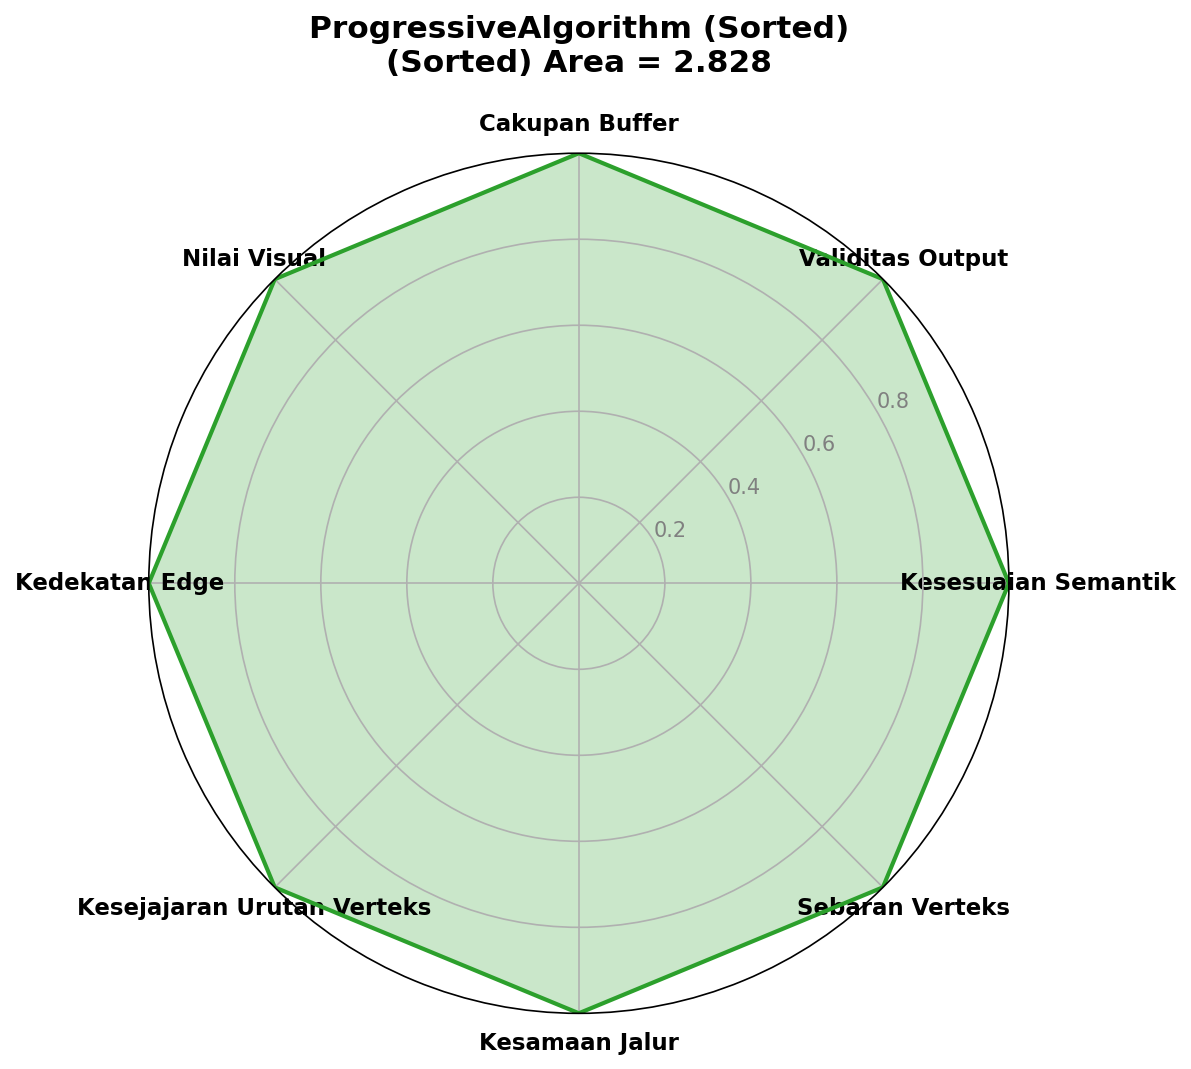

ProgressiveAlgorithm sorted radar area: 2.8282
CircleAlgorithm - Raw Metrics:
   hausdorff: 9.6987
   frechet: 9.6987
   dtw: 524.7234
   semantic: 0.8128
   topology: 1.0000
   segment_hausdorff: 3.2454
   circular_coverage: 1.0000
   visual_consistency: 0.9648

CircleAlgorithm - Normalized Radar Scores:
   hausdorff: 0.969
   frechet: 0.969
   dtw: 0.977
   semantic: 0.813
   topology: 1.000
   segment_hausdorff: 0.926
   circular_coverage: 1.000
   visual_consistency: 0.965



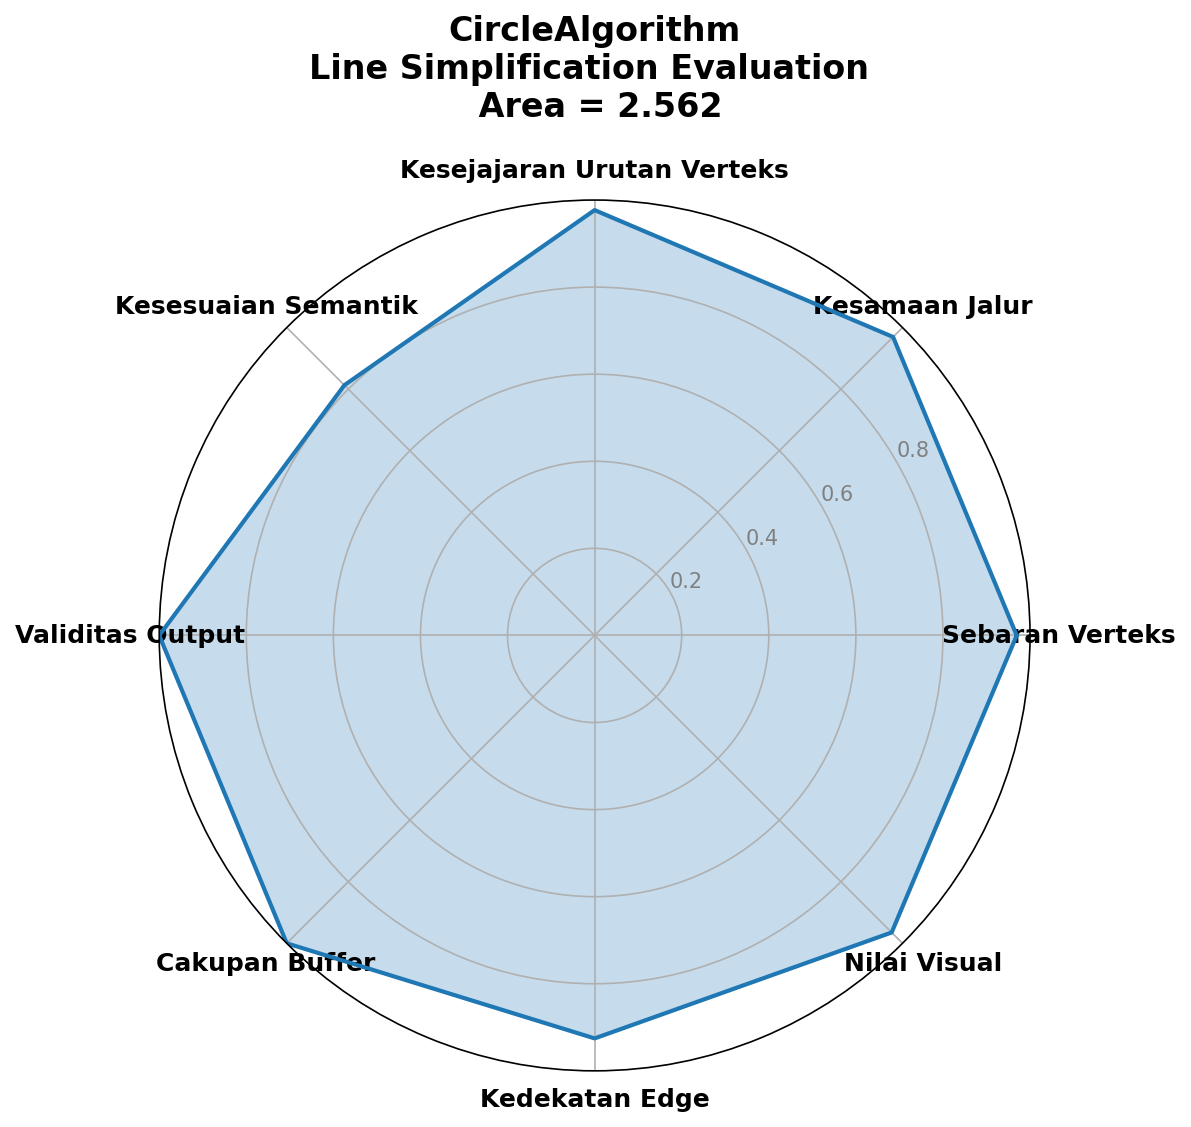

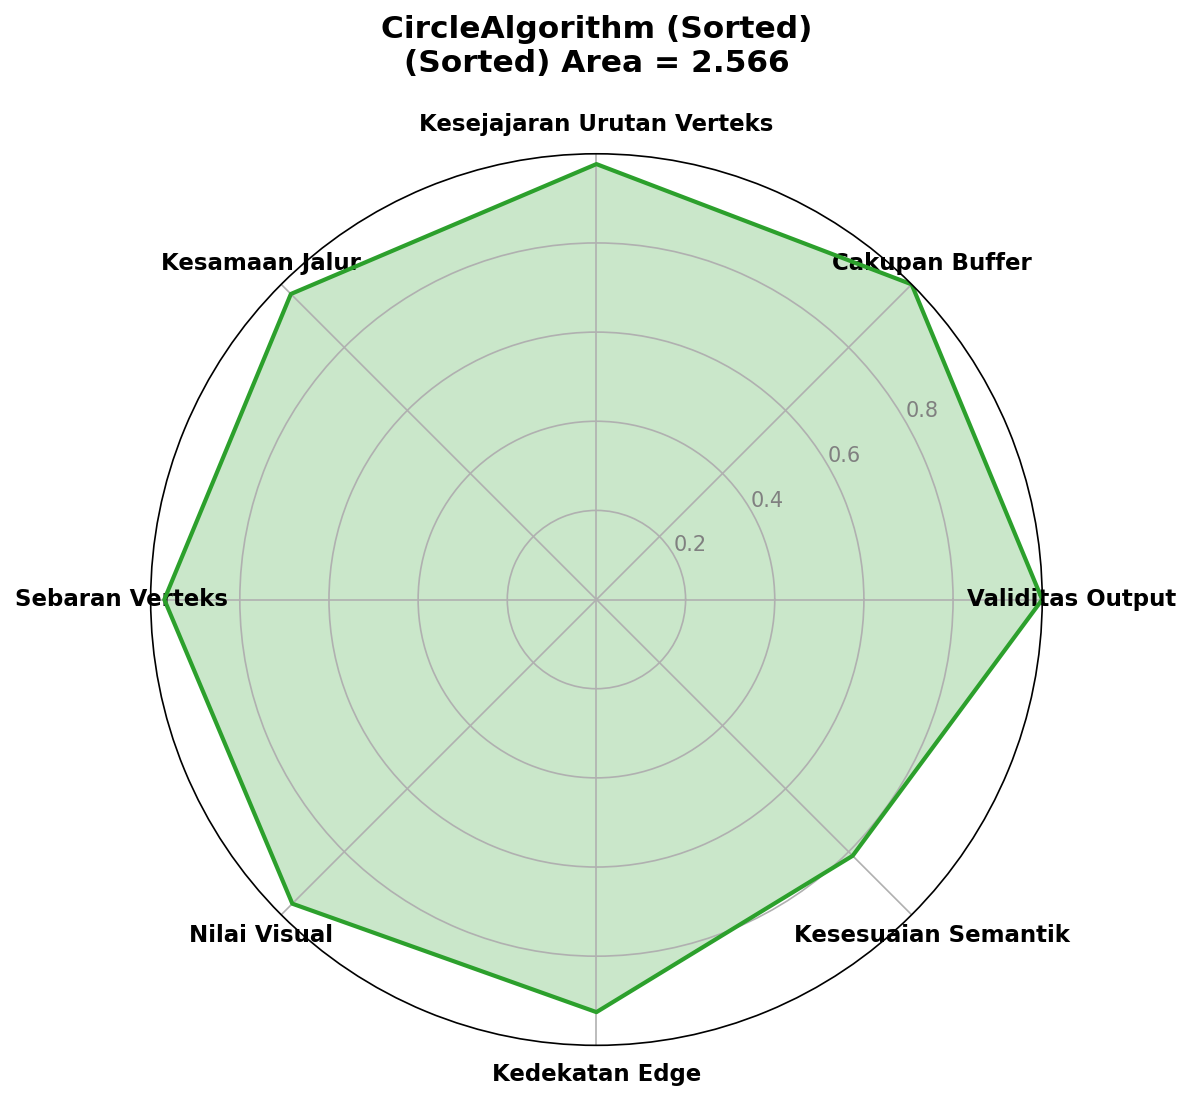

CircleAlgorithm sorted radar area: 2.5657
AngleAlgorithm - Raw Metrics:
   hausdorff: 87.0915
   frechet: 87.1115
   dtw: 2811.5214
   semantic: 0.7356
   topology: 1.0000
   segment_hausdorff: 12.2458
   circular_coverage: 0.9991
   visual_consistency: 0.8500

AngleAlgorithm - Normalized Radar Scores:
   hausdorff: 0.725
   frechet: 0.725
   dtw: 0.876
   semantic: 0.736
   topology: 1.000
   segment_hausdorff: 0.719
   circular_coverage: 0.999
   visual_consistency: 0.850



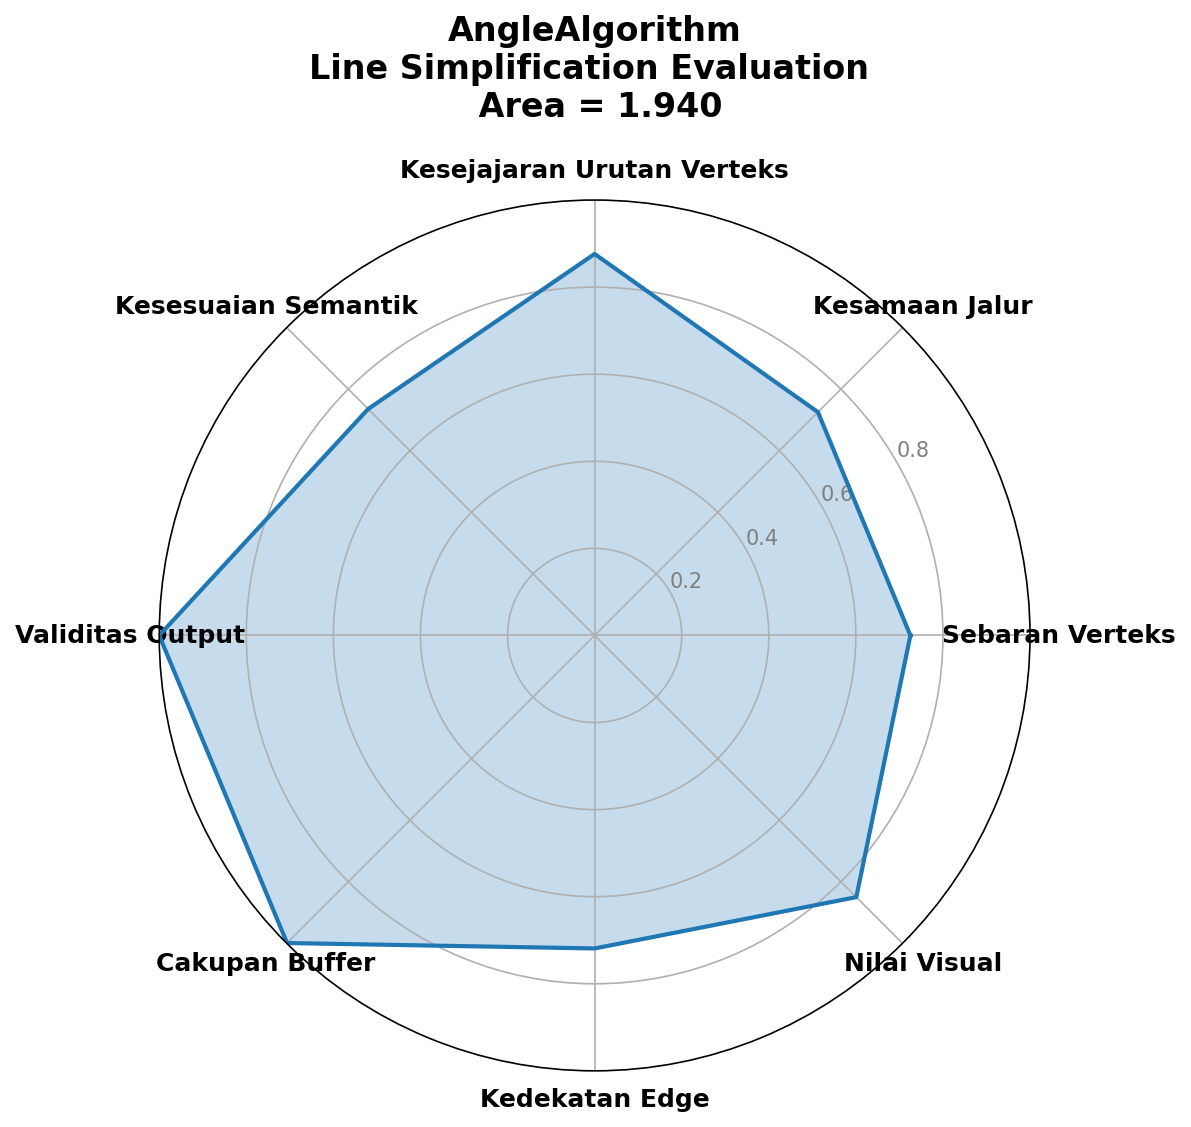

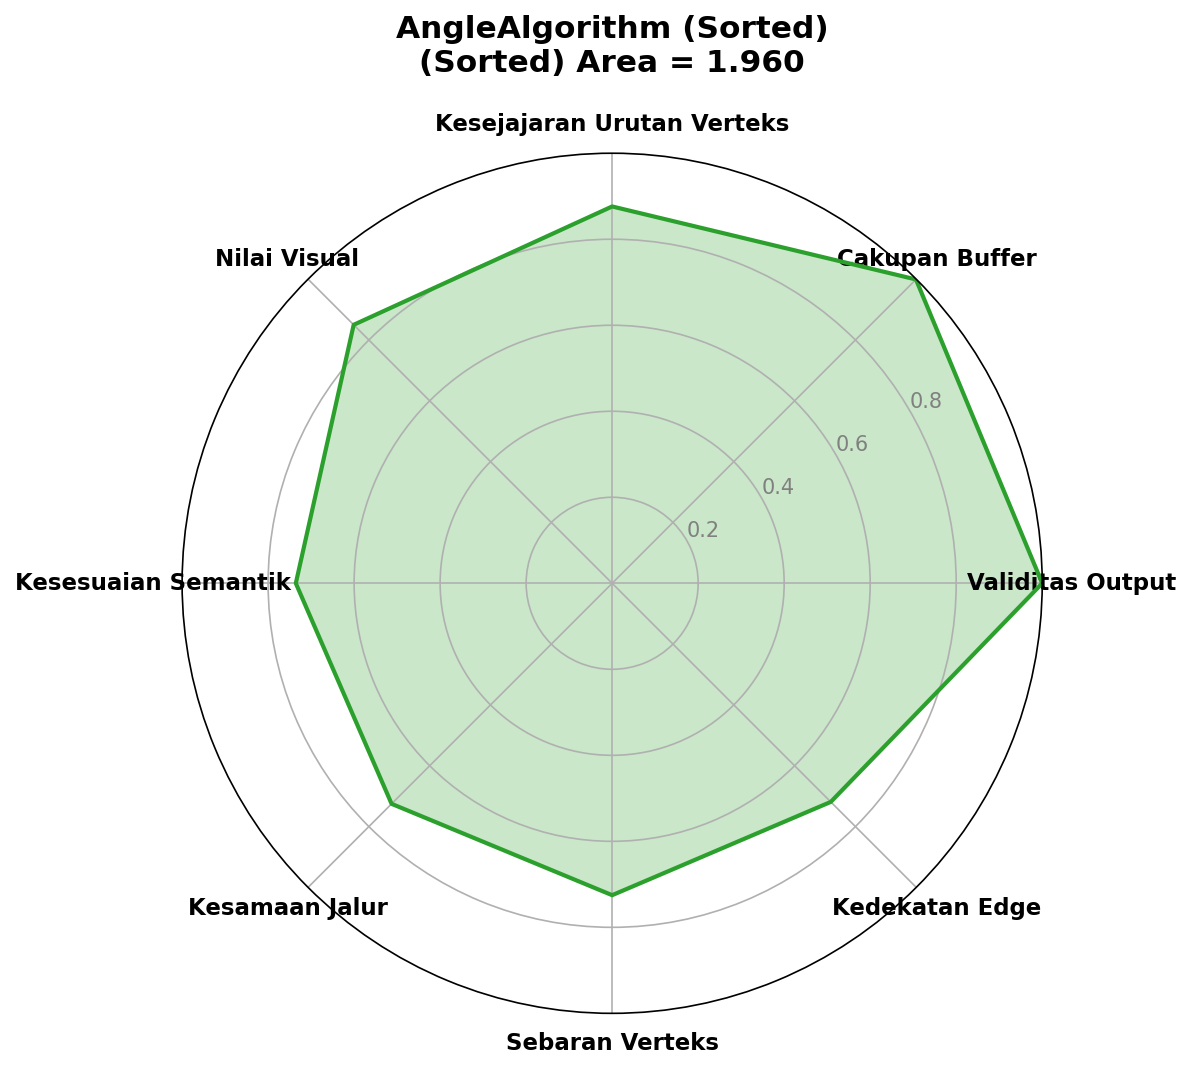

AngleAlgorithm sorted radar area: 1.9602
ReumannWitkam - Raw Metrics:
   hausdorff: 23.2608
   frechet: 23.2611
   dtw: 1690.7870
   semantic: 0.4306
   topology: 1.0000
   segment_hausdorff: 9.5587
   circular_coverage: 1.0000
   visual_consistency: 0.8411

ReumannWitkam - Normalized Radar Scores:
   hausdorff: 0.927
   frechet: 0.927
   dtw: 0.926
   semantic: 0.431
   topology: 1.000
   segment_hausdorff: 0.781
   circular_coverage: 1.000
   visual_consistency: 0.841



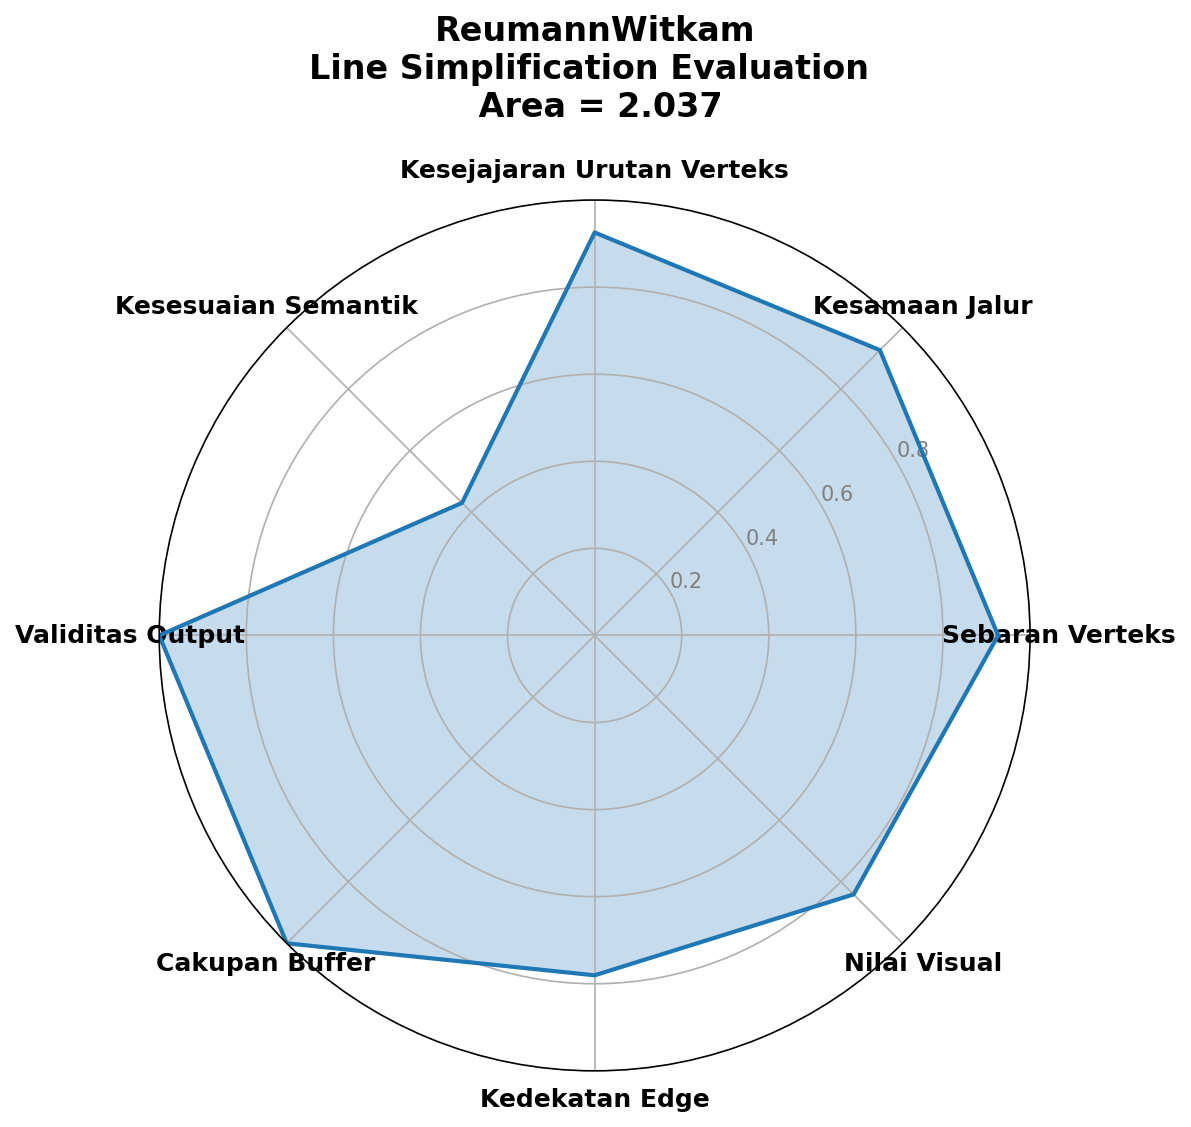

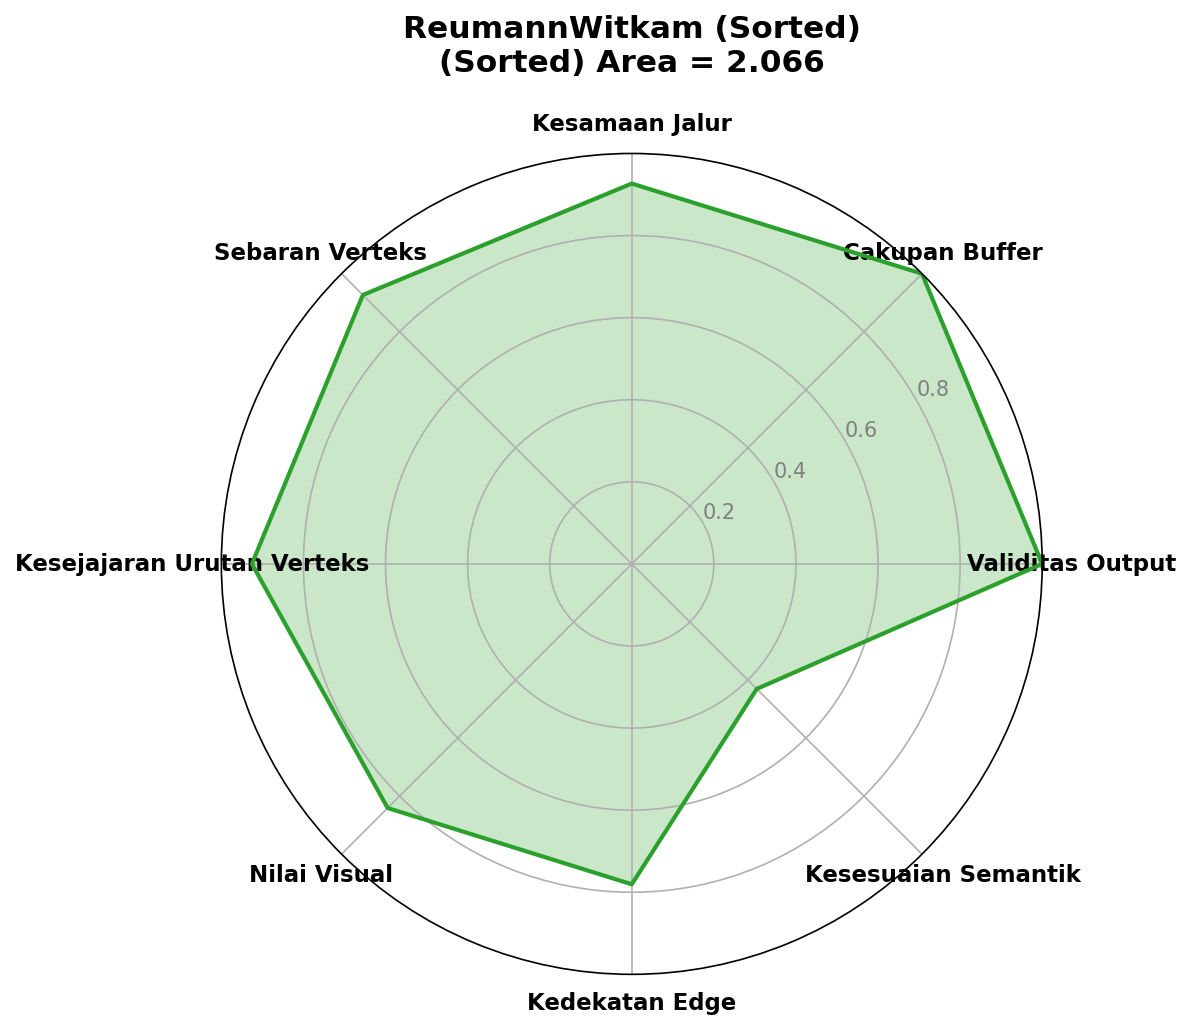

ReumannWitkam sorted radar area: 2.0665
LangSimplification - Raw Metrics:
   hausdorff: 29.8933
   frechet: 29.8948
   dtw: 1367.9231
   semantic: 0.3308
   topology: 1.0000
   segment_hausdorff: 6.2500
   circular_coverage: 1.0000
   visual_consistency: 0.8916

LangSimplification - Normalized Radar Scores:
   hausdorff: 0.906
   frechet: 0.906
   dtw: 0.940
   semantic: 0.331
   topology: 1.000
   segment_hausdorff: 0.857
   circular_coverage: 1.000
   visual_consistency: 0.892



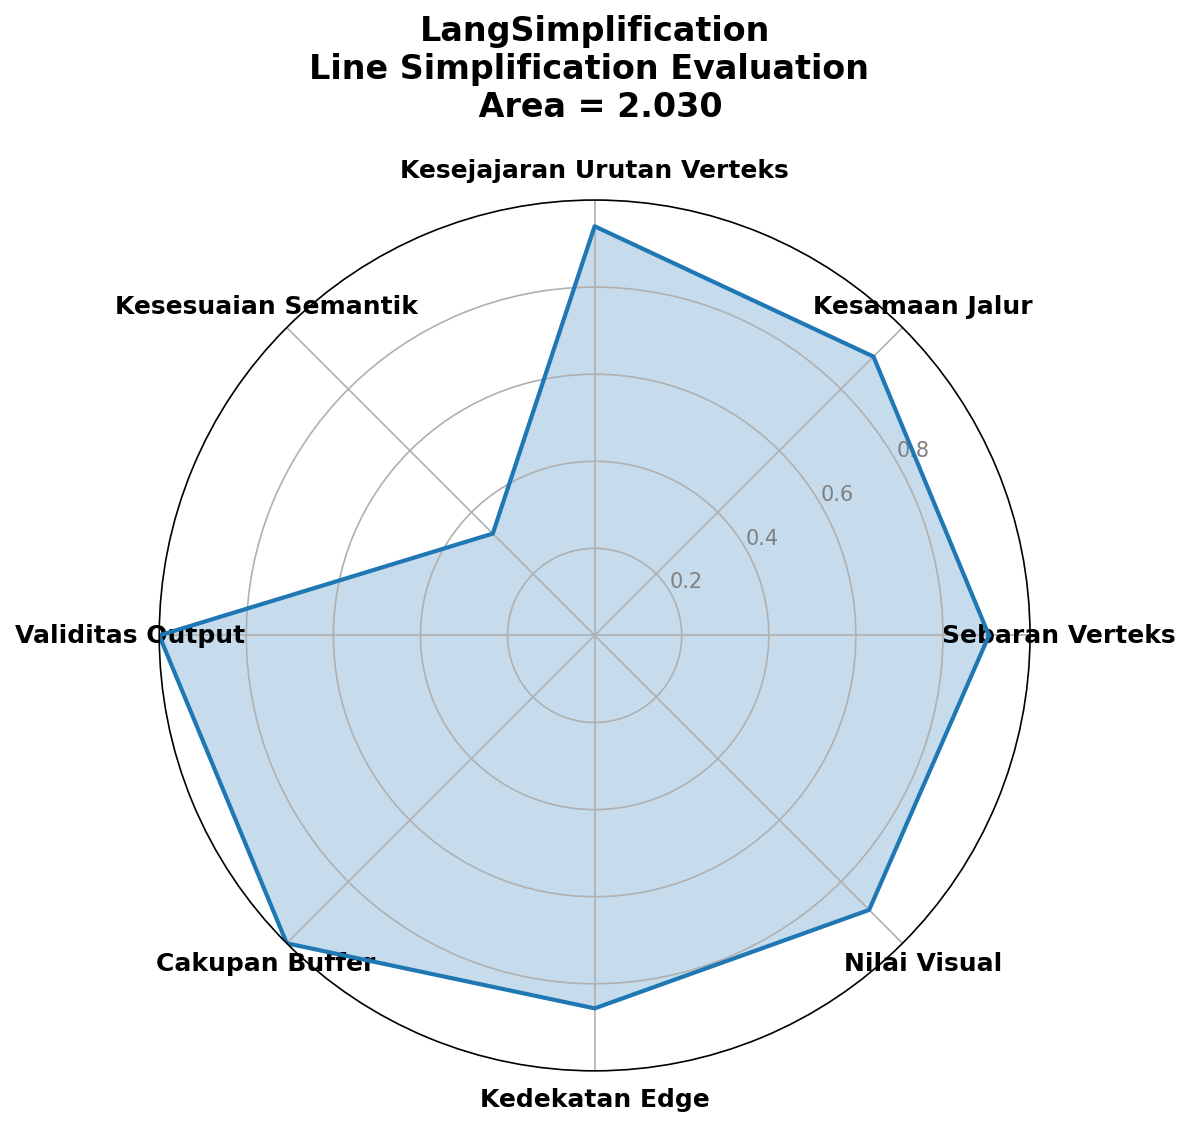

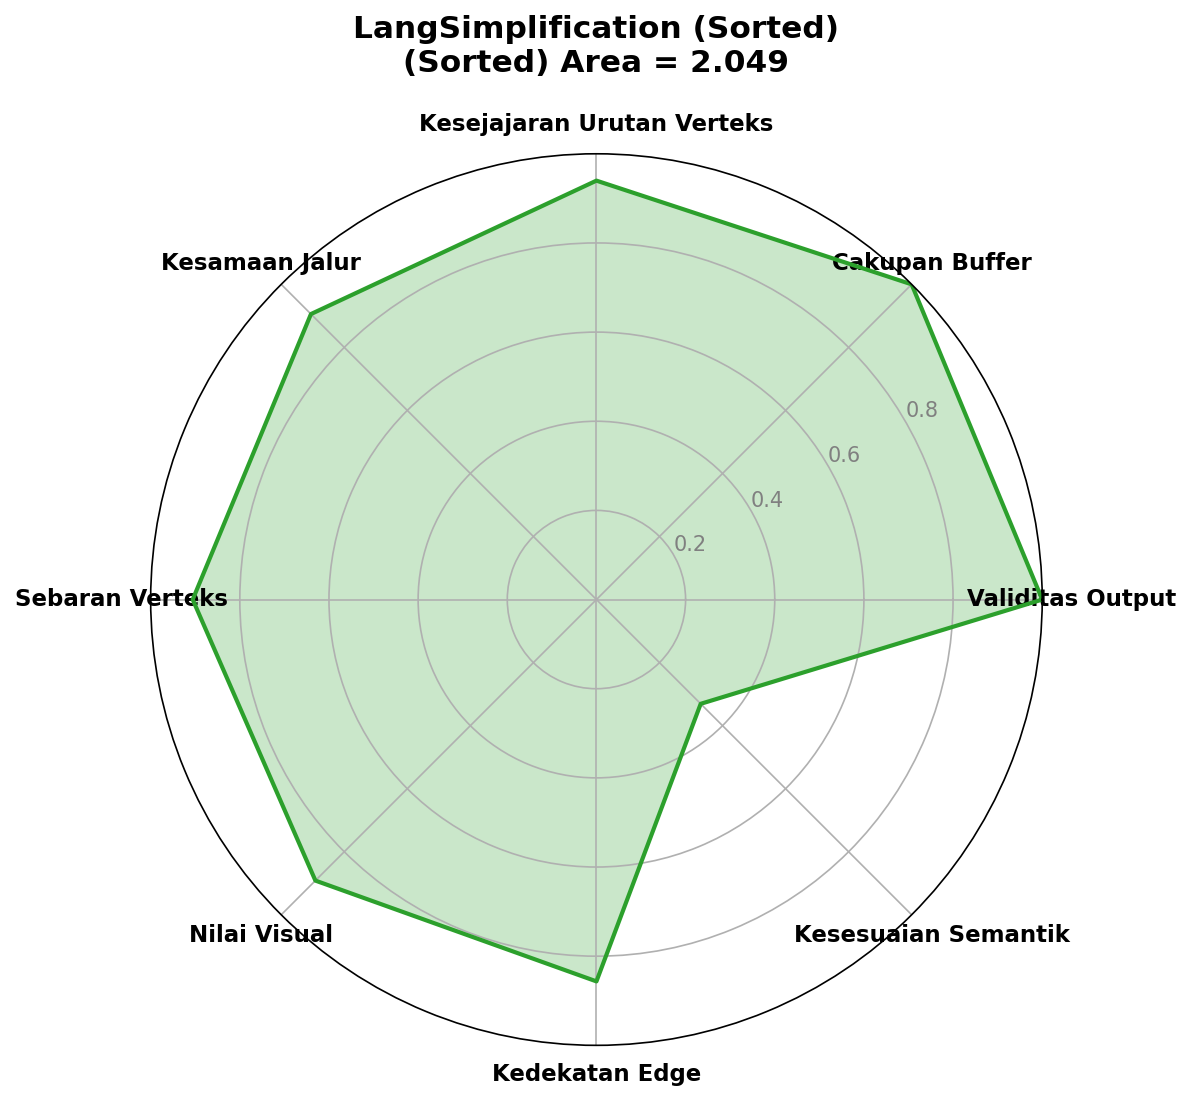

LangSimplification sorted radar area: 2.0494
SleeveFitting - Raw Metrics:
   hausdorff: 156.7458
   frechet: 156.9965
   dtw: 9748.2212
   semantic: 0.3705
   topology: 0.9957
   segment_hausdorff: 29.0449
   circular_coverage: 1.0000
   visual_consistency: 0.6724

SleeveFitting - Normalized Radar Scores:
   hausdorff: 0.506
   frechet: 0.505
   dtw: 0.571
   semantic: 0.371
   topology: 0.996
   segment_hausdorff: 0.333
   circular_coverage: 1.000
   visual_consistency: 0.672



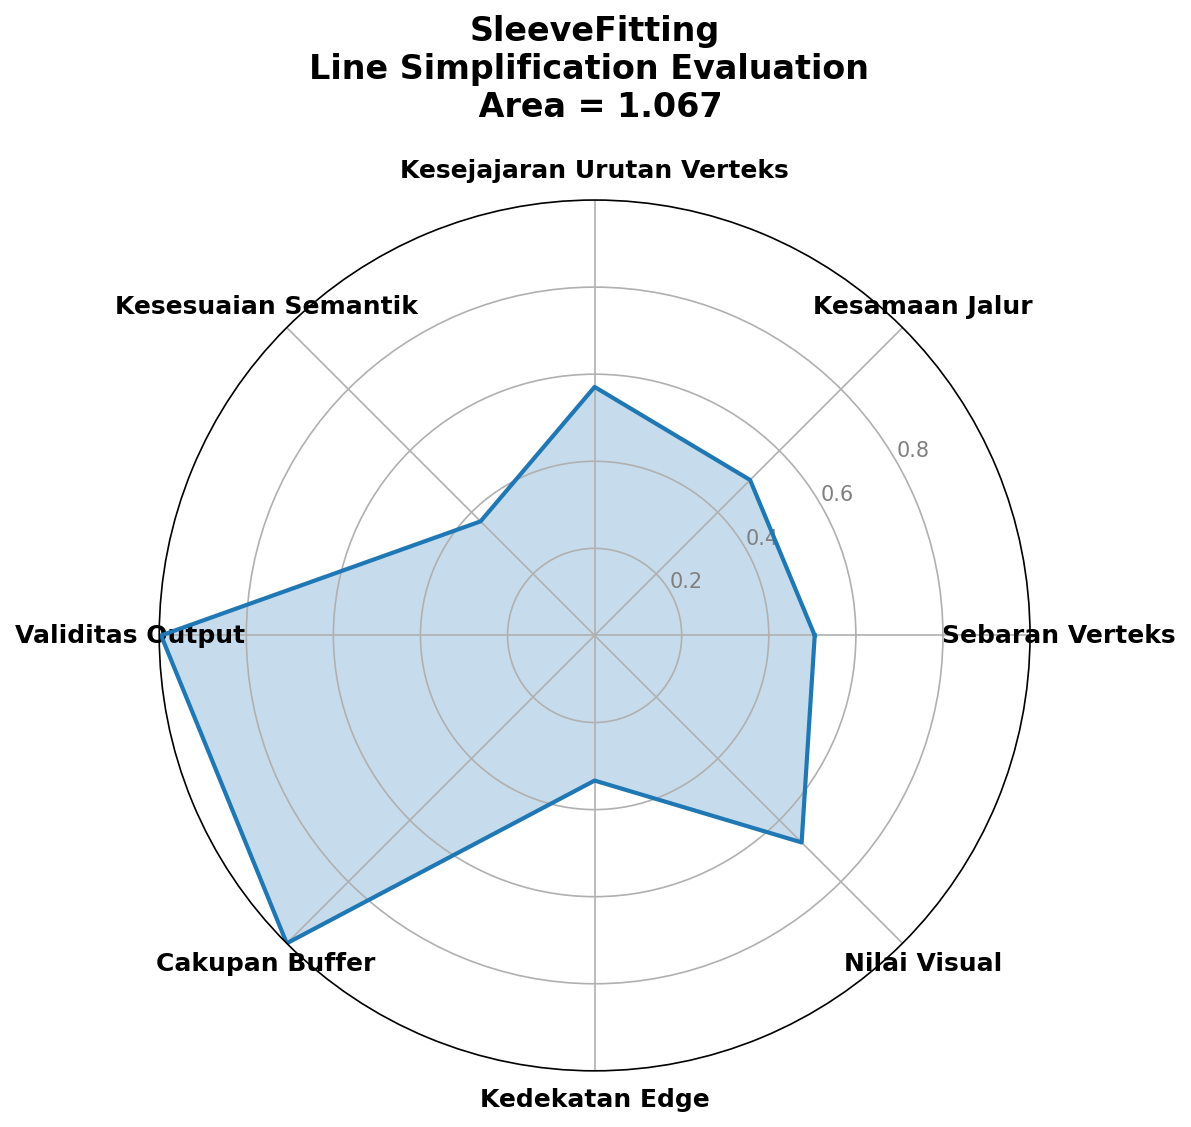

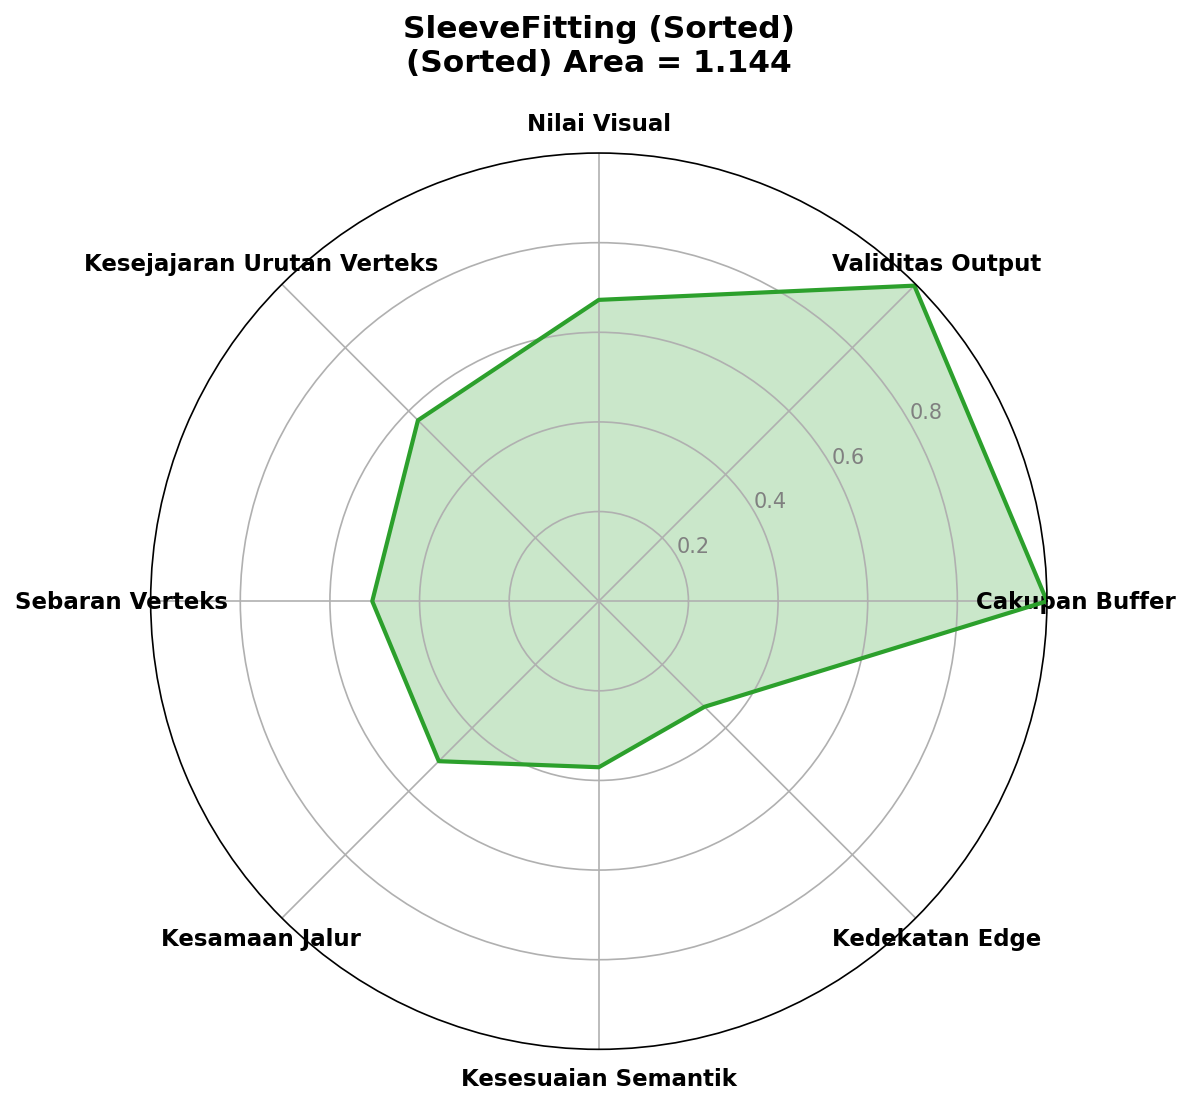

SleeveFitting sorted radar area: 1.1444
LiOpenshaw - Raw Metrics:
   hausdorff: 28.1975
   frechet: 28.1991
   dtw: 3459.0139
   semantic: 0.0000
   topology: 1.0000
   segment_hausdorff: 23.1770
   circular_coverage: 0.9999
   visual_consistency: 0.4720

LiOpenshaw - Normalized Radar Scores:
   hausdorff: 0.911
   frechet: 0.911
   dtw: 0.848
   semantic: 0.000
   topology: 1.000
   segment_hausdorff: 0.468
   circular_coverage: 1.000
   visual_consistency: 0.472



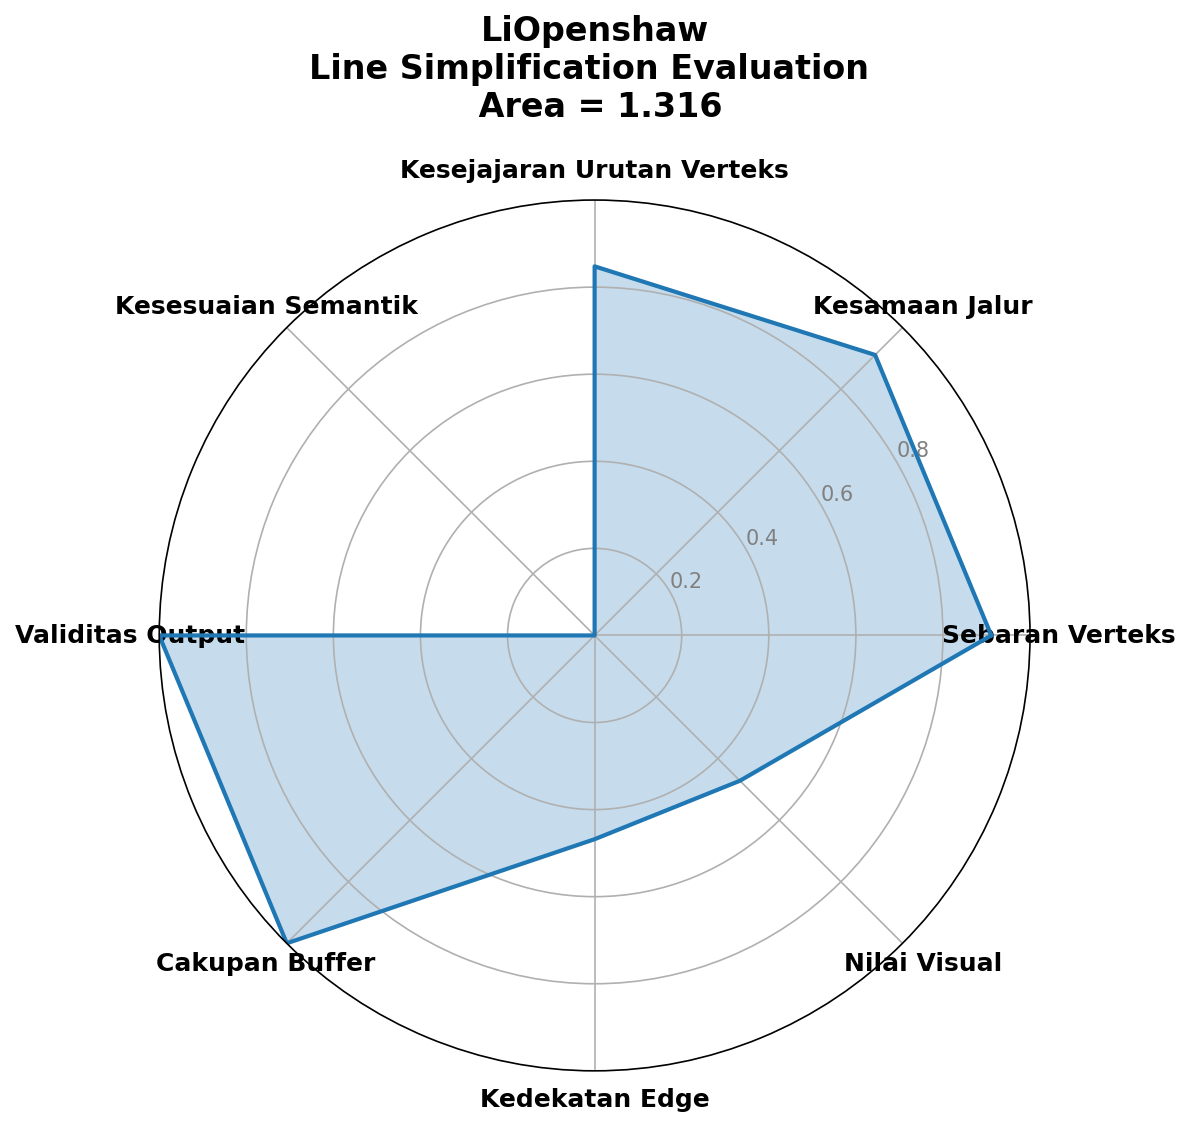

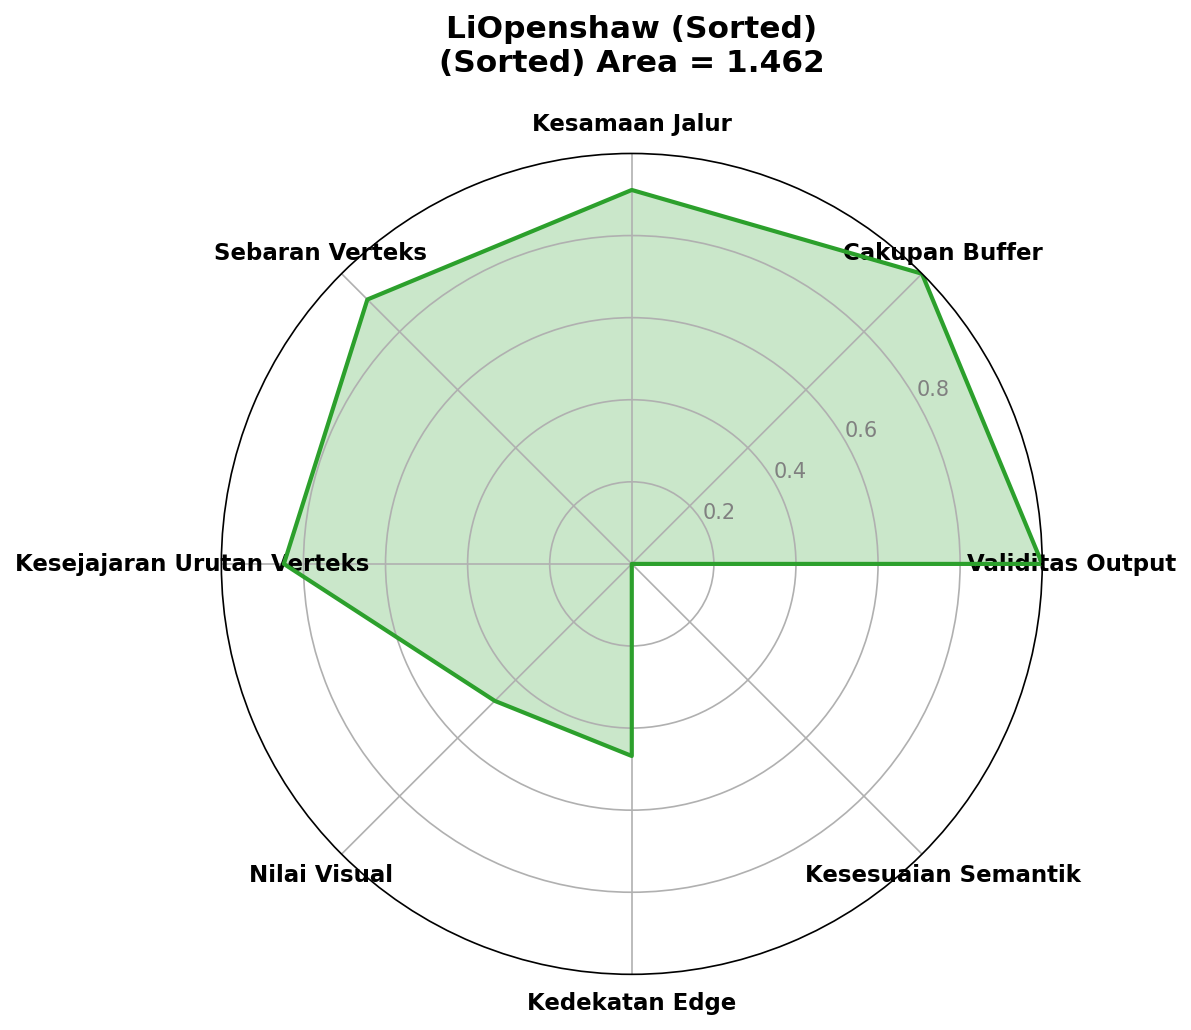

LiOpenshaw sorted radar area: 1.4617

 Ranking by Sorted Radar Area:
1. ProgressiveAlgorithm: area = 2.8282
2. VisvalingamWhyatt: area = 2.8152
3. CircleAlgorithm: area = 2.5657
4. ReumannWitkam: area = 2.0665
5. LangSimplification: area = 2.0494
6. AngleAlgorithm: area = 1.9602
7. LiOpenshaw: area = 1.4617
8. SleeveFitting: area = 1.1444
9. DouglasPeucker: area = 0.7448


[{'algorithm': 'DouglasPeucker',
  'sorted_area': 0.744762211611097,
  'metrics': {'hausdorff': np.float64(0.33333333333333337),
   'frechet': np.float64(0.33333333333333337),
   'dtw': np.float64(0.33333333333333326),
   'semantic': 0.10126897858442821,
   'topology': 1.0,
   'segment_hausdorff': np.float64(0.4913780375702299),
   'circular_coverage': 1.0,
   'visual_consistency': 0.29416254753845666}},
 {'algorithm': 'VisvalingamWhyatt',
  'sorted_area': 2.8152127559915354,
  'metrics': {'hausdorff': np.float64(0.9940506192037927),
   'frechet': np.float64(0.9940531557834593),
   'dtw': np.float64(0.9998861128000822),
   'semantic': 0.9985041509810276,
   'topology': 1.0,
   'segment_hausdorff': np.float64(0.9949127099791746),
   'circular_coverage': 1.0,
   'visual_consistency': 0.9998685843792869}},
 {'algorithm': 'ProgressiveAlgorithm',
  'sorted_area': 2.8282046336949085,
  'metrics': {'hausdorff': np.float64(0.9998443822760955),
   'frechet': np.float64(0.999844448625312),
   'd

In [73]:
def render_radar_charts(cache_path="eval_results.pkl", distance_scale_factor=1.5, algorithms=None):
    if not os.path.exists(cache_path):
        raise FileNotFoundError(f"Cache file not found: {cache_path}.")

    with open(cache_path, 'rb') as f:
        data = pickle.load(f)

    raw_metrics = data['raw_metrics']
    global_max = data['global_max']
    target_algos = algorithms or data['algorithms']

    results_summary = []

    for algo in target_algos:
        if algo not in raw_metrics:
            print(f"{algo} not in cache.")
            continue 

        raw = raw_metrics[algo]
        print(f"{algo} - Raw Metrics:")
        for k, v in raw.items():
            print(f"   {k}: {v:.4f}")

        normalized = normalize_metrics_for_radar(raw, global_max, distance_scale_factor=1.5)
        
        print(f"\n{algo} - Normalized Radar Scores:")
        for k, v in normalized.items():
            print(f"   {k}: {v:.3f}")
        print()
        
        display_algorithm_radar_chart(algo, normalized)
        sorted_area = display_sorted_radar_chart(f"{algo} (Sorted)", normalized)

        results_summary.append({
            'algorithm': algo,
            'sorted_area': sorted_area,
            'metrics': normalized
        })

        print(f"{algo} sorted radar area: {sorted_area:.4f}")
        print("="*80)

    print("\n Ranking by Sorted Radar Area:")
    ranked = sorted(results_summary, key=lambda x: x['sorted_area'], reverse=True)
    for i, res in enumerate(ranked, 1):
        print(f"{i}. {res['algorithm']}: area = {res['sorted_area']:.4f}")
    
    return results_summary

render_radar_charts(cache_path="eval_results.pkl", distance_scale_factor=1.5, algorithms=None)

Recalculating visual_consistency
Cache updated successfully.

Rendering updated 8-axis radar charts...

🔹 DouglasPeucker - Normalized Scores:
   hausdorff: 0.333
   frechet: 0.333
   dtw: 0.333
   semantic: 0.359
   topology: 1.000
   segment_hausdorff: 0.629
   circular_coverage: 1.000
   visual_consistency: 0.855


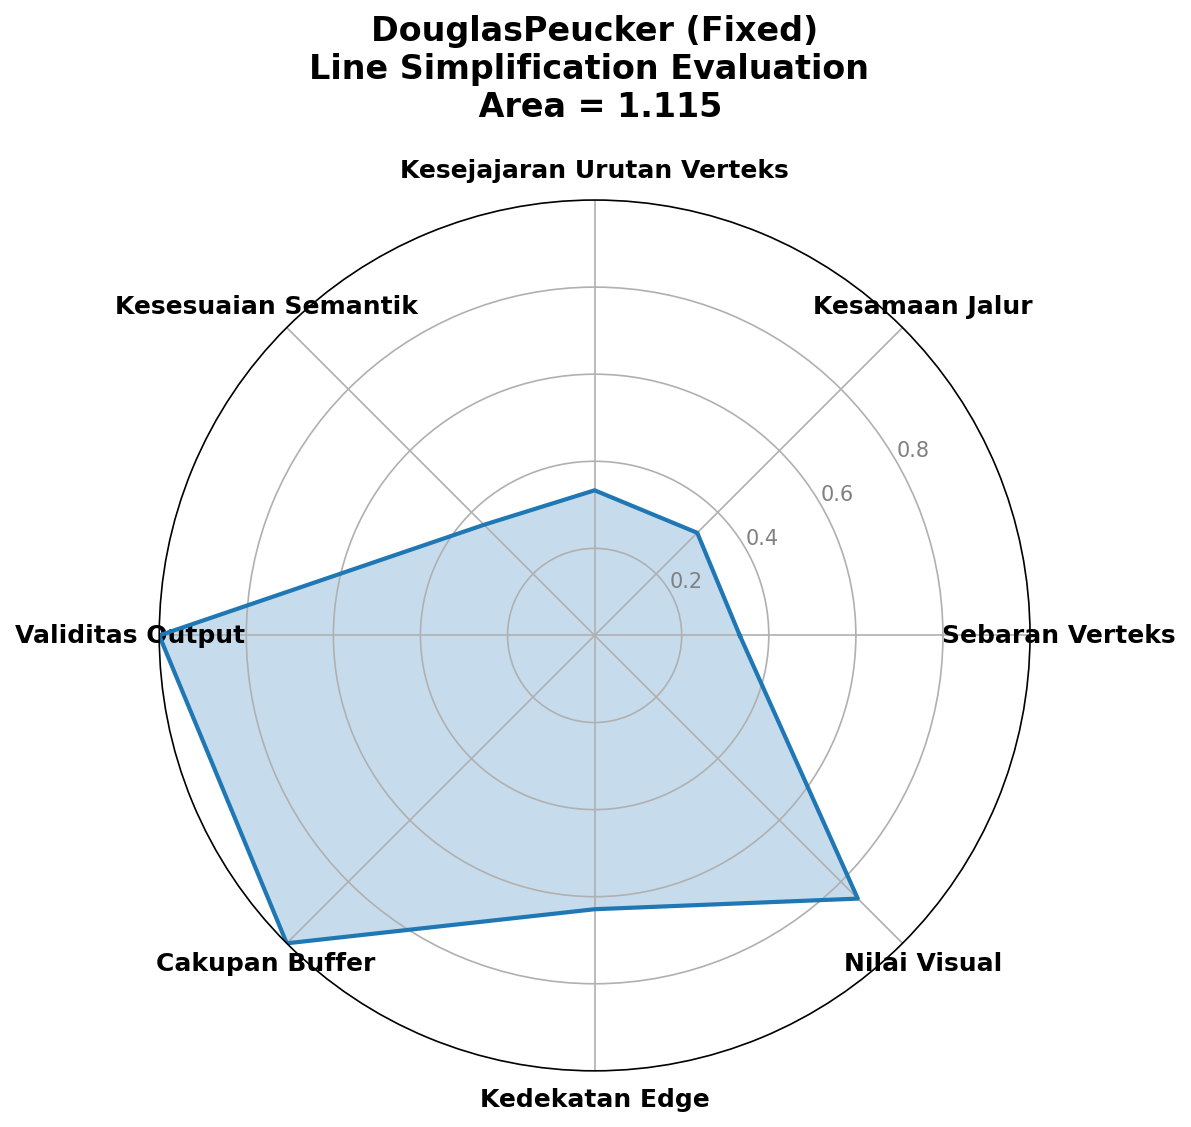

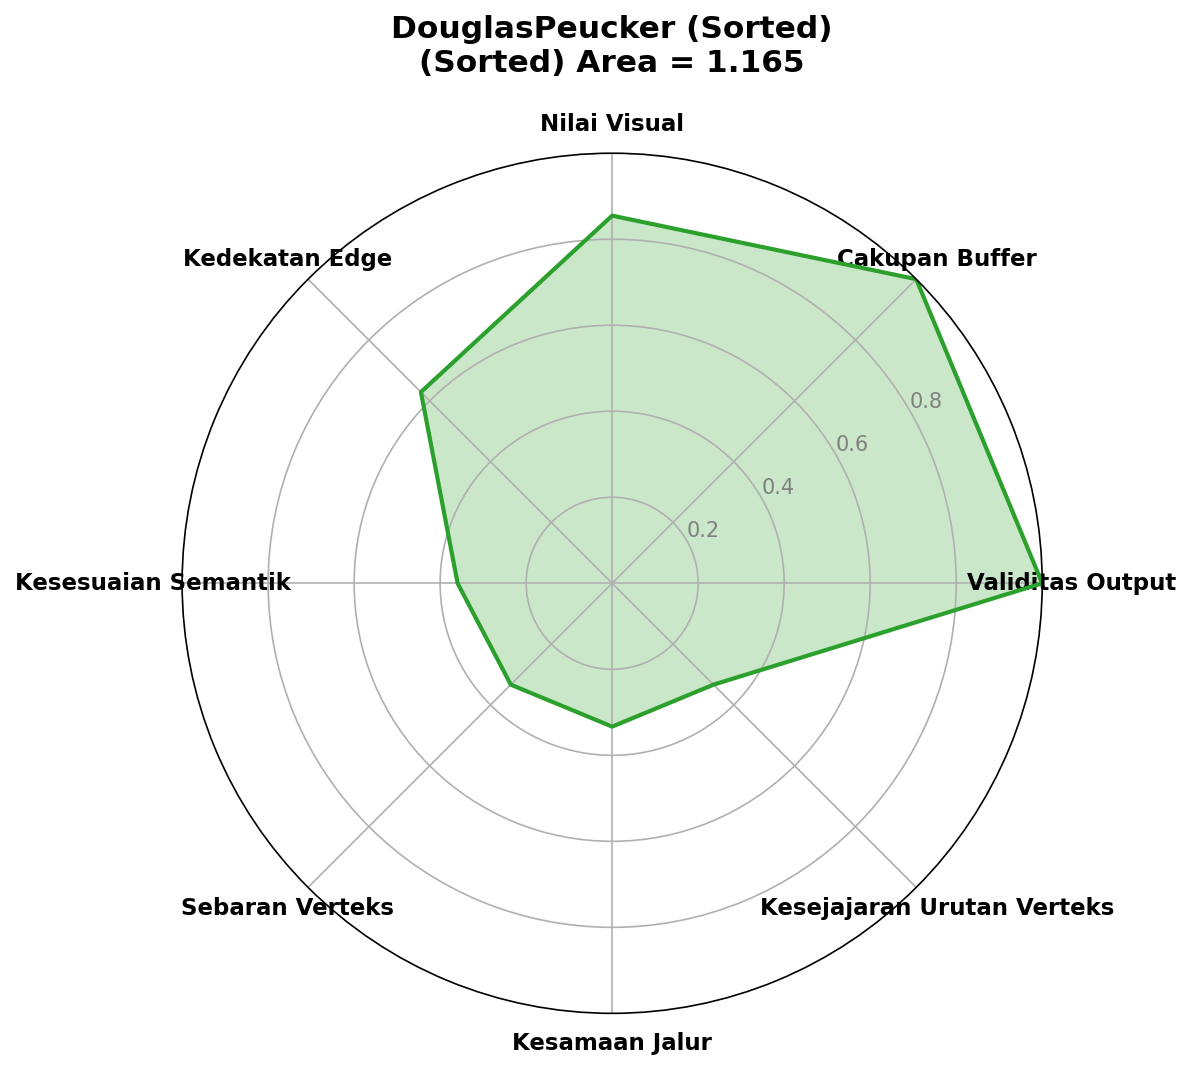

📊 DouglasPeucker sorted area: 1.1645

🔹 VisvalingamWhyatt - Normalized Scores:
   hausdorff: 0.999
   frechet: 0.999
   dtw: 1.000
   semantic: 1.000
   topology: 1.000
   segment_hausdorff: 0.999
   circular_coverage: 1.000
   visual_consistency: 1.000


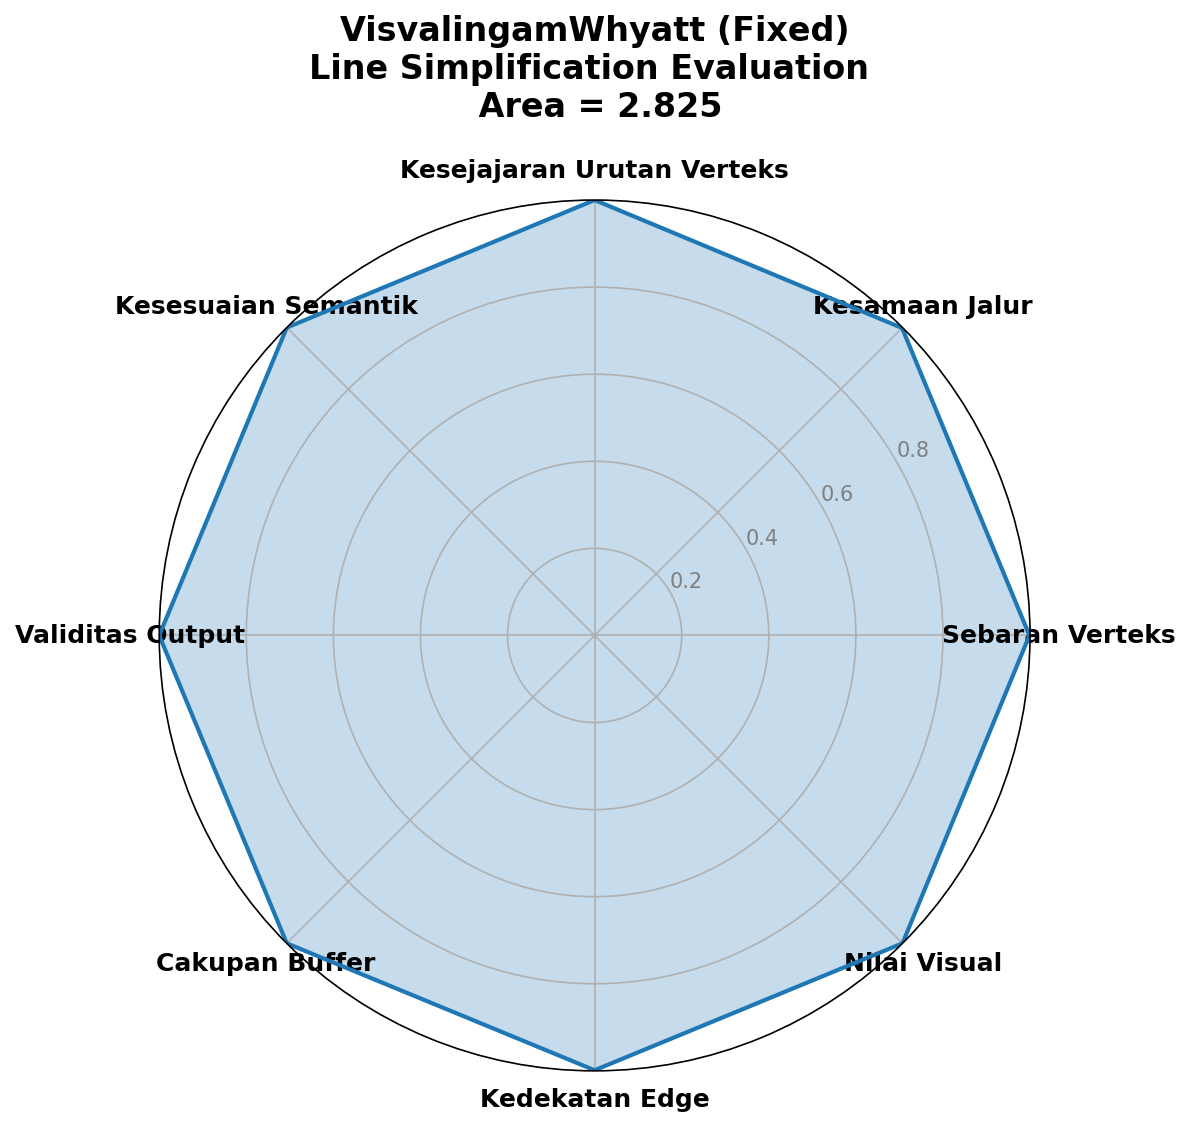

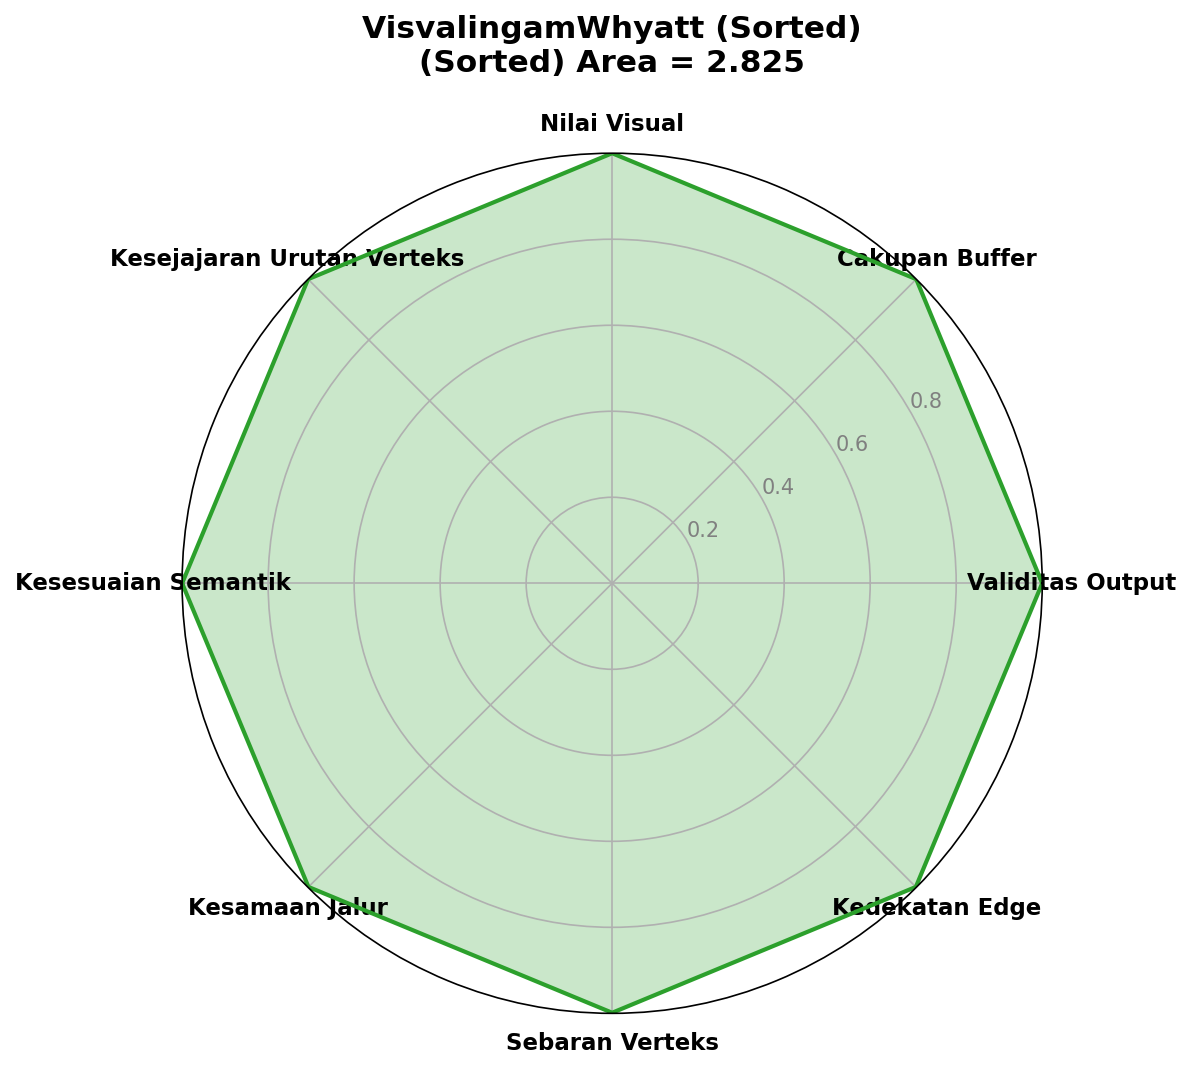

📊 VisvalingamWhyatt sorted area: 2.8255

🔹 ProgressiveAlgorithm - Normalized Scores:
   hausdorff: 1.000
   frechet: 1.000
   dtw: 1.000
   semantic: 1.000
   topology: 1.000
   segment_hausdorff: 1.000
   circular_coverage: 1.000
   visual_consistency: 1.000


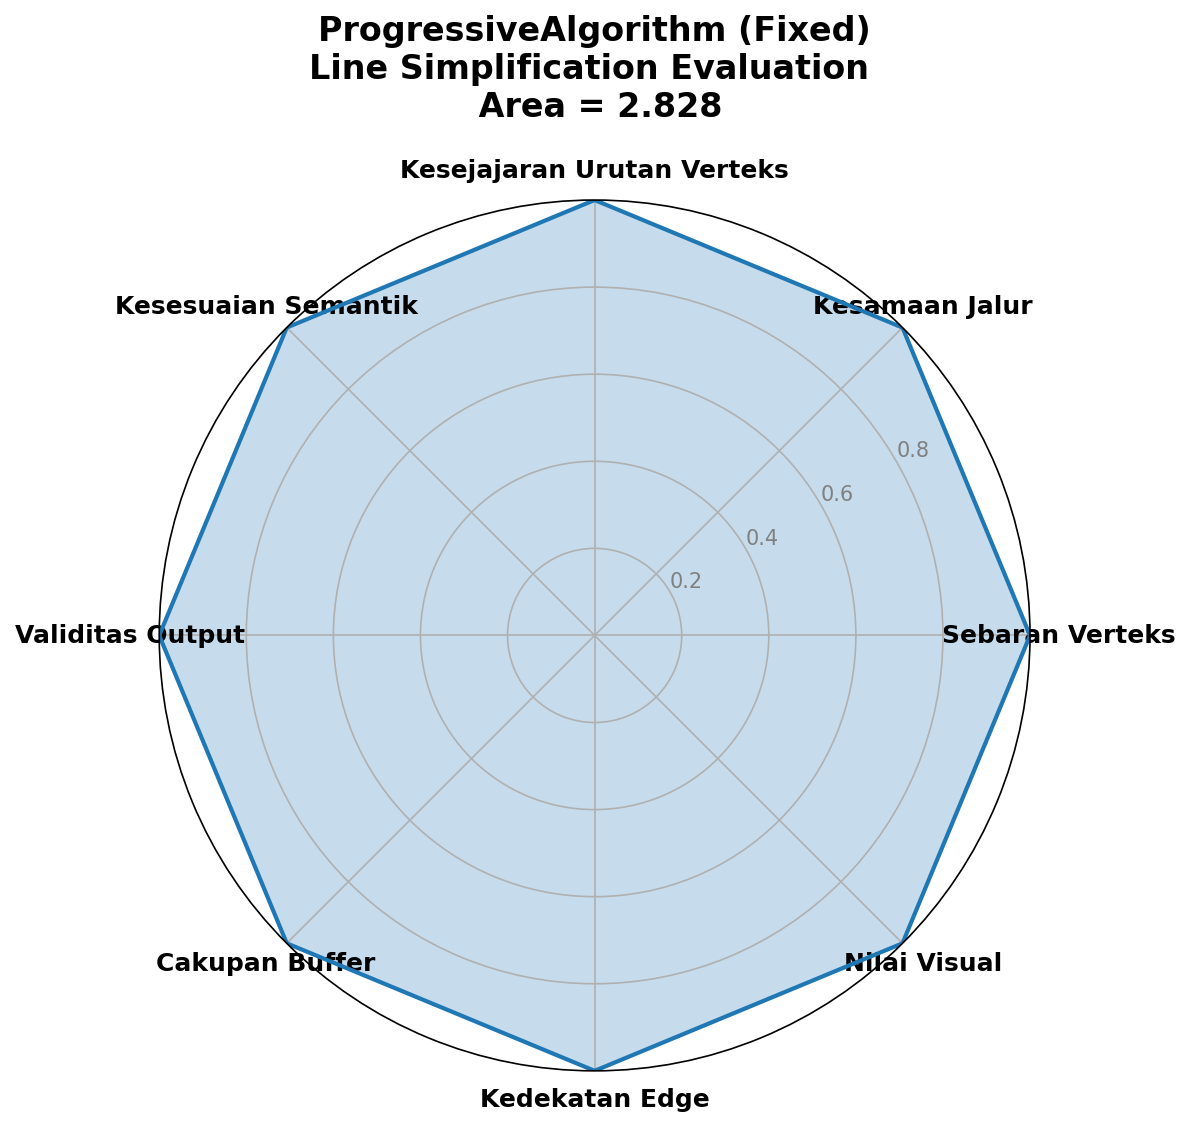

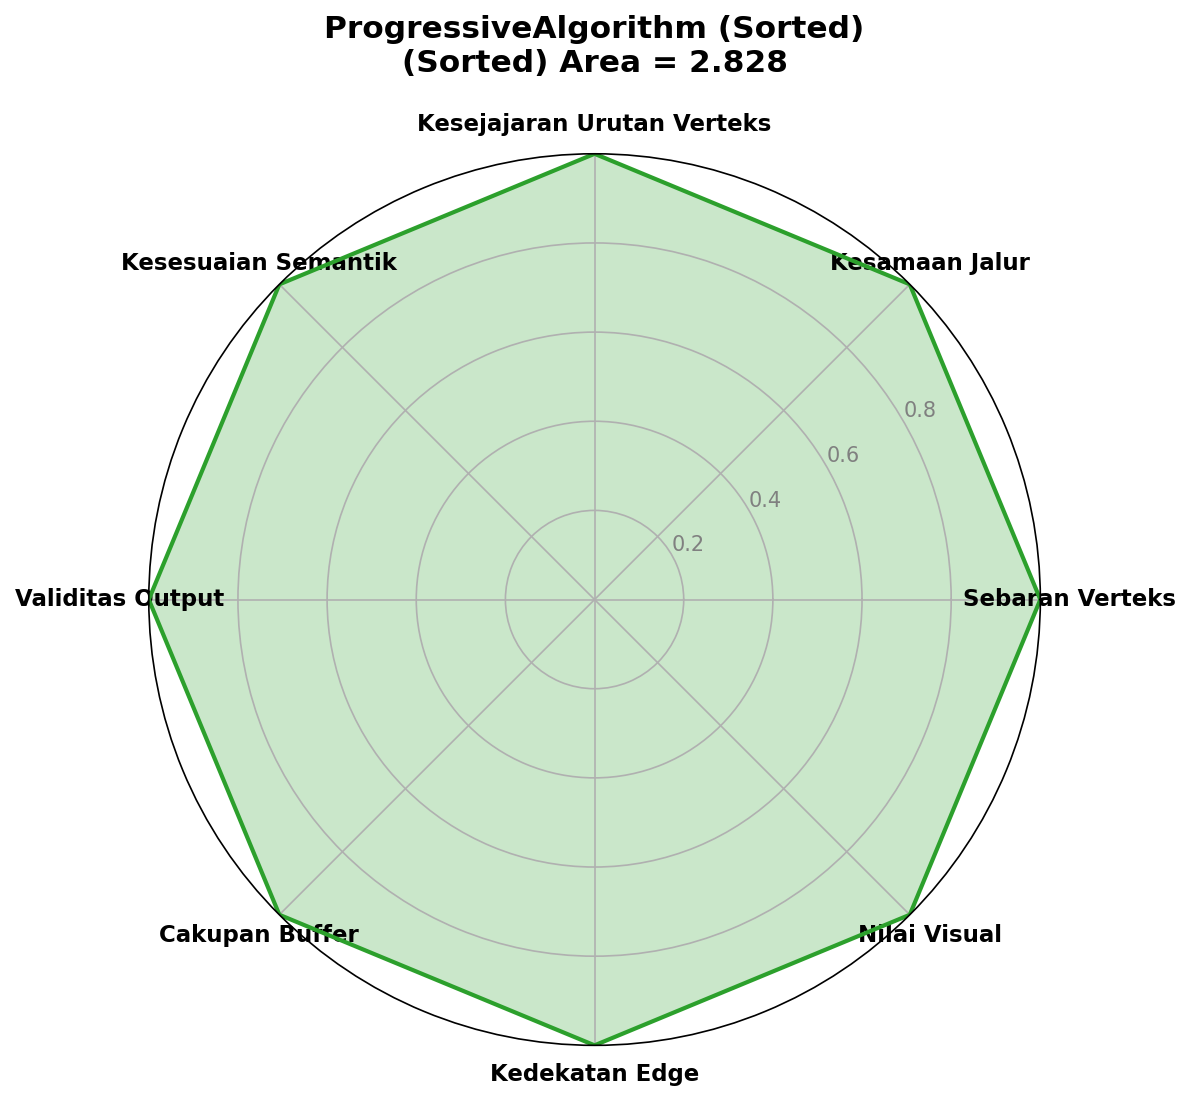

📊 ProgressiveAlgorithm sorted area: 2.8284

🔹 CircleAlgorithm - Normalized Scores:
   hausdorff: 0.985
   frechet: 0.985
   dtw: 0.995
   semantic: 0.995
   topology: 1.000
   segment_hausdorff: 0.939
   circular_coverage: 1.000
   visual_consistency: 0.998


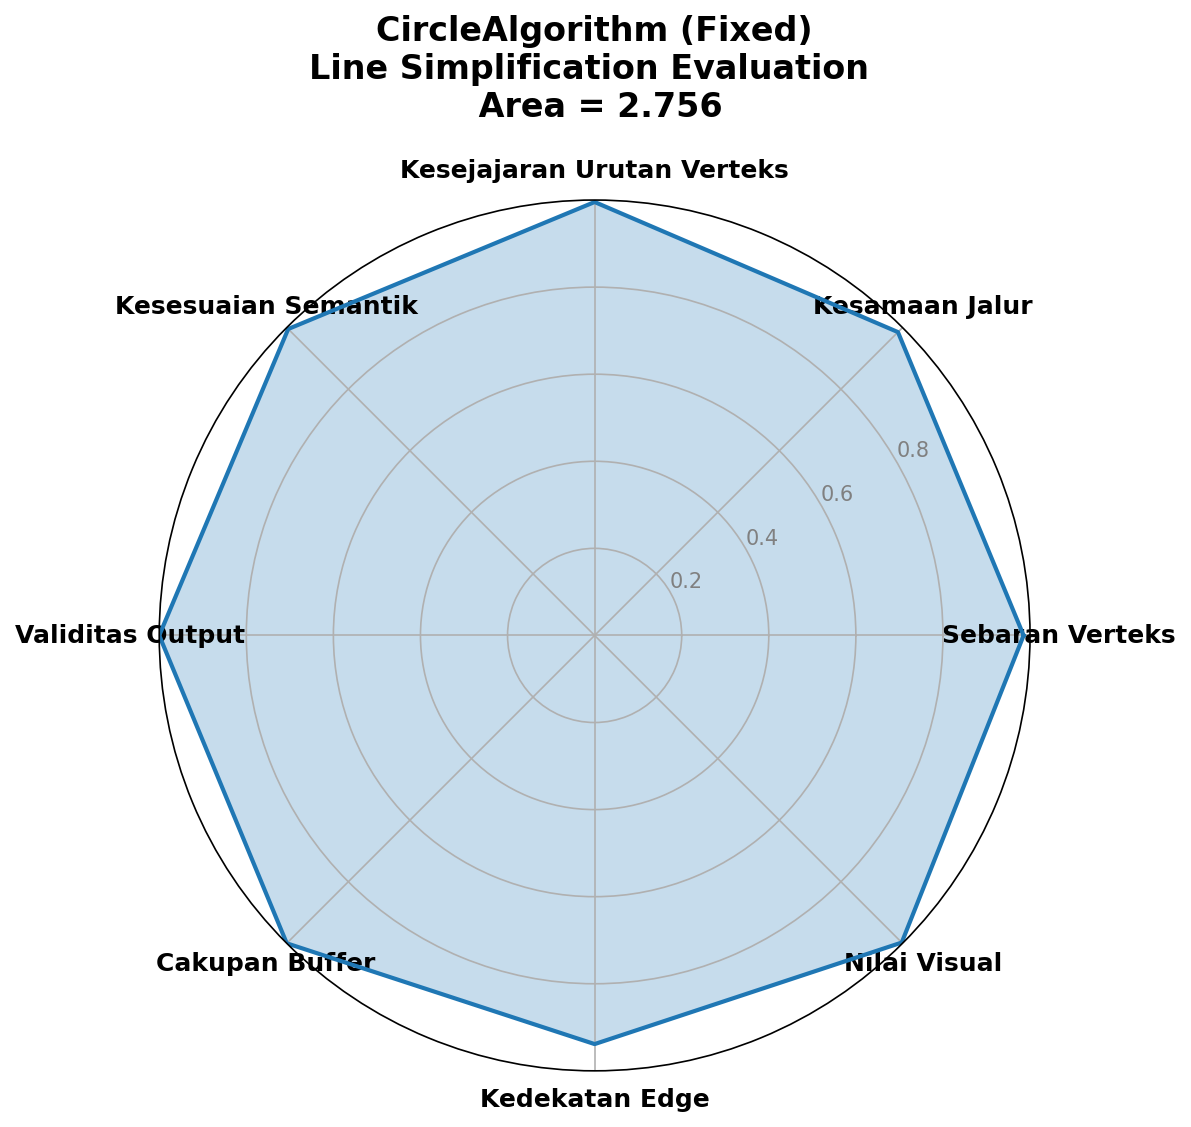

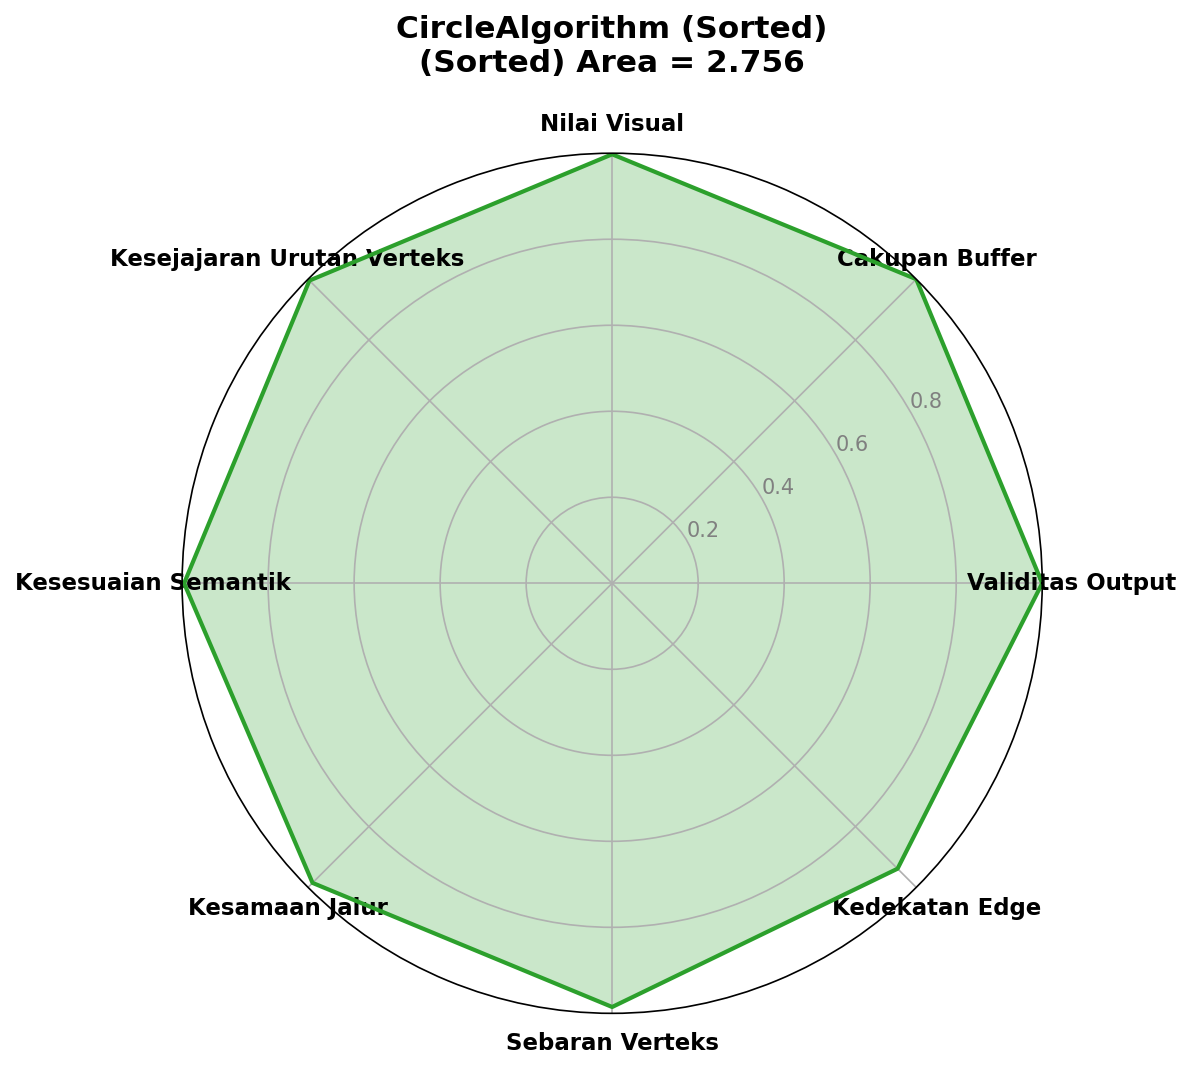

📊 CircleAlgorithm sorted area: 2.7563

🔹 AngleAlgorithm - Normalized Scores:
   hausdorff: 0.654
   frechet: 0.654
   dtw: 0.856
   semantic: 0.934
   topology: 1.000
   segment_hausdorff: 0.813
   circular_coverage: 1.000
   visual_consistency: 0.980


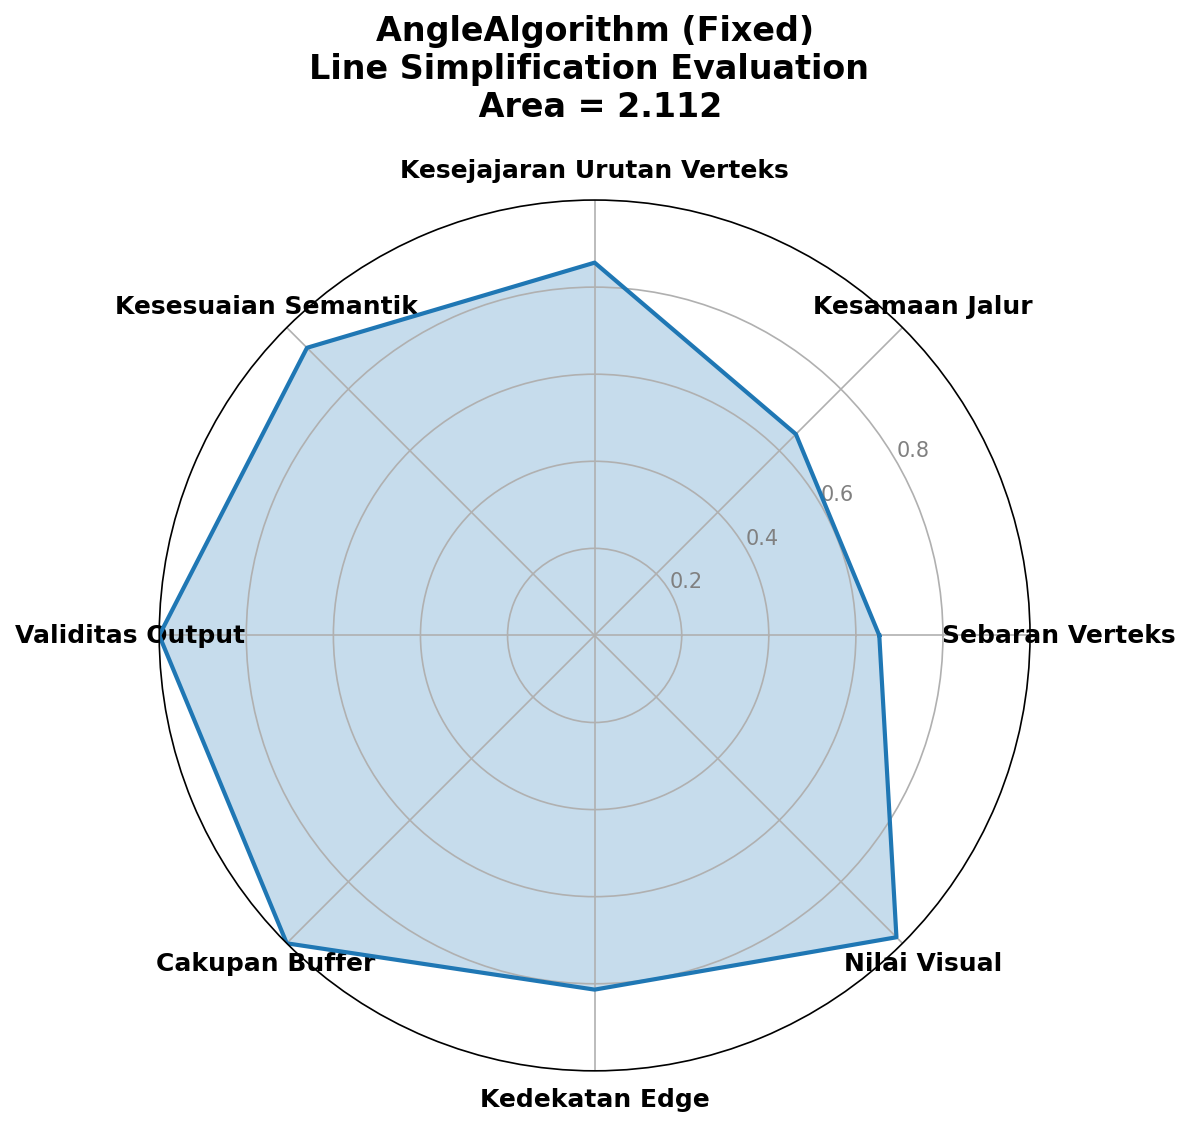

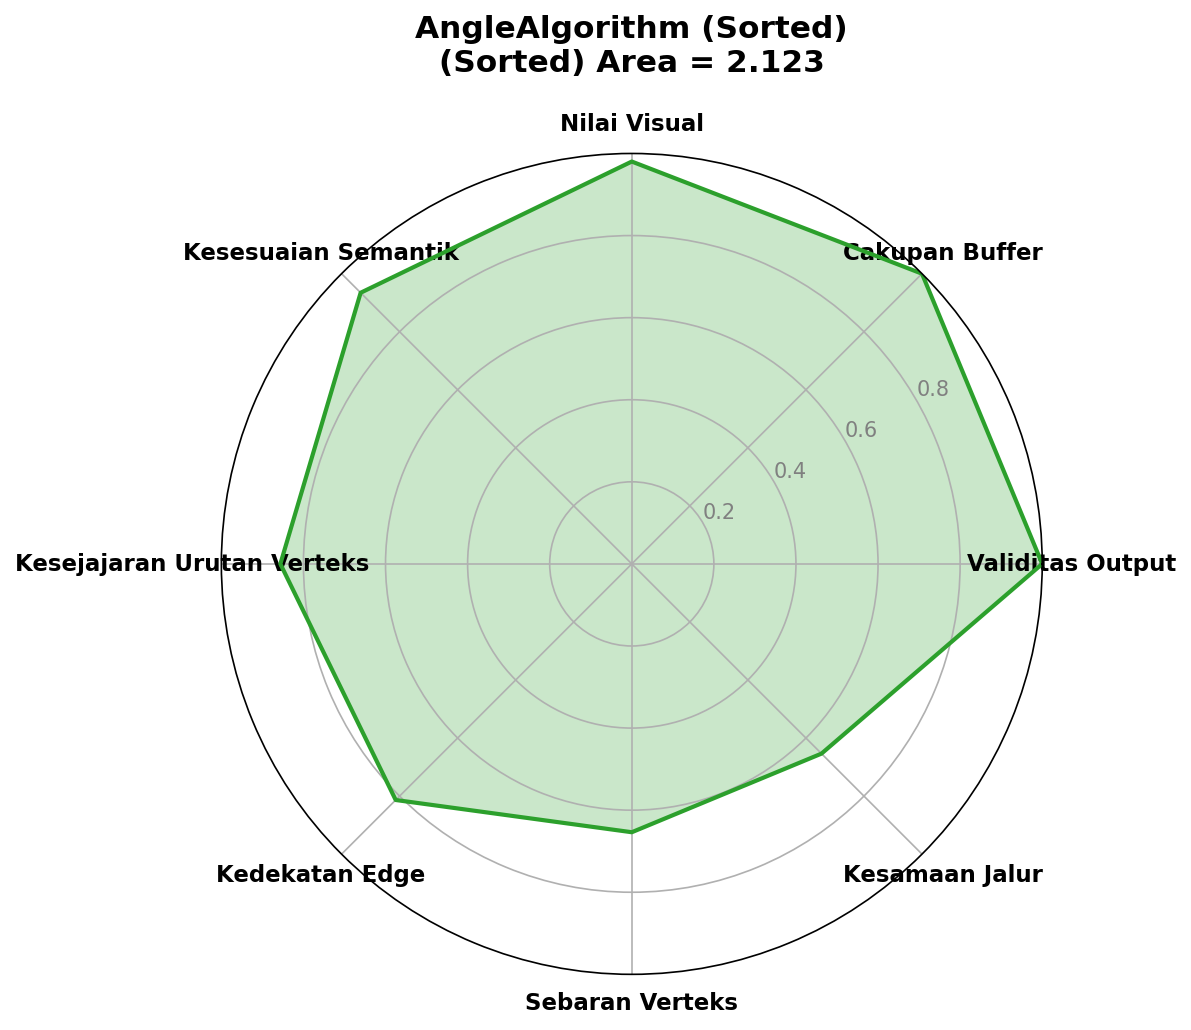

📊 AngleAlgorithm sorted area: 2.1233

🔹 ReumannWitkam - Normalized Scores:
   hausdorff: 0.964
   frechet: 0.964
   dtw: 0.974
   semantic: 0.965
   topology: 1.000
   segment_hausdorff: 0.871
   circular_coverage: 1.000
   visual_consistency: 0.990


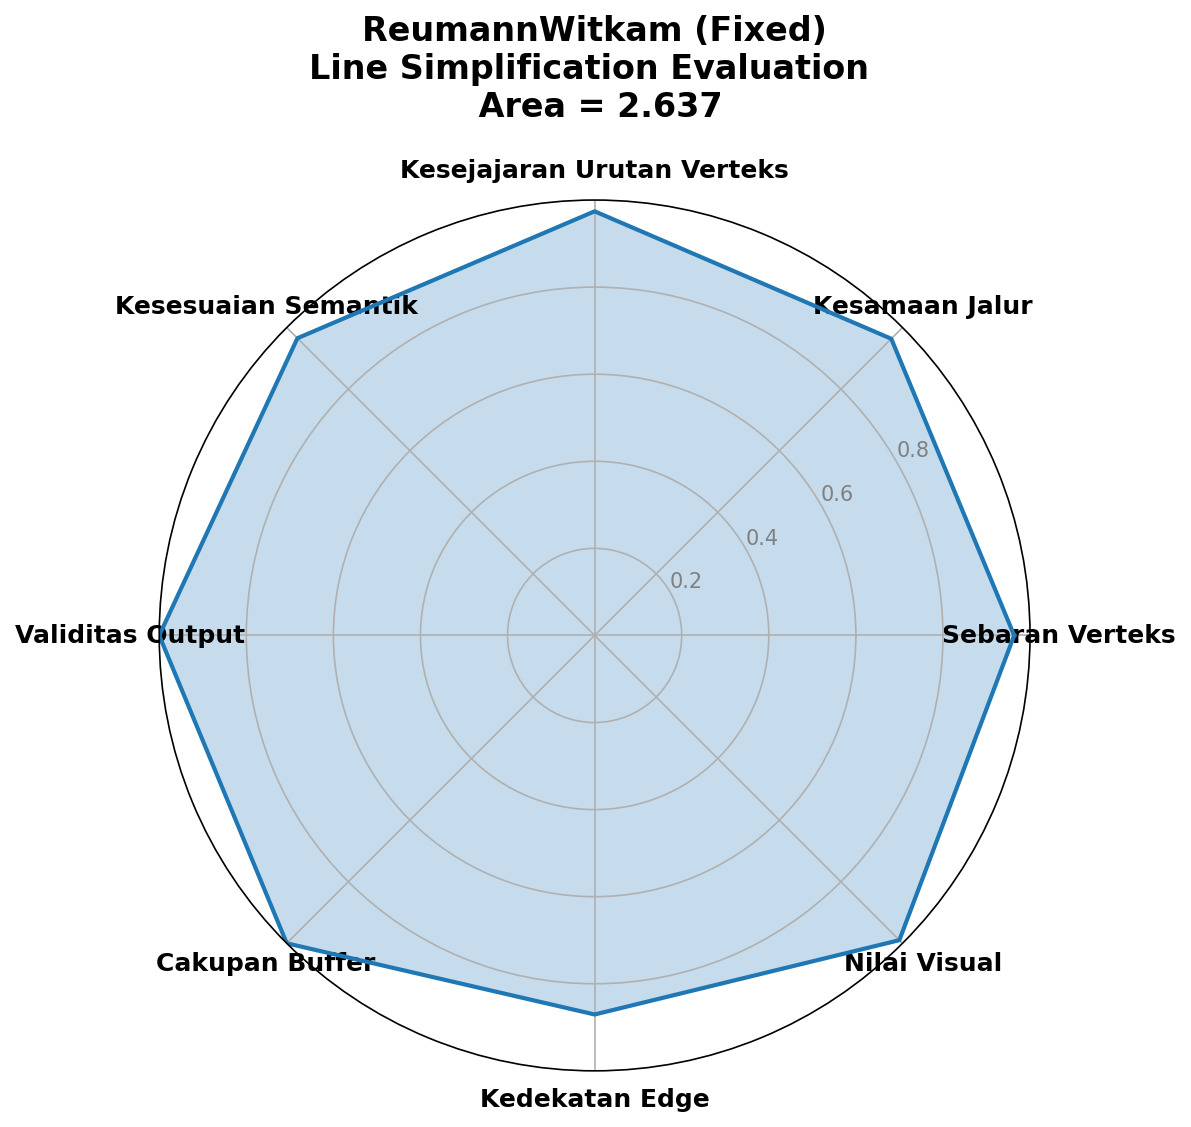

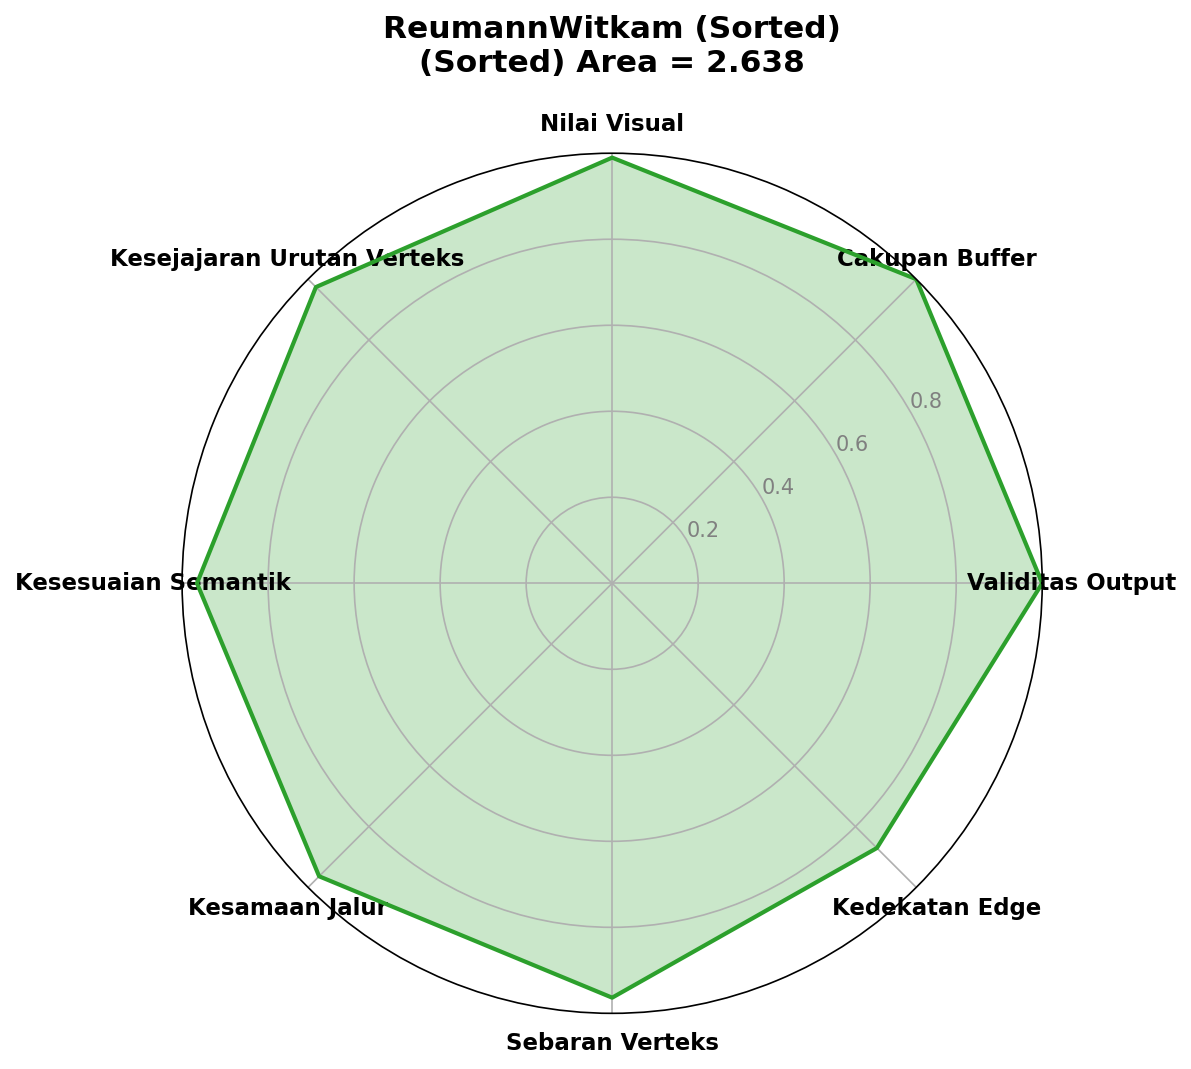

📊 ReumannWitkam sorted area: 2.6384

🔹 LangSimplification - Normalized Scores:
   hausdorff: 0.769
   frechet: 0.769
   dtw: 0.801
   semantic: 0.377
   topology: 1.000
   segment_hausdorff: 0.695
   circular_coverage: 1.000
   visual_consistency: 0.917


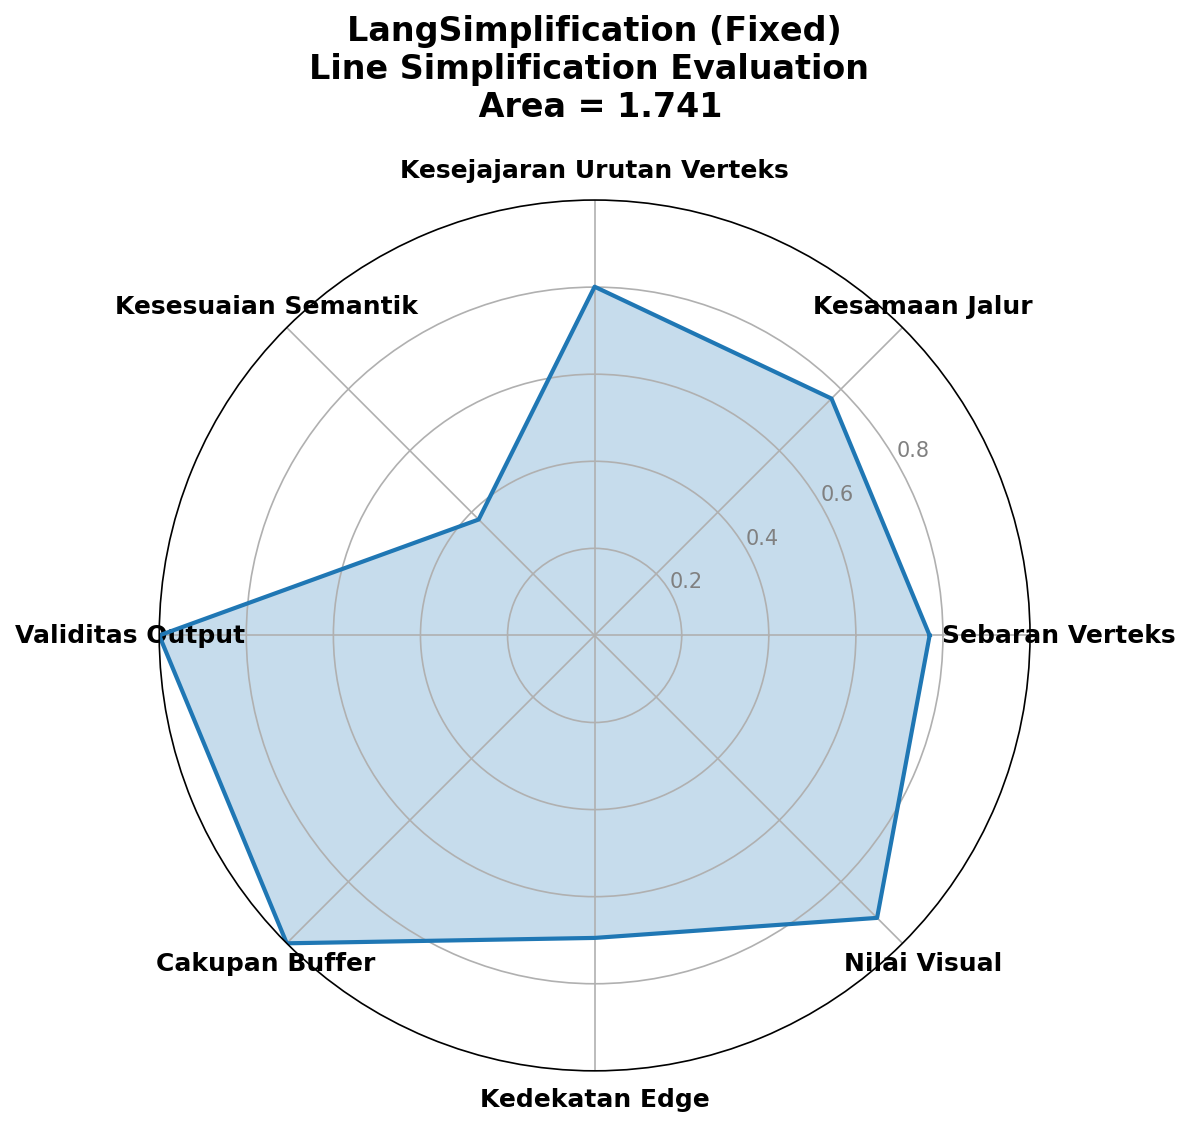

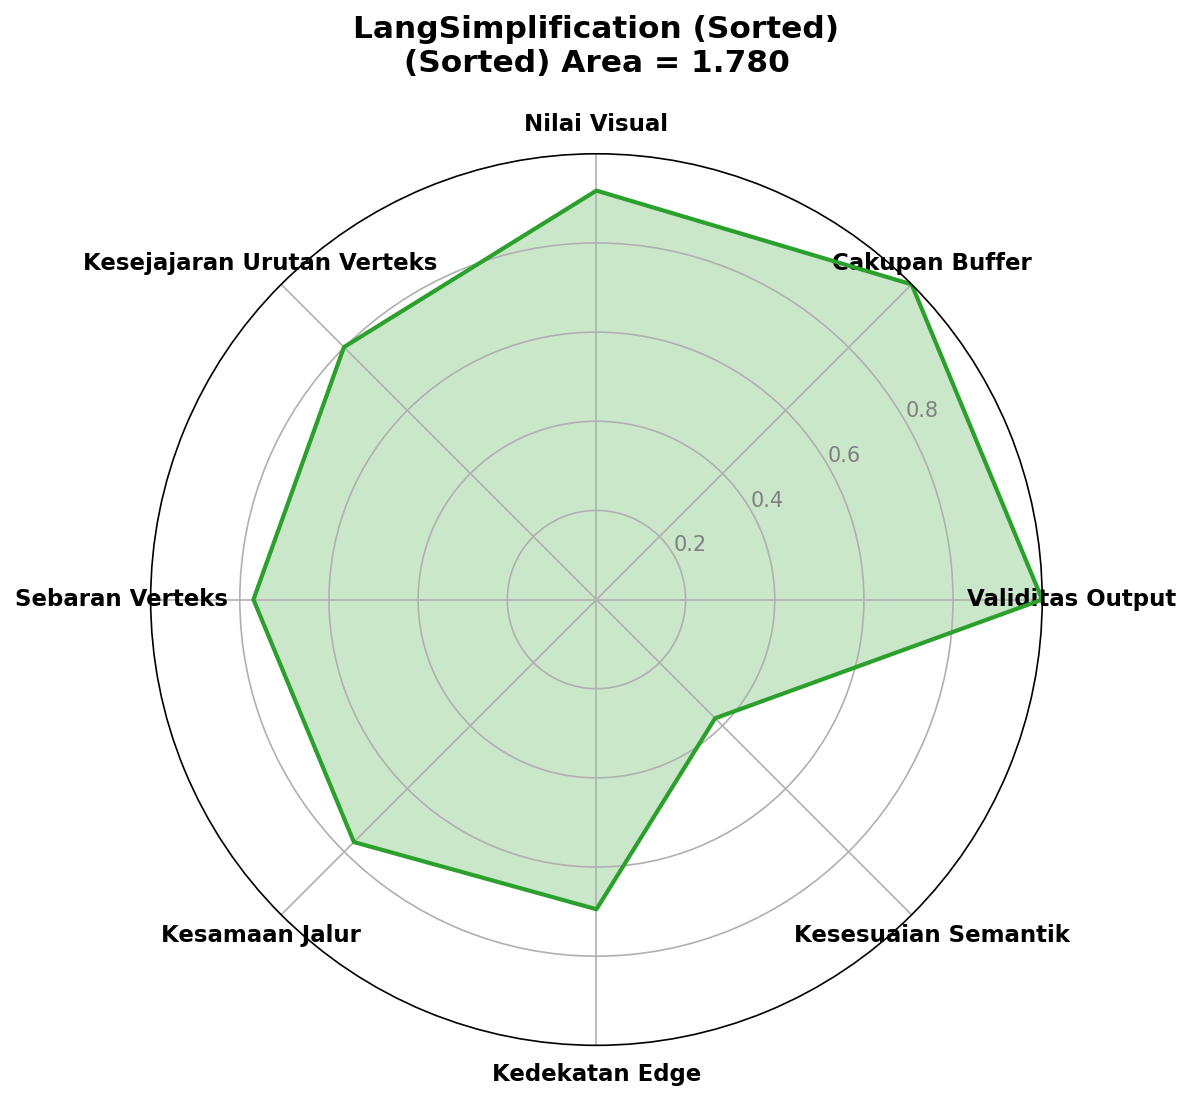

📊 LangSimplification sorted area: 1.7795

🔹 SleeveFitting - Normalized Scores:
   hausdorff: 0.506
   frechet: 0.506
   dtw: 0.638
   semantic: 0.656
   topology: 1.000
   segment_hausdorff: 0.498
   circular_coverage: 1.000
   visual_consistency: 0.857


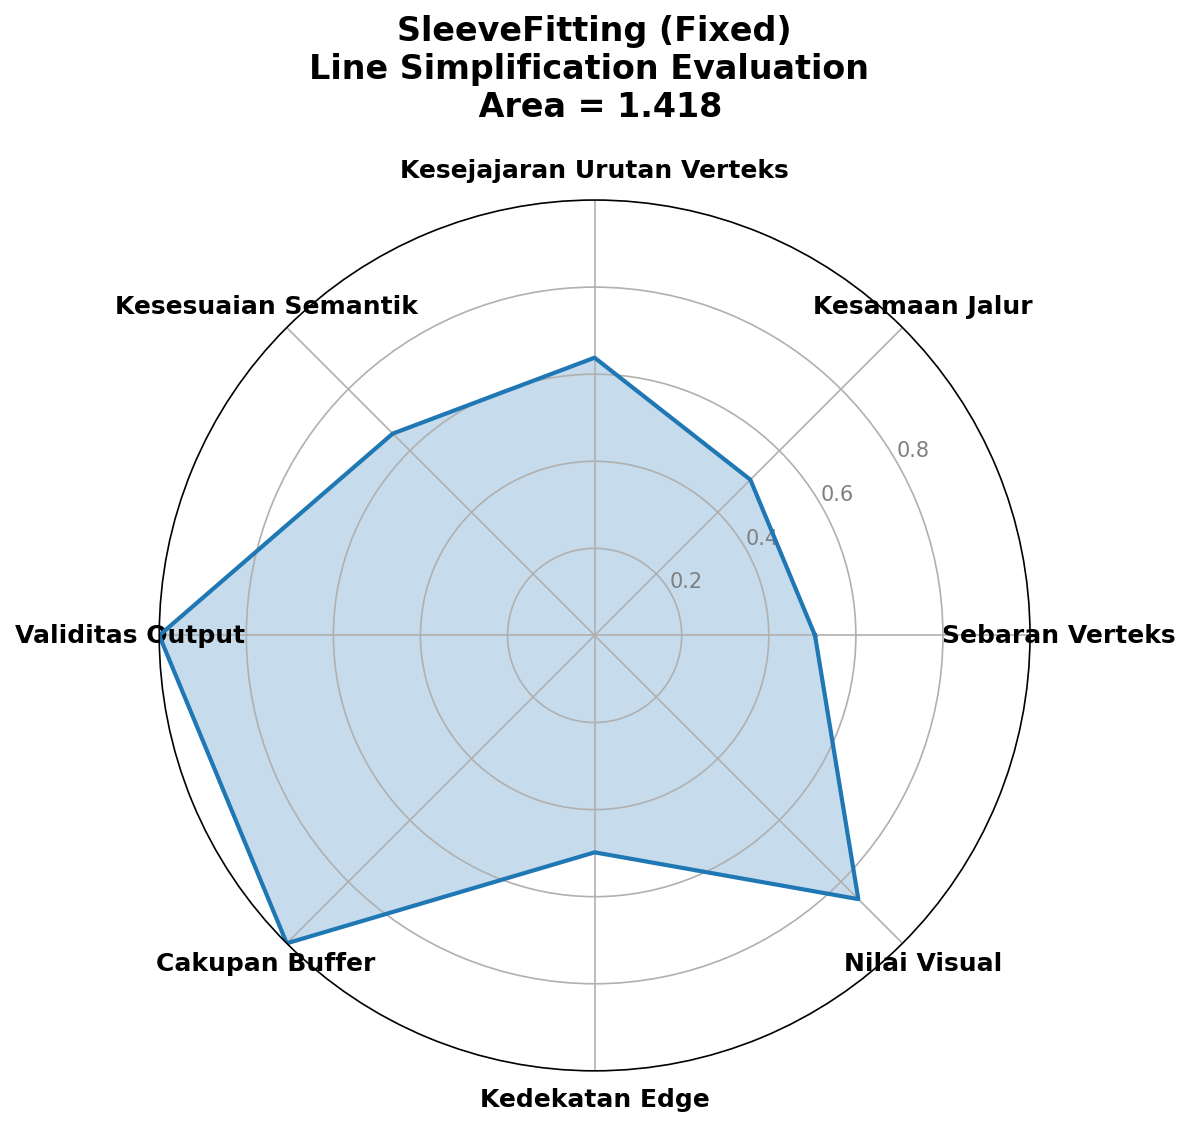

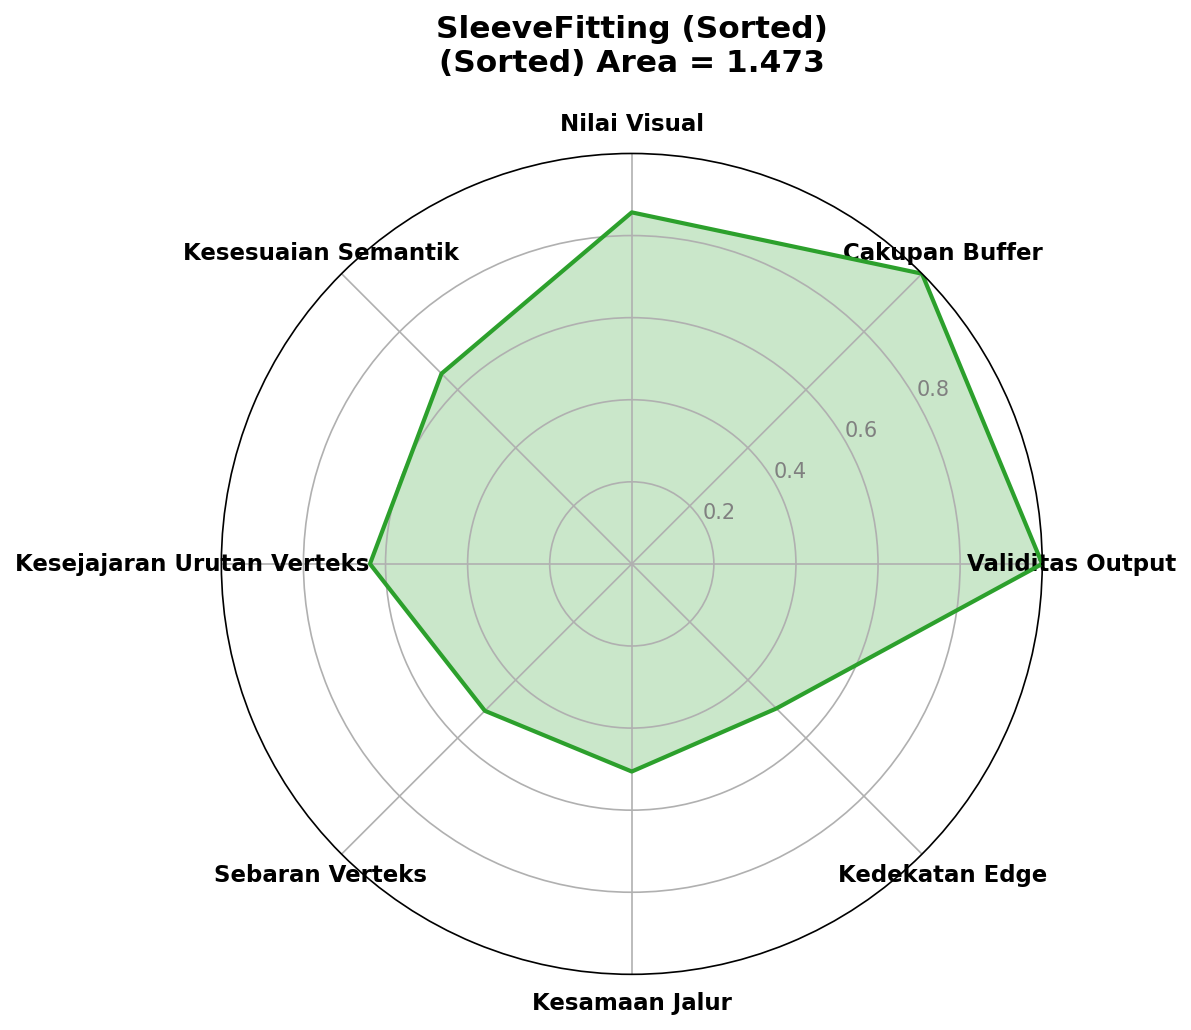

📊 SleeveFitting sorted area: 1.4727

🔹 LiOpenshaw - Normalized Scores:
   hausdorff: 0.932
   frechet: 0.932
   dtw: 0.919
   semantic: 0.000
   topology: 1.000
   segment_hausdorff: 0.333
   circular_coverage: 1.000
   visual_consistency: 0.954


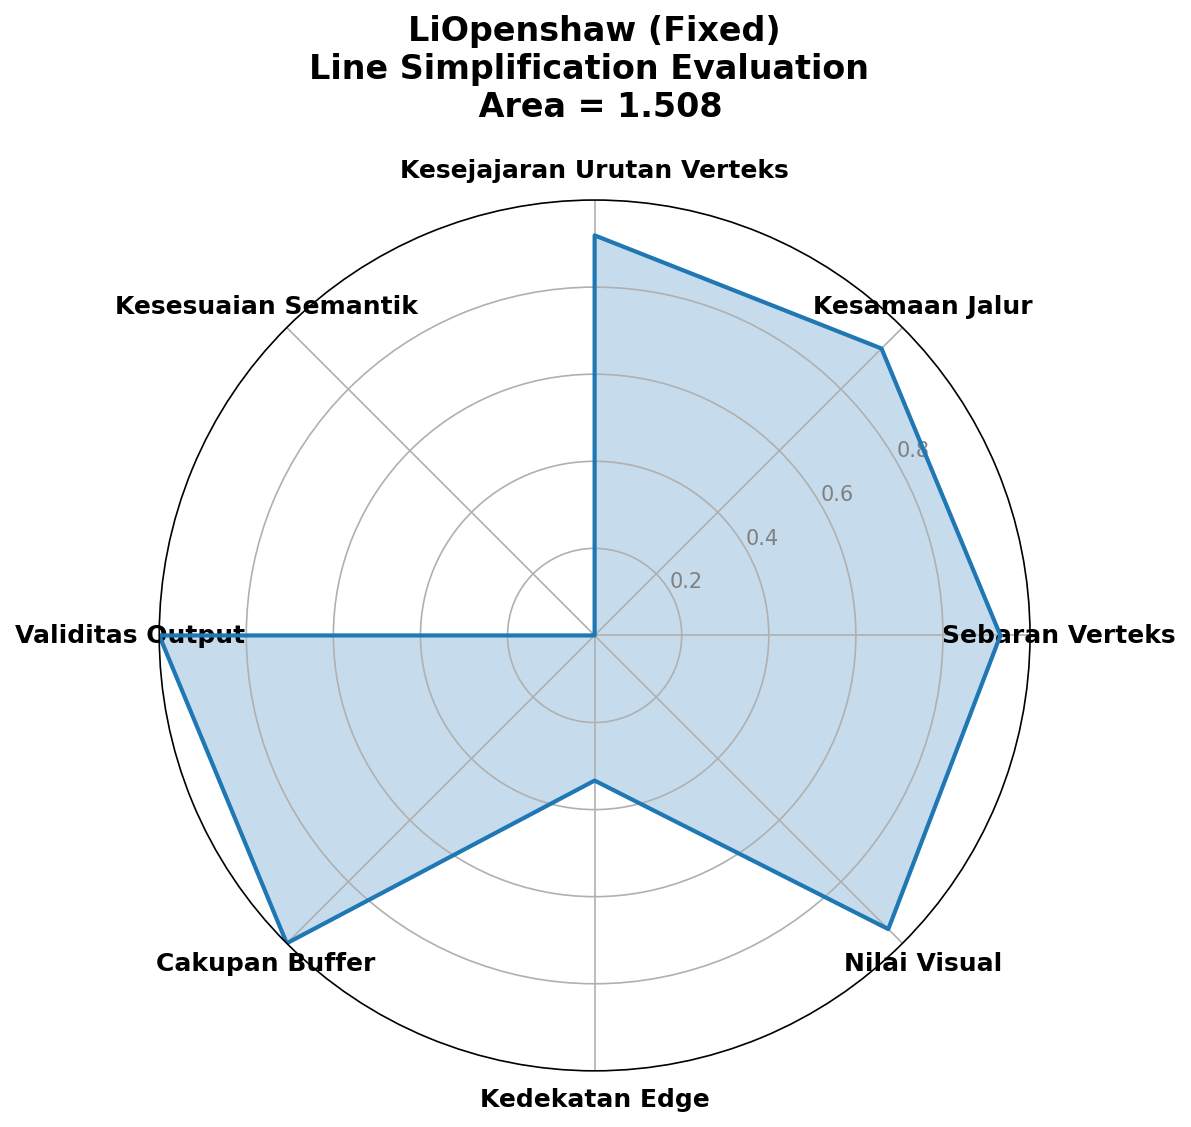

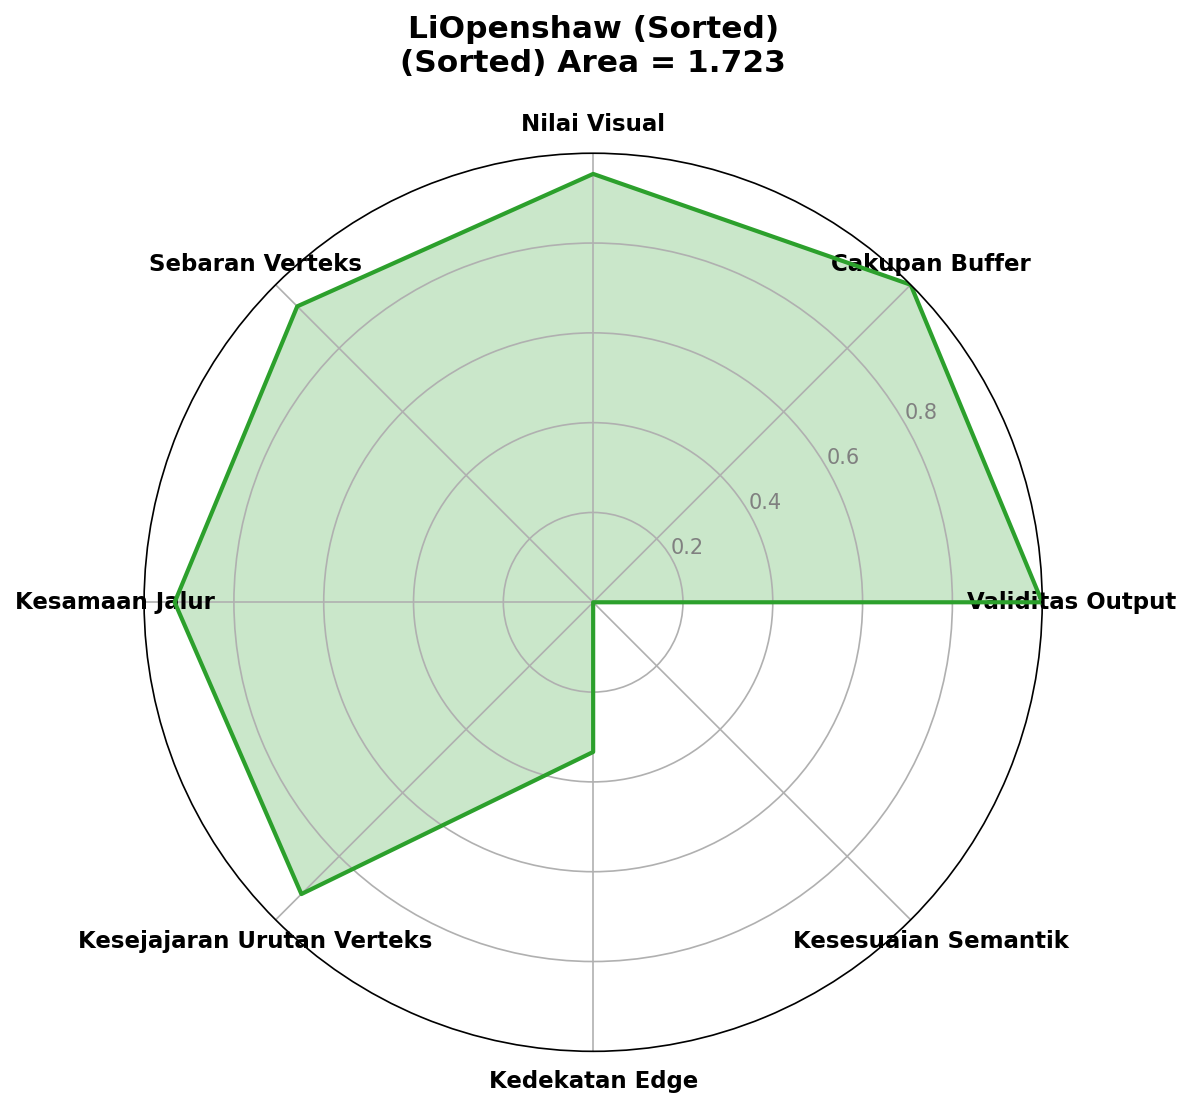

📊 LiOpenshaw sorted area: 1.7232

Ranking by Sorted Radar Area:
1. ProgressiveAlgorithm: area = 2.8284
2. VisvalingamWhyatt: area = 2.8255
3. CircleAlgorithm: area = 2.7563
4. ReumannWitkam: area = 2.6384
5. AngleAlgorithm: area = 2.1233
6. LangSimplification: area = 1.7795
7. LiOpenshaw: area = 1.7232
8. SleeveFitting: area = 1.4727
9. DouglasPeucker: area = 1.1645


In [57]:
def update_and_rerender(original_gdf, simplified_gdfs, algorithms, D_ground, cache_path="eval_results.pkl"):
    if not os.path.exists(cache_path):
        raise FileNotFoundError("Run the Phase 1 cache builder first.")
        
    with open(cache_path, 'rb') as f:
        data = pickle.load(f)
        
    raw_metrics = data['raw_metrics']
    
    print("Recalculating visual_consistency")
    for algo in algorithms:
        if algo in raw_metrics:
            raw_metrics[algo]['visual_consistency'] = calc_visual_consistency(original_gdf, simplified_gdfs[algo], D_ground)
            raw_metrics[algo].pop('angular_retention', None)
            
    invert_keys = ['hausdorff', 'frechet', 'dtw', 'segment_hausdorff', 'visual_consistency']
    new_global_max = {k: 1e-6 for k in invert_keys}
    for algo_metrics in raw_metrics.values():
        for k in invert_keys:
            if k in algo_metrics:
                new_global_max[k] = max(new_global_max[k], algo_metrics[k])
                
    data['raw_metrics'] = raw_metrics
    data['global_max'] = new_global_max
    with open(cache_path, 'wb') as f:
        pickle.dump(data, f)
    print("Cache updated successfully.")
    
    print("\nRendering updated 8-axis radar charts...")
    results_summary = []
    for algo in algorithms:
        if algo not in raw_metrics: continue
        
        normalized = normalize_metrics_for_radar(raw_metrics[algo], new_global_max)
        print(f"\n🔹 {algo} - Normalized Scores:")
        for k, v in normalized.items(): print(f"   {k}: {v:.3f}")
            
        display_algorithm_radar_chart(f"{algo} (Fixed)", normalized)
        sorted_area = display_sorted_radar_chart(f"{algo} (Sorted)", normalized)
        results_summary.append({'algorithm': algo, 'sorted_area': sorted_area})
        print(f"📊 {algo} sorted area: {sorted_area:.4f}")
        print("="*80)
        
    print("\nRanking by Sorted Radar Area:")
    for i, res in enumerate(sorted(results_summary, key=lambda x: x['sorted_area'], reverse=True), 1):
        print(f"{i}. {res['algorithm']}: area = {res['sorted_area']:.4f}")

update_and_rerender(original_gdf, simplified_gdfs, algorithms, calc_D_ground(scale=50000, h_res=1920, v_res=1080, screen_diag_inches=15.6))